#===== Plotting and Analysis =================================================================

'''
Training Figures:
-----------------

1) Plot Success, Miss, Fail rates across days for each mouse.
    - Each mouse should be on same plot, with different colors.
    - Plot Success, Miss, Fail on separate subplots
    - On each subplot, plot each profile 
        - all_trials
        - last_40
        - last_25

2) Plot Time-To-Poke 
    - Three subplots: one for each of the three profiles (all_trials, last_40, last_25)
    - Both mice on same plot, with different colors.
        - Scatter plot, use single-colour colour map using alpha to indicate how early/late the trial is in the session 
        (e.g. early trials = more transparent, later trials = more opaque).
        - Add mean point and error bars (e.g. SEM) for each day, for each mouse.
        - Add linear regression line across days for each mouse. Include equation and R^2 value on the plot in legend/text box.
    - Repeat for only trials that are "Success" (i.e. exclude Miss and Fail trials).
    - Repeat for only trials that are either "Success" or "Failure" (i.e. exclude Miss trials).

3) Plot Angle Offset for each mouse, across days, for each profile (all_trials, last_40, last_25).
    - Scatterplot, y-axis  is set to +/- 180 degrees, with 0 at the center.
    - Both mice on same plot, with different colours. Colour map using alpha to indicate how early/late the trial is in the session (e.g. early trials = more transparent, later trials = more opaque).
    - Add mean point and error bars (e.g. SEM) for each day, for each mouse.
    - Add linear regression line across days for each mouse. Include equation and R^2 value on the plot in legend/text box.
    - Exclude trials where angle offset is NaN. Provide summary text below plot indicating the number of trials included for each mouse, for each day.

4) Summary Statistics:
    - For each profile (all_trials, last_40, last_25), for each day, for each mouse, calculate and display "table of key statistics" including:
        - Total number of trials
        - Total number of success, miss, fail trials
        - Max, min, mean, median, SEM of time-to-poke for all trials, for success trials only, and for success+fail trials.
        - Max, min, mean, median, SEM of angle offset for all trials, for success trials only, and for success+fail trials.
        - For each day, for each mouse, for each profile, calculate the correlation between time-to-poke and angle offset, 
            and display the correlation coefficient and p-value in the summary statistics table.
        - For each day, for each mouse, for each profile, calculate the correlation between trial number and time-to-poke, 
            and display the correlation coefficient and p-value in the summary statistics table.
        - For each day, for each mouse, for each profile, calculate the correlation between trial number and angle offset, 
            and display the correlation coefficient and p-value in the summary statistics table.
        - For each day, for each mouse, for each profile, calculate the correlation between time-to-poke and trial outcome (e.g. success=1, fail=0), 
            and display the correlation coefficient and p-value in the summary statistics table.
        - For each day, for each mouse, using the all_trials profile only, calculate the correlation between target_zone_size and likelihood of success, and display the correlation coefficient and p-value in the summary statistics table.


Testing Figures:
----------------

Same as above, but with the following differences:
- For the test_sessions_last dataset, we will apply the same three profiles as for the training sessions (all_trials, last_40, last_25).
- For the test_sessions_first dataset, we will show the first_40 and first_25 profiles against the same days as the last_40 and last_25 
    profiles from the test_sessions_last dataset, to allow comparison of the first vs last trials on each day of testing.



'''

## Global Settings
----------------------------

In [1]:
#==== Imports and Setup =============================================================================
from pathlib import Path
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

#==== Define Paths
PROJECT_DIR = Path("/home/callum/Keshavarzi-Lab-Workspace/data-conduit")
PROCESSED_DIR = PROJECT_DIR / "Q_C_Analysis_Workflow/new/processed_data"
FIGURE_DIR = PROJECT_DIR / "Q_C_Analysis_Workflow/new/figures"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)


#==== Load Processed Data 
training_all_trials = pd.read_csv(PROCESSED_DIR / "training_all_trials_trials.csv")
training_last_40 = pd.read_csv(PROCESSED_DIR / "training_last_40_trials.csv")
training_last_25 = pd.read_csv(PROCESSED_DIR / "training_last_25_trials.csv")

testing_last_all_trials = pd.read_csv(PROCESSED_DIR / "testing_last_all_trials_trials.csv")
testing_last_40 = pd.read_csv(PROCESSED_DIR / "testing_last_last_40_trials.csv")
testing_last_25 = pd.read_csv(PROCESSED_DIR / "testing_last_last_25_trials.csv")

testing_first_40 = pd.read_csv(PROCESSED_DIR / "testing_first_first_40_trials.csv")
testing_first_25 = pd.read_csv(PROCESSED_DIR / "testing_first_first_25_trials.csv")

#===== Create dictionaries to hold the different DataFrames for easy access in analysis and plotting.
training_dfs = {"all_trials": training_all_trials,"last_40": training_last_40,"last_25": training_last_25,
                }
testing_last_dfs = {"all_trials": testing_last_all_trials,"last_40": testing_last_40,"last_25": testing_last_25,
}
testing_first_dfs = {"first_40": testing_first_40,"first_25": testing_first_25,
}

display(training_dfs["last_40"][training_dfs["last_40"]["mouseID"] == "FbR_M01569522"])

,trial_index,start_time,end_time,TTP,ChosenPort,CorrectPort,outcome,LED,angle_offset,target_zone_size,mouseID,training/testing,day,session,dataset,session_dict,filter_profile
0,30,22919.628416,22958.617984,2.352992,7,7,Success,OFF,0.0,150.0,FbR_M01569522,training,Day_1,2026-04-21T155201Z,training,training_sessions,last_40
1,31,22959.617984,22986.968992,2.904000,7,7,Success,OFF,0.0,150.0,FbR_M01569522,training,Day_1,2026-04-21T155201Z,training,training_sessions,last_40
2,32,22987.968992,23004.761984,2.447008,7,7,Success,OFF,0.0,150.0,FbR_M01569522,training,Day_1,2026-04-21T155201Z,training,training_sessions,last_40
3,33,23005.761984,23015.370976,2.152992,7,7,Success,OFF,0.0,150.0,FbR_M01569522,training,Day_1,2026-04-21T155201Z,training,training_sessions,last_40
4,34,23016.370976,23026.086496,1.670496,8,7,Failure,OFF,20.0,150.0,FbR_M01569522,training,Day_1,2026-04-21T155201Z,training,training_sessions,last_40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,41,21198.665984,21218.600992,5.020000,-1,12,Miss,OFF,NaN,150.0,FbR_M01569522,training,Day_5,2026-04-29T155431Z,training,training_sessions,last_40
196,42,21219.600992,21233.157504,3.378528,12,12,Success,OFF,0.0,150.0,FbR_M01569522,training,Day_5,2026-04-29T155431Z,training,training_sessions,last_40
197,43,21234.157504,21252.621984,3.588992,12,12,Success,OFF,0.0,150.0,FbR_M01569522,training,Day_5,2026-04-29T155431Z,training,training_sessions,last_40
198,44,21253.621984,21261.516000,2.037024,12,12,Success,OFF,0.0,150.0,FbR_M01569522,training,Day_5,2026-04-29T155431Z,training,training_sessions,last_40


In [2]:
#==== Figure Styling and Formatting =================================================================

#==== General Styling
# Gridlines Toggle
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Background and Spines
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['axes.edgecolor'] = 'black'

# Linewidths
plt.rcParams['axes.linewidth'] = 1.0
plt.rcParams['lines.linewidth'] = 2.0
plt.rcParams['xtick.major.width'] = 1.0
plt.rcParams['ytick.major.width'] = 1.0



# Legend Styling

plt.rcParams['legend.frameon'] = True
# plt.rcParams['legend.framealpha'] = 0.8
# plt.rcParams['legend.edgecolor'] = 'black'
# plt.rcParams['legend.facecolor'] = 'white'
plt.rcParams['legend.fancybox'] = True





#==== Text Sizing 
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.titlesize'] = 14

# plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.weight'] = 'normal'

#==== Colours
mouse_1_cmap = plt.get_cmap("Greens")
mouse_2_cmap = plt.get_cmap("Purples")

mouse_1_ID = 'FLR_M01569521'
mouse_2_ID = 'FbR_M01569522'

mouse_IDs = [mouse_1_ID, mouse_2_ID]
mouse_colours = {mouse_1_ID: mouse_1_cmap(0.6), mouse_2_ID: mouse_2_cmap(0.6)}
mouse_cmaps = {mouse_1_ID: mouse_1_cmap, mouse_2_ID: mouse_2_cmap}

#==== Saving and Display Configurations
SAVE_FIGURES = True
SAVE_PATH = FIGURE_DIR
APPEND_DATE = True
DISPLAY_FIGURES = True
FIG_FORMAT = 'svg'
DPI = 300



## Figure Functions
----------------------------

### Figure 1 Function: Plot the *Success | Fail | Miss* rates across days for the dataset
----------------------------

In [3]:
def plot_sfm_figure(dataset_df: pd.DataFrame = None,
                    plot_outcome: str = "Success",          # "Success", "Miss", "Failure"
                    save_path: Optional[Path] = FIGURE_DIR,
                    mouse_IDs: Optional[tuple] = mouse_IDs,
                    mouse_colours: Optional[dict] = mouse_colours,
                    days_to_plot: Optional[list] = None,     # If None, every day present in dataset_df is plotted
                    title: Optional[str] = None,
                    save_figures: Optional[bool] = SAVE_FIGURES,
                    append_date: Optional[bool] = APPEND_DATE,
                    display_figure: Optional[bool] = DISPLAY_FIGURES,
                    fig_format: Optional[str] = FIG_FORMAT,
                    dpi: Optional[int] = DPI,
                    figsize: Optional[tuple] = (8, 6),
                    point_size: float = 45,
                    display_summary_statistics: bool = True,    # print mini per-(mouse, day) stats table
                    ax: Optional[plt.Axes] = None,               # optional subplot axis to draw into
):
    """
    Plot the rate of a single outcome (Success | Miss | Failure) across days,
    one point per (mouse, day), with a per-mouse linear regression line.

    Parameters
    ----------
    dataset_df : pd.DataFrame
        Trial-level dataframe. Must contain columns:
            'mouseID', 'day', 'outcome', 'training/testing', 'filter_profile'.
    plot_outcome : str
        Which outcome to plot the rate of. One of "Success", "Miss", "Failure".
    save_path : Path, optional
        Directory to save the figure into. Defaults to FIGURE_DIR.
    mouse_IDs : tuple of str, optional
        Mouse IDs to include. Defaults to the global `mouse_IDs`.
    mouse_colours : dict, optional
        Mapping mouse_ID -> matplotlib colour. Defaults to the global `mouse_colours`.
    days_to_plot : list of int, optional
        Day numbers to keep. If None, plots every day present in dataset_df.
    title : str, optional
        Plot title. If None, uses "{dataset_name} - {plot_outcome} Rate Across Days".
    save_figures, append_date, display_figure, fig_format, dpi : ...
        Standard save/display knobs, defaulting to the notebook-level globals.
    figsize : tuple
        Figure size in inches.
    point_size : float
        Scatter marker size.
    ax : matplotlib.axes.Axes, optional
        Existing subplot axis to draw into. If None, this function creates
        its own standalone figure. Passing an axis lets a wrapper call this
        function repeatedly to build multi-panel figures.

    Returns
    -------
    (fig, ax) : the matplotlib Figure and Axes, so the caller can tweak further.
    """

    #==== 1. Derive the dataset name from the dataframe ============================
    # The dataframe itself tells us which dataset it is: 'training/testing' gives
    # "training" or "testing", and 'filter_profile' gives "last_40", "last_25", etc.
    # We combine them to get e.g. "Training_last_40" -- used in both the title and
    # the saved filename.
    train_test = dataset_df["training/testing"].iloc[0]
    profile = dataset_df["filter_profile"].iloc[0]
    dataset_name = f"{train_test.capitalize()}_{profile}"

    #==== 2. Filter to the requested mice and extract a numeric day column =========
    # The 'day' column holds strings like "Day_1", "Day_2", ... We pull the digits
    # out with a regex so we can plot day on a numeric x-axis. If the caller
    # supplied days_to_plot, we then drop everything outside that list.
    df = dataset_df[dataset_df["mouseID"].isin(mouse_IDs)].copy()
    df["day_num"] = df["day"].astype(str).str.extract(r"(\d+)").astype(int)

    if days_to_plot is not None:
        df = df[df["day_num"].isin(days_to_plot)]

    #==== 3. Compute the outcome rate per (mouse, day) =============================
    # For every (mouse, day) group, the rate is just the fraction of trials whose
    # outcome equals plot_outcome. groupby().mean() on a boolean column does this
    # in one step. Result: a tidy frame with columns mouseID, day_num, rate.
    df["is_target_outcome"] = df["outcome"] == plot_outcome
    rates = (
        df.groupby(["mouseID", "day_num"])["is_target_outcome"]
          .mean()
          .reset_index(name="rate")
    )

    #==== 4. Plot scatter + linear regression, one mouse at a time =================
    # For each mouse: plot its (day, rate) points, and (if it has at least two
    # days of data) fit a linear regression and draw it across the day range.
    # The regression equation and R^2 go straight into the legend label.
    #
    # If ax is provided, this function draws into that existing subplot.
    # If ax is None, it creates its own standalone figure as before.
    created_own_figure = ax is None
    if created_own_figure:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure

    for mouse in mouse_IDs:
        mouse_rates = rates[rates["mouseID"] == mouse]
        x = mouse_rates["day_num"].values
        y = mouse_rates["rate"].values
        colour = mouse_colours[mouse]

        if len(x) >= 2:
            fit = stats.linregress(x, y)
            label = (
                f"{mouse}: y = {fit.slope:.2f}x + {fit.intercept:.2f}"
                f"   (R² = {fit.rvalue ** 2:.2f})"
            )
            x_line = np.array([x.min(), x.max()])
            ax.plot(x_line, fit.slope * x_line + fit.intercept,
                    color=colour, linewidth=2)
        else:
            label = mouse

        ax.scatter(x, y, color=colour, s=point_size, label=label,
                   edgecolor="black", zorder=3)

    #==== 5. Style, save, and show =================================================
    # Y-axis is locked to [0, 1] because the values are proportions. X-ticks are
    # placed at exactly the integer days that appear in the data. Title defaults
    # to "{dataset_name} - {plot_outcome} Rate Across Days" unless overridden.
    ax.set_ylim(0, 1)
    ax.set_xticks(sorted(rates["day_num"].unique()))
    ax.set_xlabel("Day")
    ax.set_ylabel(f"{plot_outcome} Rate")
    ax.set_title(title or f"{dataset_name} - {plot_outcome} Rate Across Days")
    ax.legend(loc="best")
    if created_own_figure:
        fig.tight_layout()

    # Optional inline summary table: counts of each outcome per (mouse, day),
    # alongside the rate that is plotted.
    if display_summary_statistics:
        counts = (
            df.groupby(["mouseID", "day_num"])
              .agg(n_trials=("outcome", "size"),
                   n_success=("outcome", lambda s: (s == "Success").sum()),
                   n_fail=("outcome", lambda s: (s == "Failure").sum()),
                   n_miss=("outcome", lambda s: (s == "Miss").sum()))
              .reset_index()
        )
        summary = (
            counts.merge(rates, on=["mouseID", "day_num"])
                  .rename(columns={"rate": f"{plot_outcome.lower()}_rate"})
                  .set_index(["day_num", "mouseID"])
                  .sort_index()
        )
        print(f"=== Summary statistics: {dataset_name} (outcome={plot_outcome!r}) ===")
        display(summary.round(3))

    # Filename pattern: "{dataset_name}_{outcome}_rate_plot[_YYYY-MM-DD].{fmt}"
    # e.g. "Training_last_40_success_rate_plot_2026-05-12.svg"
    # Only save from this function when it created its own standalone figure.
    # Multi-panel wrapper functions should handle saving the combined figure.
    if created_own_figure and save_figures and save_path is not None:
        stem = f"{dataset_name}_{plot_outcome.lower()}_rate_plot"
        if append_date:
            stem += f"_{pd.Timestamp.today().strftime('%Y-%m-%d')}"
        fig.savefig(Path(save_path) / f"{stem}.{fig_format}",
                    dpi=dpi, format=fig_format, bbox_inches="tight")

    # Only show/close here for standalone calls. If an external axis was
    # provided, the caller owns the full figure lifecycle.
    if created_own_figure:
        if display_figure:
            plt.show()
        else:
            plt.close(fig)

    return fig, ax


def plot_sfm_subplots(dataset_df: pd.DataFrame = None,
                      save_path: Optional[Path] = FIGURE_DIR,
                      mouse_IDs: Optional[tuple] = mouse_IDs,
                      mouse_colours: Optional[dict] = mouse_colours,
                      days_to_plot: Optional[list] = None,
                      title: Optional[str] = None,
                      save_figures: Optional[bool] = SAVE_FIGURES,
                      append_date: Optional[bool] = APPEND_DATE,
                      display_figure: Optional[bool] = DISPLAY_FIGURES,
                      fig_format: Optional[str] = FIG_FORMAT,
                      dpi: Optional[int] = DPI,
                      figsize: Optional[tuple] = (18, 6),
                      point_size: float = 45,
                      display_summary_statistics: bool = False,
):
    """
    Plot Success, Miss, and Failure rates as three subplots for one dataset.

    This is a thin constructor around `plot_sfm_figure`. It creates one
    figure with three axes, then calls `plot_sfm_figure` three times while
    changing `plot_outcome` between "Success", "Miss", and "Failure".

    Parameters mirror `plot_sfm_figure` where possible. Saving happens once,
    at the combined-figure level, so you get one SVG rather than three.

    Returns
    -------
    (fig, axes) : matplotlib Figure and the three subplot Axes.
    """

    outcomes = ("Success", "Miss", "Failure")

    # Derive a readable dataset label for the title and saved filename.
    train_test = dataset_df["training/testing"].iloc[0]
    profile = dataset_df["filter_profile"].iloc[0]
    dataset_name = f"{train_test.capitalize()}_{profile}"

    # Create the three-panel figure. Each axis is then handed to the existing
    # single-outcome function, so all rate/regression logic stays in one place.
    fig, axes = plt.subplots(1, 3, figsize=figsize, sharey=True)

    for ax, outcome in zip(axes, outcomes):
        plot_sfm_figure(
            dataset_df=dataset_df,
            plot_outcome=outcome,
            save_path=None,
            mouse_IDs=mouse_IDs,
            mouse_colours=mouse_colours,
            days_to_plot=days_to_plot,
            title=f"{outcome} Rate",
            save_figures=False,
            append_date=append_date,
            display_figure=False,
            fig_format=fig_format,
            dpi=dpi,
            figsize=figsize,
            point_size=point_size,
            display_summary_statistics=display_summary_statistics,
            ax=ax,
        )

    # The y-axis is shared, so only the left subplot needs the full label.
    axes[0].set_ylabel("Outcome Rate")
    axes[1].set_ylabel("")
    axes[2].set_ylabel("")

    fig.suptitle(title or f"{dataset_name} - Success / Miss / Failure Rates Across Days")
    fig.tight_layout()

    # Save one combined figure, not one file per outcome.
    if save_figures and save_path is not None:
        stem = f"{dataset_name}_sfm_rate_subplots"
        if append_date:
            stem += f"_{pd.Timestamp.today().strftime('%Y-%m-%d')}"
        fig.savefig(Path(save_path) / f"{stem}.{fig_format}",
                    dpi=dpi, format=fig_format, bbox_inches="tight")

    if display_figure:
        plt.show()
    else:
        plt.close(fig)

    return fig, axes




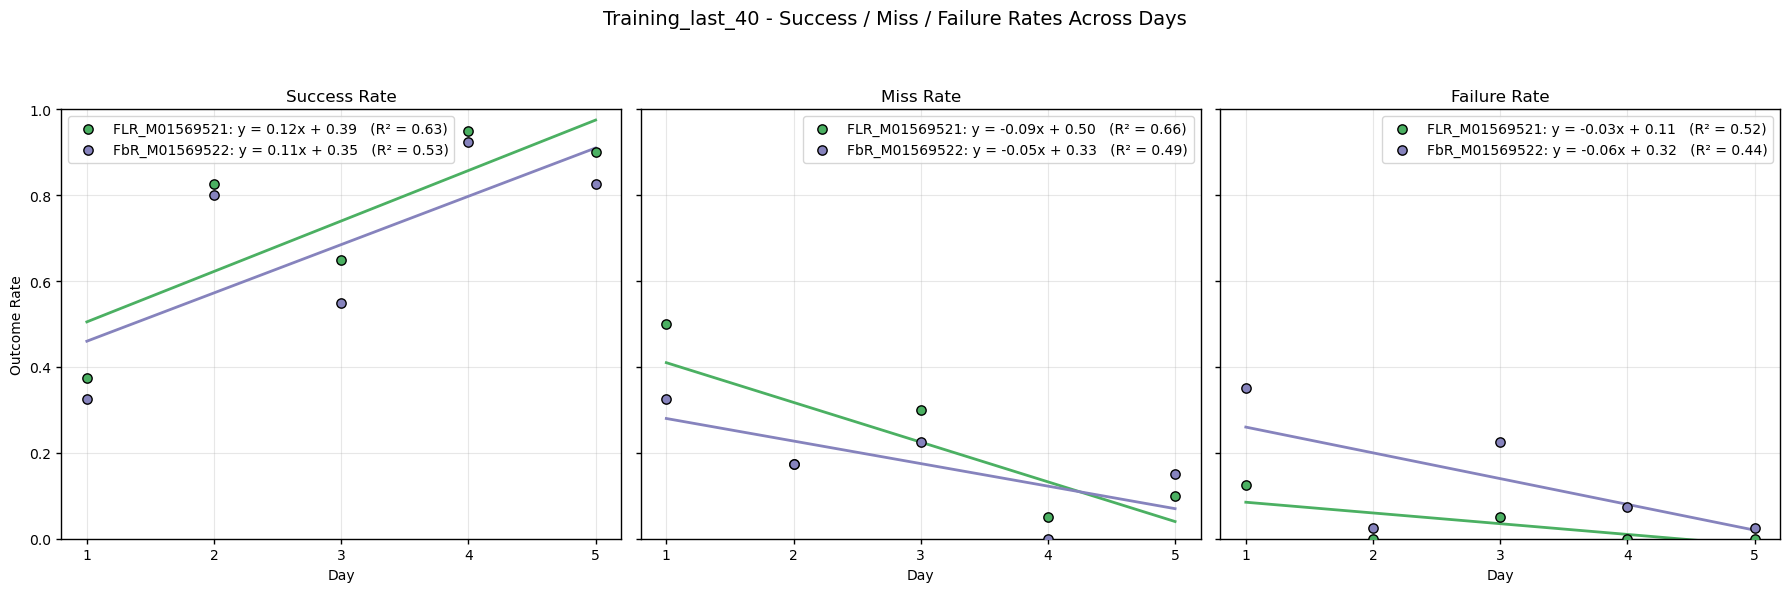

In [4]:
# Build one SFM figure by calling plot_sfm_figure once per outcome.
dset = training_dfs["last_40"]
sfm_outcomes = ("Success", "Miss", "Failure")

train_test = dset["training/testing"].iloc[0]
profile = dset["filter_profile"].iloc[0]
dataset_name = f"{train_test.capitalize()}_{profile}"

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for ax, outcome in zip(axes, sfm_outcomes):
    plot_sfm_figure(
        dataset_df=dset,
        plot_outcome=outcome,
        save_path=None,                  # do not save separate single-outcome figures
        mouse_IDs=mouse_IDs,
        mouse_colours=mouse_colours,
        days_to_plot=None,               # if None, every day present in dset is plotted
        title=f"{outcome} Rate",
        save_figures=False,              # the combined figure is saved below
        append_date=APPEND_DATE,
        display_figure=False,            # the combined figure is displayed below
        fig_format=FIG_FORMAT,
        dpi=DPI,
        figsize=(18, 6),
        point_size=45,
        display_summary_statistics=False,
        ax=ax,
    )

axes[0].set_ylabel("Outcome Rate")
for ax in axes[1:]:
    ax.set_ylabel("")

fig.suptitle(f"{dataset_name} - Success / Miss / Failure Rates Across Days")
fig.tight_layout(rect=(0, 0, 1, 0.93))

if SAVE_FIGURES:
    stem = f"{dataset_name}_sfm_rate_subplots"
    if APPEND_DATE:
        stem += f"_{pd.Timestamp.today().strftime('%Y-%m-%d')}"
    fig.savefig(Path(FIGURE_DIR) / f"{stem}.{FIG_FORMAT}",
                dpi=DPI, format=FIG_FORMAT, bbox_inches="tight")

if DISPLAY_FIGURES:
    plt.show()
else:
    plt.close(fig)

### Figure 2 Function: Plot Time-To-Poke
----------------------------

Plot Time-To-Poke 
 - Three subplots: one for each of the three profiles (all_trials, last_40, last_25)
 - Both mice on same plot, with different colors.
     - Scatter plot, use single-colour colour map using alpha to indicate how early/late the trial is in the session 
     (e.g. early trials = more transparent, later trials = more opaque).
     - Add mean point and error bars (e.g. SEM) for each day, for each mouse.
     - Add linear regression line across days for each mouse. Include equation and R^2 value on the plot in legend/text box.
 - Repeat for only trials that are "Success" (i.e. exclude Miss and Fail trials).
 - Repeat for only trials that are either "Success" or "Failure" (i.e. exclude Miss trials).

In [5]:
def plot_ttp_figure(dataset_df: pd.DataFrame = training_dfs["last_40"],
                    trial_filter: str = "all",                  # "all" | "no_miss" | "success_only"
                    save_path: Optional[Path] = FIGURE_DIR,
                    mouse_IDs: Optional[list] = mouse_IDs,
                    mouse_colours: Optional[dict] = mouse_colours,
                    mouse_cmaps: Optional[dict] = mouse_cmaps,
                    days_to_plot: Optional[list] = None,
                    title: Optional[str] = None,
                    save_figures: Optional[bool] = SAVE_FIGURES,
                    append_date: Optional[bool] = APPEND_DATE,
                    display_figure: Optional[bool] = DISPLAY_FIGURES,
                    fig_format: Optional[str] = FIG_FORMAT,
                    dpi: Optional[int] = DPI,
                    figsize: Optional[tuple] = (14, 6),
                    point_size: float = 14,                     # per-trial scatter dots
                    mean_size: float = 90,                      # mean overlay marker
                    jitter_width: float = 0.4,                  # +/-(jitter_width/2) around the day
                    y_min: float = 0.0,                         # lower y-axis limit (TTP seconds)
                    y_max_floor: float = 6.0,                   # y-axis upper limit is max(y_max_floor, observed TTP max)
                    display_summary_statistics: bool = True,    # print mini per-(mouse, day) stats table
):
    """
    Plot Time-To-Poke (TTP) across days, one subplot per mouse.

    Each trial is drawn as one point. Within a session, trials are ranked by
    `trial_index` and the resulting rank drives two things:
        (a) the dot's colour, via the mouse's colormap -- lighter = earlier
            trial, darker = later trial;
        (b) a small x-axis offset, so later-in-session trials sit slightly
            to the right of earlier ones around the integer day.
    A larger opaque mean+/-SD marker is drawn per (mouse, day) at the exact
    integer day, and a per-mouse linear regression of TTP on day is overlaid
    with its equation and R^2 in the legend. Each subplot gets a colourbar
    on its right labelled with trial numbers (1 .. n_max, where n_max is
    the length of that mouse's longest session in the data shown).

    Parameters
    ----------
    dataset_df : pd.DataFrame
        Trial-level dataframe; must contain 'mouseID', 'day', 'TTP',
        'outcome', 'session', 'trial_index', 'training/testing',
        'filter_profile'.
    trial_filter : str
        Which trials to include:
            "all"          -- every trial (Success / Failure / Miss)
            "no_miss"      -- drop Miss trials
            "success_only" -- keep Success trials only
    mouse_cmaps : dict
        Mapping mouse_ID -> matplotlib colormap (e.g. Greens, Purples).
    jitter_width : float
        Total width (in day-units) over which trials within a session are
        spread on the x-axis. Default 0.4 means trials sit within
        [day_num - 0.2, day_num + 0.2].
    Other parameters mirror plot_sfm_figure.

    Returns
    -------
    (fig, axes) : matplotlib Figure and ndarray of Axes (one per mouse).
    """

    #==== 1. Derive the dataset name from the dataframe ============================
    # Same trick as plot_sfm_figure: combine 'training/testing' and
    # 'filter_profile' into a name like "Training_last_40", used for both the
    # title and the saved filename.
    train_test = dataset_df["training/testing"].iloc[0]
    profile = dataset_df["filter_profile"].iloc[0]
    dataset_name = f"{train_test.capitalize()}_{profile}"

    #==== 2. Filter mice / days; compute within-session rank ======================
    # Subset to the requested mice; extract a numeric 'day_num'; optionally
    # restrict to the days the caller asked for. Crucially, the within-session
    # rank (and x-jitter) is computed BEFORE the trial_filter is applied, so
    # rank reflects each trial's position in its FULL session -- not within
    # the filtered subset. That way, e.g. trial_filter="success_only" still
    # colours each success by where it actually happened in the session.
    df_all_trials = dataset_df[dataset_df["mouseID"].isin(mouse_IDs)].copy()
    df_all_trials["day_num"] = df_all_trials["day"].astype(str).str.extract(r"(\d+)").astype(int)

    if days_to_plot is not None:
        df_all_trials = df_all_trials[df_all_trials["day_num"].isin(days_to_plot)]

    # Within-session rank: 0 = earliest, 1 = latest. Drives dot colour and
    # x-jitter. Computed on df_all_trials so it reflects full-session position.
    def _rank_norm(group):
        n = len(group)
        if n <= 1:
            return pd.Series(np.full(n, 0.5), index=group.index)
        ranks = group["trial_index"].rank(method="first").to_numpy() - 1   # 0 .. n-1
        return pd.Series(ranks / (n - 1), index=group.index)

    df_all_trials["rank_norm"] = df_all_trials.groupby("session", group_keys=False).apply(_rank_norm)
    df_all_trials["x_jittered"] = df_all_trials["day_num"] + (df_all_trials["rank_norm"] - 0.5) * jitter_width

    #==== 3. Apply trial_filter to get the plotting df =============================
    # df = trials actually drawn / aggregated for TTP stats (post trial_filter).
    # df_all_trials still has every outcome and is used for the trial-count
    # columns of the summary table, so a call with trial_filter="success_only"
    # can still report e.g. "40 trials (28 success, 7 fail, 5 miss)".
    df = df_all_trials.copy()
    if trial_filter == "success_only":
        df = df[df["outcome"] == "Success"]
    elif trial_filter == "no_miss":
        df = df[df["outcome"] != "Miss"]
    elif trial_filter != "all":
        raise ValueError(
            f"trial_filter must be 'all', 'no_miss', or 'success_only'; got {trial_filter!r}"
        )

    #==== 4. Mean +/- SEM of TTP per (mouse, day) ==================================
    # SEM = std / sqrt(n), computed with ddof=1 so it matches the sample-SEM
    # formula. NaN TTPs are skipped by .mean and .std.
    # Trial counts come from df_all_trials so they include every outcome
    # regardless of trial_filter.
    counts = (
        df_all_trials
          .groupby(["mouseID", "day_num"])
          .agg(n_trials=("outcome", "size"),
               n_success=("outcome", lambda s: (s == "Success").sum()),
               n_fail=("outcome", lambda s: (s == "Failure").sum()),
               n_miss=("outcome", lambda s: (s == "Miss").sum()))
          .reset_index()
    )

    # TTP stats reflect only the trials passing trial_filter (what we plot).
    ttp_stats = (
        df.groupby(["mouseID", "day_num"])["TTP"]
          .agg(mean="mean",
               sd=lambda s: s.std(ddof=1),
               median="median",
               min="min",
               max="max")
          .reset_index()
    )

    summary = counts.merge(ttp_stats, on=["mouseID", "day_num"], how="left")

    #==== 5. Plot: one subplot per mouse ===========================================
    # Two subplots side-by-side (or one per mouse if mouse_IDs has a different
    # length), sharing the y-axis so the two mice's TTP distributions are
    # visually comparable. For each mouse:
    #   (a) per-trial scatter, coloured by within-session rank
    #   (b) opaque mean +/- SEM marker per day, at the exact integer day
    #   (c) linear regression of TTP on day, with eqn + R^2 in the legend
    #   (d) a small colourbar showing the "first -> last" within-session mapping
    n_mice = len(mouse_IDs)
    fig, axes = plt.subplots(n_mice, 1, figsize=figsize, sharey=True, squeeze=False)
    axes = axes.flatten()   # works for both (1, n) and (n, 1) layouts

    # Restrict the cmap to a middle slice; the extreme low end is too light
    # to see on a white background and the extreme high is over-saturated.
    CMAP_LOW, CMAP_HIGH = 0.2, 0.95

    for ax, mouse in zip(axes, mouse_IDs):
        mouse_df = df[df["mouseID"] == mouse]
        mouse_summary = summary[summary["mouseID"] == mouse]
        cmap = mouse_cmaps[mouse]
        mean_colour = mouse_colours[mouse]

        # (a) Per-trial scatter. Map rank_norm in [0, 1] to a cmap slice
        # [CMAP_LOW, CMAP_HIGH] so colour intensity tracks within-session order.
        cmap_vals = CMAP_LOW + (CMAP_HIGH - CMAP_LOW) * mouse_df["rank_norm"].to_numpy()
        ax.scatter(mouse_df["x_jittered"], mouse_df["TTP"],
                   c=cmap(cmap_vals), s=point_size, zorder=2)

        # (b) Opaque mean +/- SEM marker, anchored at the integer day so the
        # across-day trend reads cleanly on top of the jittered cloud.
        ax.errorbar(mouse_summary["day_num"], mouse_summary["mean"],
                    yerr=mouse_summary["sd"], fmt="o",
                    color=mean_colour, markersize=np.sqrt(mean_size),
                    markeredgecolor="black", capsize=4,
                    linestyle="none", zorder=4)

        # (c) Linear regression on the raw (day_num, TTP) trial points.
        # linregress can't handle NaNs, so mask them out first.
        x = mouse_df["day_num"].to_numpy()
        y = mouse_df["TTP"].to_numpy()
        mask = ~np.isnan(y)
        x, y = x[mask], y[mask]

        if np.unique(x).size >= 2:
            fit = stats.linregress(x, y)
            label = (
                f"y = {fit.slope:.2f}x + {fit.intercept:.2f}"
                f"   (R² = {fit.rvalue ** 2:.2f})"
            )
            x_line = np.array([x.min(), x.max()])
            ax.plot(x_line, fit.slope * x_line + fit.intercept,
                    color=mean_colour, linewidth=2, zorder=5, label=label)

        # (d) Per-subplot colourbar showing trial number within session.
        # n_max = longest session for this mouse, taken from df_all_trials so
        # it reflects actual session length (not the post-trial_filter count).
        # We build a ListedColormap that is the same [CMAP_LOW, CMAP_HIGH]
        # slice used for the scatter, then map 1..n_max linearly across it.
        # For sessions shorter than n_max the labels are slightly approximate
        # (e.g. trial 5 of a 25-trial session lies at relative position
        # 4/24, not 4/(n_max-1)) but the visual story is correct.
        mouse_all = df_all_trials[df_all_trials["mouseID"] == mouse]
        n_max = int(mouse_all.groupby("session").size().max()) if len(mouse_all) else 1
        sliced_cmap = plt.matplotlib.colors.ListedColormap(
            cmap(np.linspace(CMAP_LOW, CMAP_HIGH, 256))
        )
        sm = plt.matplotlib.cm.ScalarMappable(
            cmap=sliced_cmap,
            norm=plt.matplotlib.colors.Normalize(vmin=1, vmax=max(n_max, 2)),
        )
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=ax, fraction=0.04, pad=0.04)
        cbar.set_label("Trial number within session")

        # Per-subplot styling.
        ax.set_xticks(sorted(df["day_num"].unique()))
        ax.set_xlabel("Day")
        ax.set_title(mouse)
        ax.legend(loc="best")

    axes[0].set_ylabel("Time-To-Poke (s)")

    # Lock the y-axis from y_min up to whichever is larger: y_max_floor or
    # the longest observed TTP. sharey=True means setting it on axes[0]
    # propagates to every subplot.
    observed_max = float(np.nanmax(df["TTP"])) if len(df) else y_max_floor
    axes[0].set_ylim(y_min, max(y_max_floor, observed_max))

    #==== 6. Figure-level title, save, and show ====================================
    # suptitle goes above all subplots; tight_layout with a top margin keeps
    # it from overlapping the per-subplot titles.
    filter_label = {"all": "all trials",
                    "no_miss": "Success + Failure",
                    "success_only": "Success only"}[trial_filter]

    fig.suptitle(title or f"{dataset_name} - Time-To-Poke ({filter_label})")

    # Optional inline summary table. Counts are pre-trial_filter; TTP
    # mean/sd/median/min/max are post-trial_filter (i.e. of plotted trials).
    if display_summary_statistics:
        summary_table = summary.set_index(["day_num", "mouseID"]).sort_index()
        print(f"=== Summary statistics: {dataset_name} (trial_filter={trial_filter!r}) ===")
        display(summary_table.round(3))
    fig.tight_layout(rect=(0, 0, 1, 0.95))

    # Filename pattern: "{dataset_name}_ttp_{trial_filter}_plot[_YYYY-MM-DD].{fmt}"
    if save_figures and save_path is not None:
        stem = f"{dataset_name}_ttp_{trial_filter}_plot"
        if append_date:
            stem += f"_{pd.Timestamp.today().strftime('%Y-%m-%d')}"
        fig.savefig(Path(save_path) / f"{stem}.{fig_format}",
                    dpi=dpi, format=fig_format, bbox_inches="tight")

    if display_figure:
        plt.show()
    else:
        plt.close(fig)

    return fig, axes


=== Summary statistics: Training_last_40 (trial_filter='success_only') ===


/tmp/ipykernel_2892238/969829571.py:91: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_all_trials["rank_norm"] = df_all_trials.groupby("session", group_keys=False).apply(_rank_norm)


n_trials  n_success  n_fail  n_miss   mean     sd  \
day_num mouseID                                                            
1       FLR_M01569521        40         15       5      20  3.438  0.841   
        FbR_M01569522        40         13      14      13  2.762  1.100   
2       FLR_M01569521        40         33       0       7  3.389  0.734   
        FbR_M01569522        40         32       1       7  2.690  0.882   
3       FLR_M01569521        40         26       2      12  3.128  0.787   
        FbR_M01569522        40         22       9       9  3.432  0.953   
4       FLR_M01569521        40         38       0       2  2.875  0.871   
        FbR_M01569522        40         37       3       0  3.039  0.924   
5       FLR_M01569521        40         36       0       4  2.676  0.829   
        FbR_M01569522        40         33       1       6  2.877  0.621   

                       median    min    max  
day_num mouseID                              
1       FLR_M01569521   3.496  1.955  4.714  
        FbR_M01569522   2.447  1.186  4.561  
2       FLR_M01569521   3.348  2.098  4.986  
        FbR_M01569522   2.378  1.623  4.260  
3       FLR_M01569521   3.199  1.619  4.335  
        FbR_M01569522   3.592  1.906  4.961  
4       FLR_M01569521   2.699  1.520  4.896  
        FbR_M01569522   2.836  1.666  5.005  
5       FLR_M01569521   2.426  1.446  4.815  
        FbR_M01569522   2.853  1.725  4.244

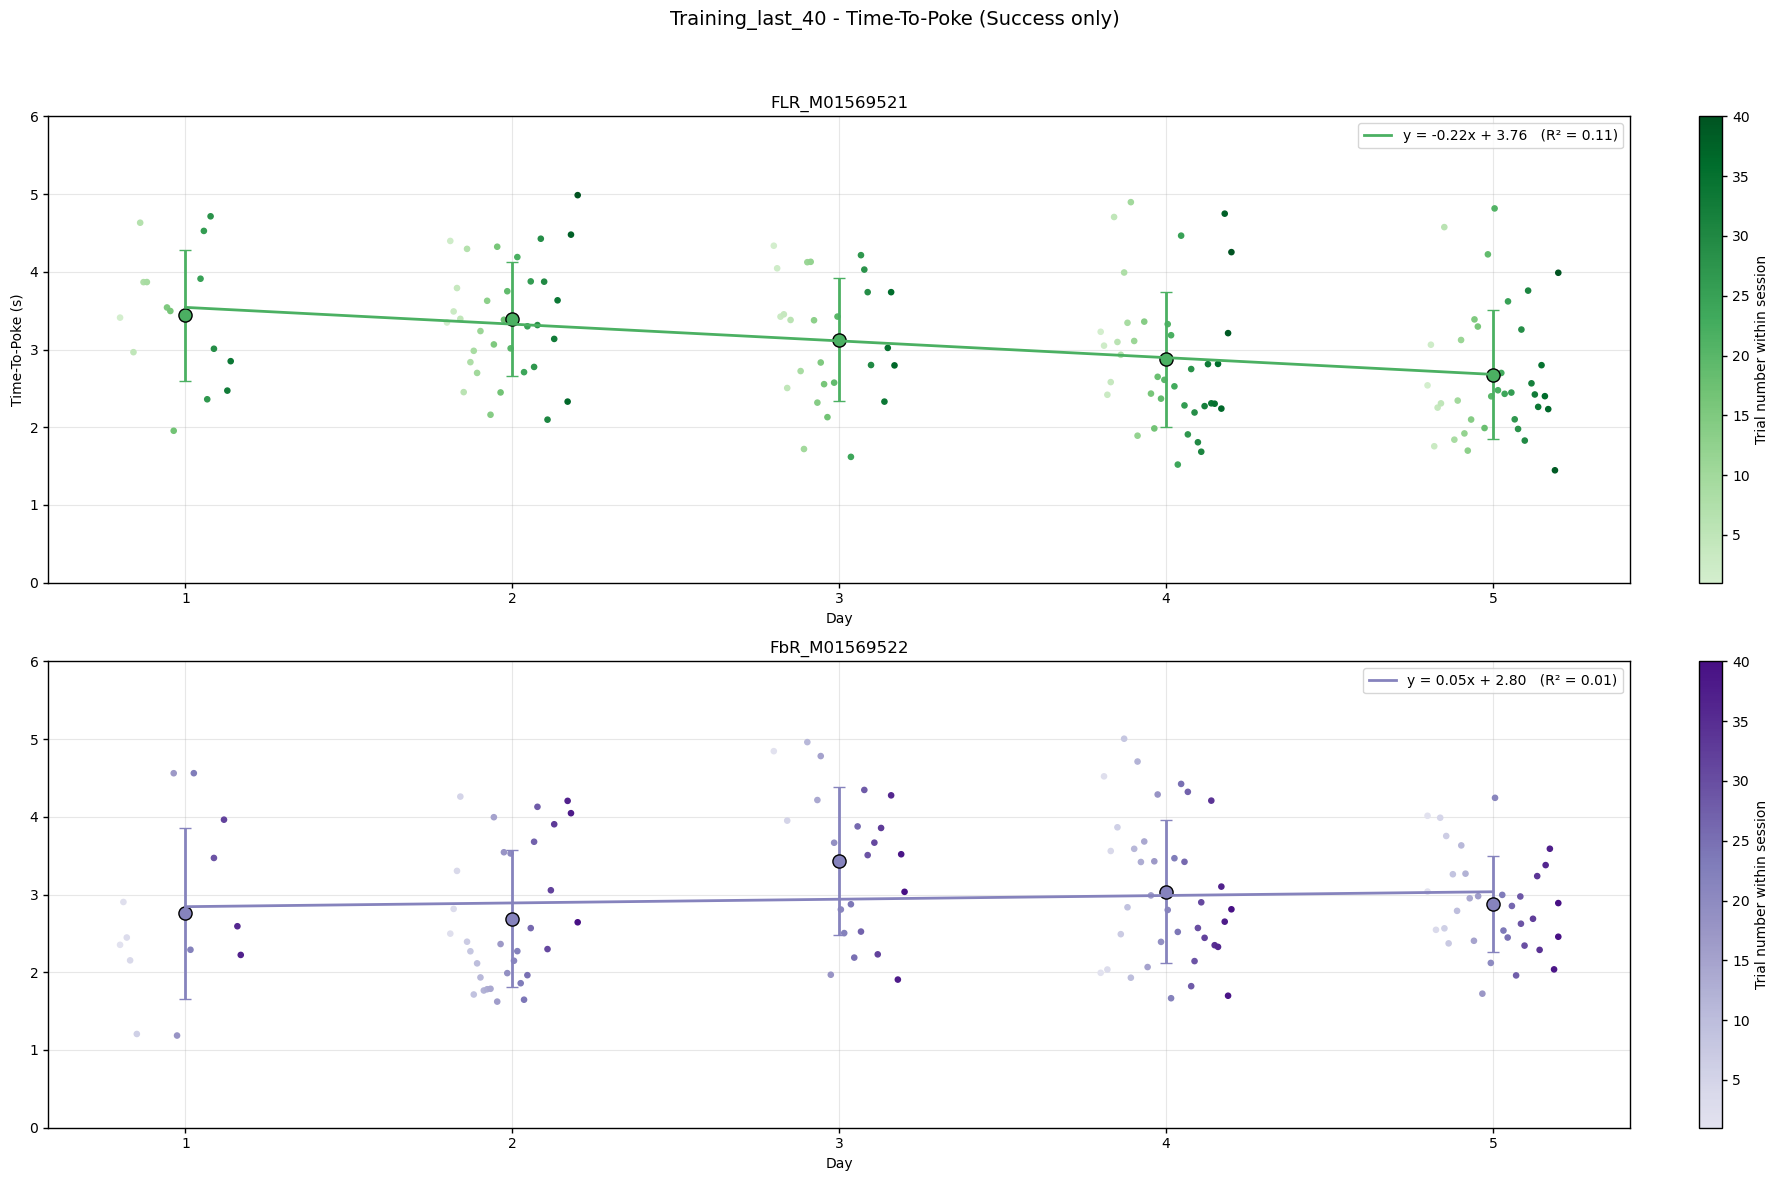

(<Figure size 1800x1200 with 4 Axes>,
 array([<Axes: title={'center': 'FLR_M01569521'}, xlabel='Day', ylabel='Time-To-Poke (s)'>,
        <Axes: title={'center': 'FbR_M01569522'}, xlabel='Day'>],
       dtype=object))

In [6]:
# Plot TTP across days for the "last_40" training dataset, including all trials.
plot_ttp_figure(dataset_df=training_dfs["last_40"],
                    trial_filter = "success_only",                  # "all" | "no_miss" | "success_only"
                    save_path = FIGURE_DIR,
                    mouse_IDs = mouse_IDs,
                    mouse_colours = mouse_colours,
                    days_to_plot = None,
                    title = None,
                    save_figures = SAVE_FIGURES,
                    append_date = APPEND_DATE,
                    display_figure = DISPLAY_FIGURES,
                    fig_format = FIG_FORMAT,
                    dpi = DPI,
                    figsize = (18, 12),
                    point_size = 14,                     # per-trial scatter dots
                    mean_size = 90,                      # mean overlay marker
                    jitter_width = 0.4,                  # +/-(jitter_width/2) around the day
                    y_min = 0.0,                         # lower y-axis limit (TTP seconds)
                    y_max_floor = 6.0,                   # y-axis upper limit is max(y_max_floor, observed TTP max)
                    display_summary_statistics = True,    # print mini per-(mouse, day) stats table
)

### Figure 3 Function: Plot Angle Offset
----------------------------

3) Plot Angle Offset for each mouse, across days, for each profile (all_trials, last_40, last_25).
    - Scatterplot, y-axis  is set to +/- 180 degrees, with 0 at the center.
    - Both mice on same plot, with different colours. Colour map using alpha to indicate how early/late the trial is in the session (e.g. early trials = more transparent, later trials = more opaque).
    - Add mean point and error bars (e.g. SEM) for each day, for each mouse.
    - Exclude trials where angle offset is NaN. Provide summary text below plot indicating the number of trials included for each mouse, for each day.

    - Plot some form of regression that shows if the magnitude of offsets (on both +ive and -ive offset angles) converges towards zero (Maybe there should be two regressions or lines of best fit? maybe they are not linear?)
    

In [7]:
def plot_angle_offset_figure(dataset_df: pd.DataFrame = training_dfs["all_trials"],
                             trial_filter: str = "all",                  # "all" | "no_miss" | "no_success" | "success_only"
                             save_path: Optional[Path] = FIGURE_DIR,
                             mouse_IDs: Optional[list] = mouse_IDs,
                             mouse_colours: Optional[dict] = mouse_colours,
                             mouse_cmaps: Optional[dict] = mouse_cmaps,
                             days_to_plot: Optional[list] = None,
                             title: Optional[str] = None,
                             save_figures: Optional[bool] = SAVE_FIGURES,
                             append_date: Optional[bool] = APPEND_DATE,
                             display_figure: Optional[bool] = DISPLAY_FIGURES,
                             fig_format: Optional[str] = FIG_FORMAT,
                             dpi: Optional[int] = DPI,
                             figsize: Optional[tuple] = (14, 6),
                             point_size: float = 14,
                             jitter_width: float = 0.4,
                             y_limit: float = 180.0,
                             display_summary_statistics: bool = True,
):
    """
    Plot signed angle_offset across days as a pure scatterplot, one subplot
    per mouse. Per-trial dots are coloured by within-session rank (colourbar
    on the right shows trial number). Y-axis is symmetric, defaulting to
    +/-180 degrees; a dashed horizontal line marks the zero-error reference.

    No per-day markers or regression lines here -- if you want to fit a
    convergence trend, use plot_abs_angle_offset_figure instead (it operates
    on |angle_offset| and supports linear and exponential best-fit overlays).

    Trials with NaN angle_offset (Miss trials) are dropped.

    Returns
    -------
    (fig, axes) : matplotlib Figure and ndarray of Axes (one per mouse).
    """

    #==== 1. Derive the dataset name from the dataframe ============================
    train_test = dataset_df["training/testing"].iloc[0]
    profile = dataset_df["filter_profile"].iloc[0]
    dataset_name = f"{train_test.capitalize()}_{profile}"

    #==== 2. Filter mice / days; compute within-session rank =======================
    # Rank is computed on the FULL session (pre-trial_filter, pre-NaN-drop), so
    # each trial's colour and x-jitter reflect its actual position in the
    # session regardless of which subset gets plotted.
    df_all_trials = dataset_df[dataset_df["mouseID"].isin(mouse_IDs)].copy()
    df_all_trials["day_num"] = df_all_trials["day"].astype(str).str.extract(r"(\d+)").astype(int)

    if days_to_plot is not None:
        df_all_trials = df_all_trials[df_all_trials["day_num"].isin(days_to_plot)]

    def _rank_norm(group):
        n = len(group)
        if n <= 1:
            return pd.Series(np.full(n, 0.5), index=group.index)
        ranks = group["trial_index"].rank(method="first").to_numpy() - 1
        return pd.Series(ranks / (n - 1), index=group.index)

    df_all_trials["rank_norm"] = df_all_trials.groupby("session", group_keys=False).apply(_rank_norm)
    df_all_trials["x_jittered"] = df_all_trials["day_num"] + (df_all_trials["rank_norm"] - 0.5) * jitter_width

    #==== 3. Apply trial_filter and drop NaN angle_offset ==========================
    df = df_all_trials.copy()
    if trial_filter == "success_only":
        df = df[df["outcome"] == "Success"]
    elif trial_filter == "no_miss":
        df = df[df["outcome"] != "Miss"]
    elif trial_filter == "no_success":
        df = df[df["outcome"] != "Success"]
    elif trial_filter != "all":
        raise ValueError(
            f"trial_filter must be 'all', 'no_miss', 'no_success', or 'success_only'; got {trial_filter!r}"
        )
    df = df[df["angle_offset"].notna()]

    #==== 4. Summary stats =========================================================
    counts = (
        df_all_trials
          .groupby(["mouseID", "day_num"])
          .agg(n_trials=("outcome", "size"),
               n_success=("outcome", lambda s: (s == "Success").sum()),
               n_fail=("outcome", lambda s: (s == "Failure").sum()),
               n_miss=("outcome", lambda s: (s == "Miss").sum()))
          .reset_index()
    )
    angle_stats = (
        df.groupby(["mouseID", "day_num"])["angle_offset"]
          .agg(n_angle="count",
               mean="mean",
               sd=lambda s: s.std(ddof=1),
               median="median",
               min="min",
               max="max",
               n_pos=lambda s: int((s > 0).sum()),
               n_neg=lambda s: int((s < 0).sum()))
          .reset_index()
    )
    summary = counts.merge(angle_stats, on=["mouseID", "day_num"], how="left")

    #==== 5. Plot: scatter + colourbar per mouse ===================================
    n_mice = len(mouse_IDs)
    fig, axes = plt.subplots(n_mice, 1, figsize=figsize, sharey=True, squeeze=False)
    axes = axes.flatten()

    CMAP_LOW, CMAP_HIGH = 0.2, 0.95

    for ax, mouse in zip(axes, mouse_IDs):
        mouse_df = df[df["mouseID"] == mouse]
        cmap = mouse_cmaps[mouse]

        # (a) Per-trial scatter, coloured by within-session rank.
        cmap_vals = CMAP_LOW + (CMAP_HIGH - CMAP_LOW) * mouse_df["rank_norm"].to_numpy()
        ax.scatter(mouse_df["x_jittered"], mouse_df["angle_offset"],
                   c=cmap(cmap_vals), s=point_size, zorder=2)

        # (b) Trial-within-session colourbar (numeric).
        mouse_all = df_all_trials[df_all_trials["mouseID"] == mouse]
        n_max = int(mouse_all.groupby("session").size().max()) if len(mouse_all) else 1
        sliced_cmap = plt.matplotlib.colors.ListedColormap(
            cmap(np.linspace(CMAP_LOW, CMAP_HIGH, 256))
        )
        sm = plt.matplotlib.cm.ScalarMappable(
            cmap=sliced_cmap,
            norm=plt.matplotlib.colors.Normalize(vmin=1, vmax=max(n_max, 2)),
        )
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=ax, fraction=0.04, pad=0.04)
        cbar.set_label("Trial number within session")

        # Zero-error reference line.
        ax.axhline(0, color="grey", linewidth=0.8, linestyle=":", zorder=1)
        ax.set_xticks(sorted(df_all_trials["day_num"].unique()))
        ax.set_xlabel("Day")
        ax.set_title(mouse)

    axes[0].set_ylabel("Angle offset (degrees)")
    axes[0].set_ylim(-y_limit, y_limit)
    axes[0].set_yticks([-y_limit, -y_limit / 2, 0, y_limit / 2, y_limit])

    #==== 6. Title, summary, save, show ============================================
    filter_label = {"all": "all trials",
                    "no_miss": "Success + Failure",
                    "no_success": "Errors only (Failure)",
                    "success_only": "Success only"}[trial_filter]

    fig.suptitle(title or f"{dataset_name} - Angle Offset ({filter_label})")

    if display_summary_statistics:
        summary_table = summary.set_index(["day_num", "mouseID"]).sort_index()
        print(f"=== Summary statistics: {dataset_name} (trial_filter={trial_filter!r}) ===")
        display(summary_table.round(3))
    fig.tight_layout(rect=(0, 0, 1, 0.95))

    if save_figures and save_path is not None:
        stem = f"{dataset_name}_angle_{trial_filter}_plot"
        if append_date:
            stem += f"_{pd.Timestamp.today().strftime('%Y-%m-%d')}"
        fig.savefig(Path(save_path) / f"{stem}.{fig_format}",
                    dpi=dpi, format=fig_format, bbox_inches="tight")

    if display_figure:
        plt.show()
    else:
        plt.close(fig)

    return fig, axes


=== Summary statistics: Training_all_trials (trial_filter='all') ===


/tmp/ipykernel_2892238/3405151723.py:59: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_all_trials["rank_norm"] = df_all_trials.groupby("session", group_keys=False).apply(_rank_norm)


n_trials  n_success  n_fail  n_miss  n_angle    mean  \
day_num mouseID                                                               
1       FLR_M01569521        64         24       7      33       31   9.677   
        FbR_M01569522        44         13      17      14       30 -23.333   
2       FLR_M01569521        63         44       1      18       45  -1.333   
        FbR_M01569522        88         69       9      10       78  -4.615   
3       FLR_M01569521        58         36       2      20       38   1.053   
        FbR_M01569522        61         29      14      18       43  -6.512   
4       FLR_M01569521       109         95       0      14       95   0.000   
        FbR_M01569522        79         66       8       5       74   2.432   
5       FLR_M01569521       104         86       0      18       86   0.000   
        FbR_M01569522        84         73       4       7       77   0.779   

                           sd  median    min    max  n_pos  n_neg  
day_num mouseID                                                    
1       FLR_M01569521  71.156     0.0 -180.0  160.0      4      3  
        FbR_M01569522  37.905     0.0 -120.0   20.0      3     14  
2       FLR_M01569521   8.944     0.0  -60.0    0.0      0      1  
        FbR_M01569522  31.896     0.0 -180.0  160.0      1      8  
3       FLR_M01569521   4.526     0.0    0.0   20.0      2      0  
        FbR_M01569522  49.899     0.0 -160.0  100.0      8      6  
4       FLR_M01569521   0.000     0.0    0.0    0.0      0      0  
        FbR_M01569522   9.905     0.0  -20.0   60.0      7      1  
5       FLR_M01569521   0.000     0.0    0.0    0.0      0      0  
        FbR_M01569522   9.969     0.0  -20.0   80.0      2      2

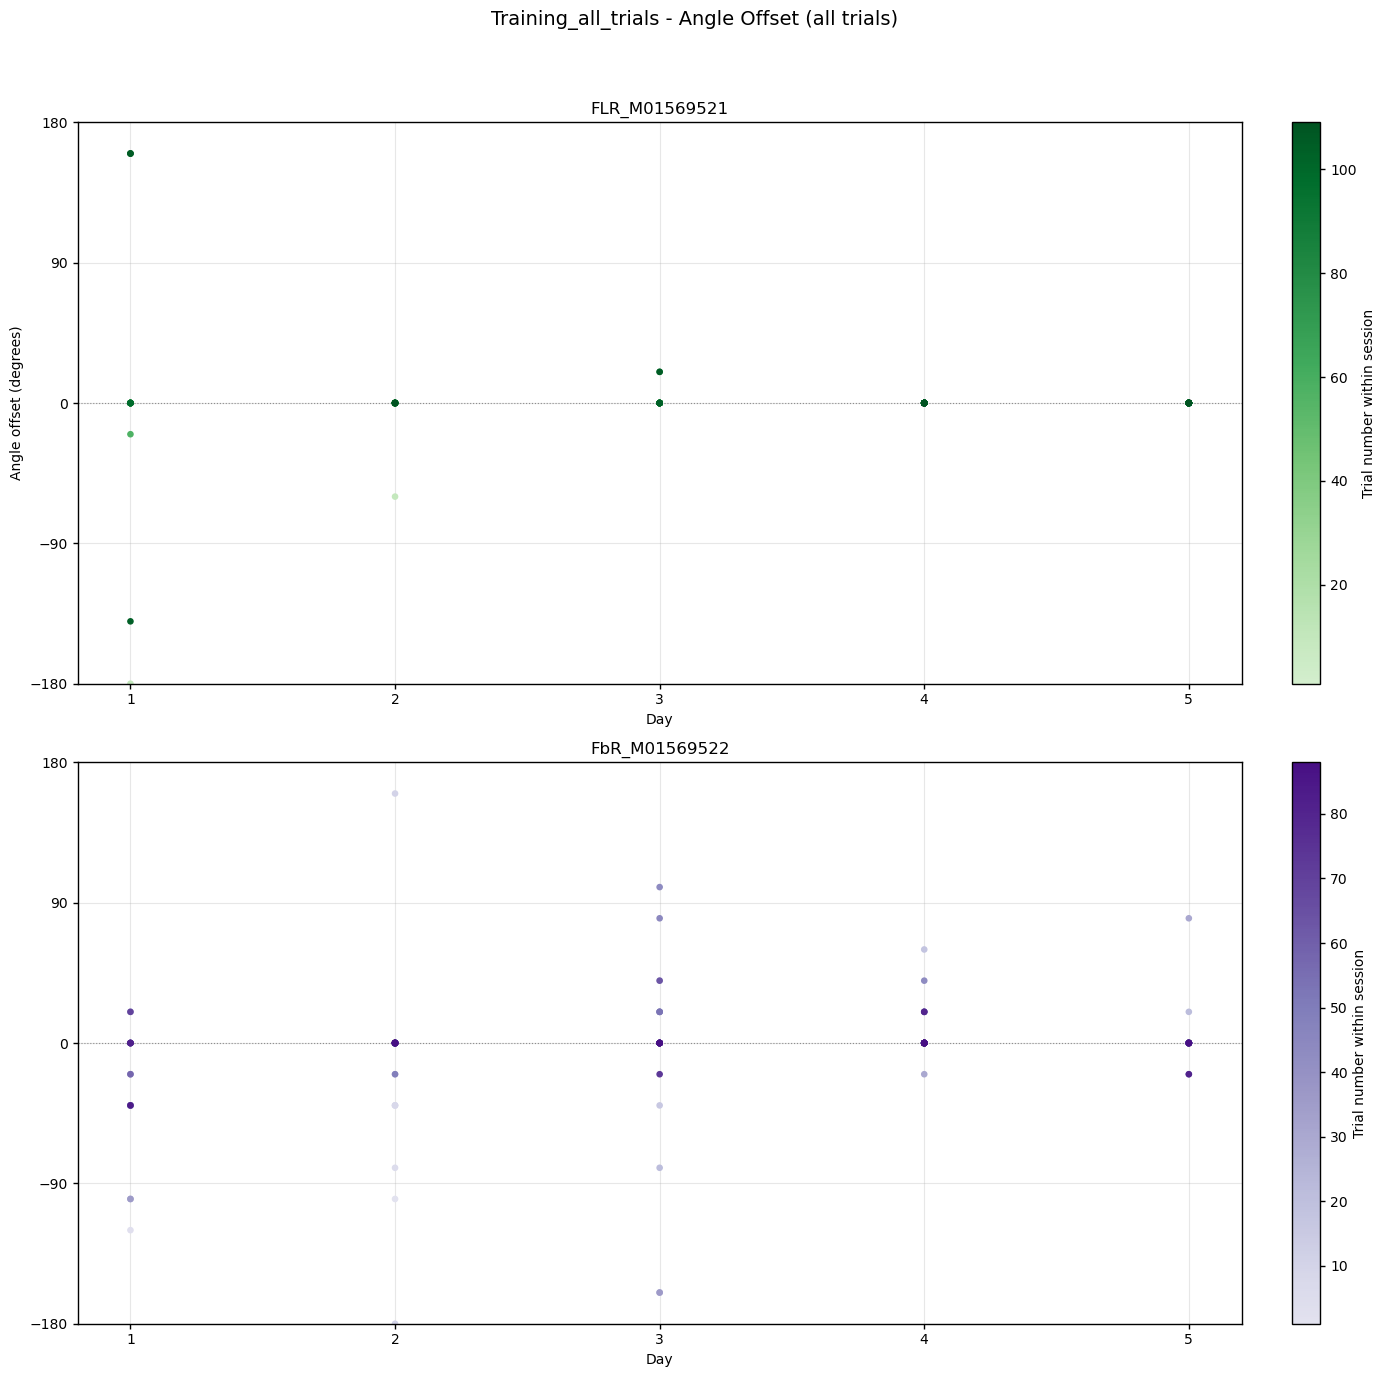

(<Figure size 1400x1400 with 4 Axes>,
 array([<Axes: title={'center': 'FLR_M01569521'}, xlabel='Day', ylabel='Angle offset (degrees)'>,
        <Axes: title={'center': 'FbR_M01569522'}, xlabel='Day'>],
       dtype=object))

In [8]:
# Plot angle offset across days for the "last_40" training dataset, including all trials with non-NaN angles (i.e. Success and Failure).
plot_angle_offset_figure(dataset_df = training_dfs["all_trials"],
                             trial_filter = "all",                  # "all" | "no_miss" | "no_success" | "success_only"
                             save_path = FIGURE_DIR,
                             mouse_IDs = mouse_IDs,
                             mouse_colours = mouse_colours,
                             mouse_cmaps = mouse_cmaps,
                             days_to_plot = None,
                             title = None,
                             save_figures = SAVE_FIGURES,
                             append_date = APPEND_DATE,
                             display_figure = DISPLAY_FIGURES,
                             fig_format = FIG_FORMAT,
                             dpi = DPI,
                             figsize = (14, 14),
                             point_size = 14,
                             jitter_width = 0.0,
                             y_limit = 180.0,
                             display_summary_statistics = True,
)

### Figure 3b Function: Plot |Angle Offset| with linear and exponential best-fit overlays
----------------------------

Same shape as Figure 3 but on `|angle_offset|`. Y-axis runs `0..y_limit`. 
`fit_methods` accepts any subset of `("linear", "exponential")` -- pass `()` 
to skip overlays entirely.

In [9]:
def plot_abs_angle_offset_figure(dataset_df: pd.DataFrame = training_dfs["last_40"],
                                 trial_filter: str = "all",                  # "all" | "no_miss" | "no_success" | "success_only"
                                 save_path: Optional[Path] = FIGURE_DIR,
                                 mouse_IDs: Optional[list] = mouse_IDs,
                                 mouse_colours: Optional[dict] = mouse_colours,
                                 mouse_cmaps: Optional[dict] = mouse_cmaps,
                                 days_to_plot: Optional[list] = None,
                                 title: Optional[str] = None,
                                 save_figures: Optional[bool] = SAVE_FIGURES,
                                 append_date: Optional[bool] = APPEND_DATE,
                                 display_figure: Optional[bool] = DISPLAY_FIGURES,
                                 fig_format: Optional[str] = FIG_FORMAT,
                                 dpi: Optional[int] = DPI,
                                 figsize: Optional[tuple] = (14, 6),
                                 point_size: float = 14,
                                 jitter_width: float = 0.4,
                                 y_limit: float = 180.0,
                                 fit_methods: tuple = ("linear", "exponential"),  # any subset of ("linear", "exponential")
                                 display_summary_statistics: bool = True,
):
    """
    Plot |angle_offset| (error magnitude) across days as a scatterplot, one
    subplot per mouse, with optional best-fit overlays.

    Fits
    ----
    fit_methods is a tuple of any combination of:
        "linear"      -- y = m*x + b   via scipy.stats.linregress
        "exponential" -- y = a*exp(-b*x) + c   via scipy.optimize.curve_fit
    Pass () for no fit overlays. Each successful fit is drawn over the day
    range with its equation and R^2 in the legend. Linear lines are solid,
    exponential lines are dashed.

    Trials with NaN angle_offset (Miss trials) are dropped. Y-axis runs from
    0 to y_limit (default 180 degrees).
    """

    from scipy.optimize import curve_fit   # local import keeps the imports cell unchanged

    #==== 1. Derive the dataset name from the dataframe ============================
    train_test = dataset_df["training/testing"].iloc[0]
    profile = dataset_df["filter_profile"].iloc[0]
    dataset_name = f"{train_test.capitalize()}_{profile}"

    #==== 2. Filter mice / days; compute within-session rank =======================
    df_all_trials = dataset_df[dataset_df["mouseID"].isin(mouse_IDs)].copy()
    df_all_trials["day_num"] = df_all_trials["day"].astype(str).str.extract(r"(\d+)").astype(int)

    if days_to_plot is not None:
        df_all_trials = df_all_trials[df_all_trials["day_num"].isin(days_to_plot)]

    def _rank_norm(group):
        n = len(group)
        if n <= 1:
            return pd.Series(np.full(n, 0.5), index=group.index)
        ranks = group["trial_index"].rank(method="first").to_numpy() - 1
        return pd.Series(ranks / (n - 1), index=group.index)

    df_all_trials["rank_norm"] = df_all_trials.groupby("session", group_keys=False).apply(_rank_norm)
    df_all_trials["x_jittered"] = df_all_trials["day_num"] + (df_all_trials["rank_norm"] - 0.5) * jitter_width

    #==== 3. Apply trial_filter, drop NaN angle, add |angle_offset| column =========
    df = df_all_trials.copy()
    if trial_filter == "success_only":
        df = df[df["outcome"] == "Success"]
    elif trial_filter == "no_miss":
        df = df[df["outcome"] != "Miss"]
    elif trial_filter == "no_success":
        df = df[df["outcome"] != "Success"]
    elif trial_filter != "all":
        raise ValueError(
            f"trial_filter must be 'all', 'no_miss', 'no_success', or 'success_only'; got {trial_filter!r}"
        )
    df = df[df["angle_offset"].notna()].copy()
    df["abs_offset"] = df["angle_offset"].abs()

    #==== 4. Summary stats on |angle_offset| =======================================
    counts = (
        df_all_trials
          .groupby(["mouseID", "day_num"])
          .agg(n_trials=("outcome", "size"),
               n_success=("outcome", lambda s: (s == "Success").sum()),
               n_fail=("outcome", lambda s: (s == "Failure").sum()),
               n_miss=("outcome", lambda s: (s == "Miss").sum()))
          .reset_index()
    )
    abs_stats = (
        df.groupby(["mouseID", "day_num"])["abs_offset"]
          .agg(n_angle="count",
               mean="mean",
               sd=lambda s: s.std(ddof=1),
               median="median",
               min="min",
               max="max")
          .reset_index()
    )
    summary = counts.merge(abs_stats, on=["mouseID", "day_num"], how="left")

    #==== 5. Plot: scatter + colourbar + fits per mouse ============================
    n_mice = len(mouse_IDs)
    fig, axes = plt.subplots(n_mice, 1, figsize=figsize, sharey=True, squeeze=False)
    axes = axes.flatten()

    CMAP_LOW, CMAP_HIGH = 0.2, 0.95

    def _exp_model(x, a, b, c):
        return a * np.exp(-b * x) + c

    for ax, mouse in zip(axes, mouse_IDs):
        mouse_df = df[df["mouseID"] == mouse]
        cmap = mouse_cmaps[mouse]
        mean_colour = mouse_colours[mouse]

        # (a) Per-trial scatter of |angle_offset|, coloured by within-session rank.
        cmap_vals = CMAP_LOW + (CMAP_HIGH - CMAP_LOW) * mouse_df["rank_norm"].to_numpy()
        ax.scatter(mouse_df["x_jittered"], mouse_df["abs_offset"],
                   c=cmap(cmap_vals), s=point_size, zorder=2)

        # (b) Optional best-fit overlays. Both fits run on per-trial data.
        x = mouse_df["day_num"].to_numpy(dtype=float)
        y = mouse_df["abs_offset"].to_numpy(dtype=float)
        have_enough = np.unique(x).size >= 2 and len(y) >= 3 and np.ptp(y) > 0
        x_line = np.linspace(x.min(), x.max(), 200) if have_enough else None

        if "linear" in fit_methods and have_enough:
            fit = stats.linregress(x, y)
            ax.plot(x_line, fit.slope * x_line + fit.intercept,
                    color=mean_colour, linewidth=2, linestyle="-",
                    zorder=5,
                    label=(f"lin:  y = {fit.slope:.2f}x + {fit.intercept:.2f}"
                           f"   (R² = {fit.rvalue ** 2:.2f})"))

        if "exponential" in fit_methods and have_enough:
            # p0: start from amplitude = range(y), decay 0.3/day, asymptote = min(y)
            p0 = [float(y.max() - y.min()), 0.3, float(y.min())]
            try:
                popt, _ = curve_fit(_exp_model, x, y, p0=p0, maxfev=5000)
                y_pred = _exp_model(x, *popt)
                ss_res = np.sum((y - y_pred) ** 2)
                ss_tot = np.sum((y - y.mean()) ** 2)
                r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
                a, b, c = popt
                ax.plot(x_line, _exp_model(x_line, *popt),
                        color=mean_colour, linewidth=2, linestyle="--",
                        zorder=5,
                        label=(f"exp: y = {a:.2f}·e^(-{b:.3f}x) + {c:.2f}"
                               f"   (R² = {r2:.2f})"))
            except (RuntimeError, ValueError) as e:
                print(f"Exponential fit failed for {mouse}: {e}")

        # (c) Trial-within-session colourbar (numeric).
        mouse_all = df_all_trials[df_all_trials["mouseID"] == mouse]
        n_max = int(mouse_all.groupby("session").size().max()) if len(mouse_all) else 1
        sliced_cmap = plt.matplotlib.colors.ListedColormap(
            cmap(np.linspace(CMAP_LOW, CMAP_HIGH, 256))
        )
        sm = plt.matplotlib.cm.ScalarMappable(
            cmap=sliced_cmap,
            norm=plt.matplotlib.colors.Normalize(vmin=1, vmax=max(n_max, 2)),
        )
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=ax, fraction=0.04, pad=0.04)
        cbar.set_label("Trial number within session")

        ax.set_xticks(sorted(df_all_trials["day_num"].unique()))
        ax.set_xlabel("Day")
        ax.set_title(mouse)
        if fit_methods:
            ax.legend(loc="best")

    axes[0].set_ylabel("|Angle offset| (degrees)")
    axes[0].set_ylim(0, y_limit)
    axes[0].set_yticks([0, y_limit / 4, y_limit / 2, 3 * y_limit / 4, y_limit])

    #==== 6. Title, summary, save, show ============================================
    filter_label = {"all": "all trials",
                    "no_miss": "Success + Failure",
                    "no_success": "Errors only (Failure)",
                    "success_only": "Success only"}[trial_filter]

    fig.suptitle(title or f"{dataset_name} - |Angle Offset| ({filter_label})")

    if display_summary_statistics:
        summary_table = summary.set_index(["day_num", "mouseID"]).sort_index()
        print(f"=== Summary statistics: {dataset_name} (trial_filter={trial_filter!r}) ===")
        display(summary_table.round(3))
    fig.tight_layout(rect=(0, 0, 1, 0.95))

    if save_figures and save_path is not None:
        stem = f"{dataset_name}_abs_angle_{trial_filter}_plot"
        if append_date:
            stem += f"_{pd.Timestamp.today().strftime('%Y-%m-%d')}"
        fig.savefig(Path(save_path) / f"{stem}.{fig_format}",
                    dpi=dpi, format=fig_format, bbox_inches="tight")

    if display_figure:
        plt.show()
    else:
        plt.close(fig)

    return fig, axes


=== Summary statistics: Training_all_trials (trial_filter='no_success') ===


/tmp/ipykernel_2892238/338652183.py:59: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_all_trials["rank_norm"] = df_all_trials.groupby("session", group_keys=False).apply(_rank_norm)


n_trials  n_success  n_fail  n_miss  n_angle     mean  \
day_num mouseID                                                                
1       FLR_M01569521        64         24       7      33      7.0  140.000   
        FbR_M01569522        44         13      17      14     17.0   48.235   
2       FLR_M01569521        63         44       1      18      1.0   60.000   
        FbR_M01569522        88         69       9      10      9.0   75.556   
3       FLR_M01569521        58         36       2      20      2.0   20.000   
        FbR_M01569522        61         29      14      18     14.0   68.571   
4       FLR_M01569521       109         95       0      14      NaN      NaN   
        FbR_M01569522        79         66       8       5      8.0   27.500   
5       FLR_M01569521       104         86       0      18      NaN      NaN   
        FbR_M01569522        84         73       4       7      4.0   35.000   

                           sd  median   min    max  
day_num mouseID                                     
1       FLR_M01569521  54.160   160.0  20.0  180.0  
        FbR_M01569522  33.955    40.0  20.0  120.0  
2       FLR_M01569521     NaN    60.0  60.0   60.0  
        FbR_M01569522  59.815    40.0  20.0  180.0  
3       FLR_M01569521   0.000    20.0  20.0   20.0  
        FbR_M01569522  55.865    40.0  20.0  160.0  
4       FLR_M01569521     NaN     NaN   NaN    NaN  
        FbR_M01569522  14.880    20.0  20.0   60.0  
5       FLR_M01569521     NaN     NaN   NaN    NaN  
        FbR_M01569522  30.000    20.0  20.0   80.0

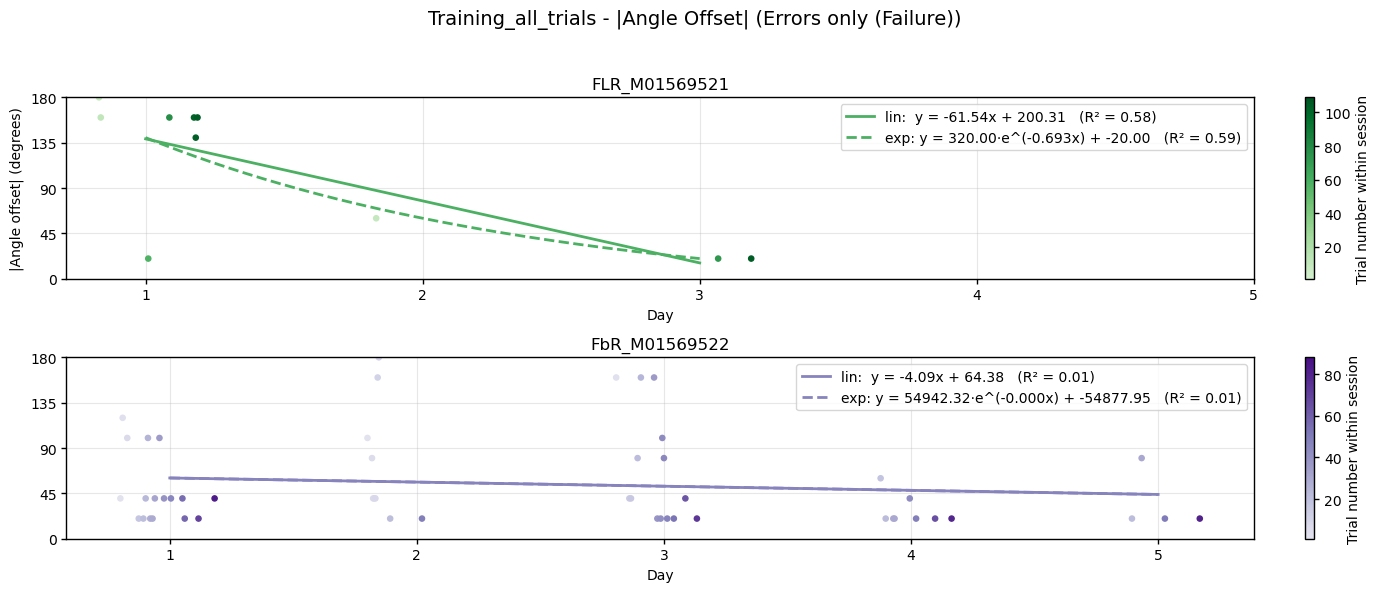

(<Figure size 1400x600 with 4 Axes>,
 array([<Axes: title={'center': 'FLR_M01569521'}, xlabel='Day', ylabel='|Angle offset| (degrees)'>,
        <Axes: title={'center': 'FbR_M01569522'}, xlabel='Day'>],
       dtype=object))

In [10]:
# Plot |angle_offset| across days for the "last_40" training dataset, including only Success trials. Fit both linear and exponential convergence trends.

plot_abs_angle_offset_figure(dataset_df = training_dfs["all_trials"],
                                 trial_filter = "no_success",                  # "all" | "no_miss" | "no_success" | "success_only"
                                 save_path = FIGURE_DIR,
                                 mouse_IDs = mouse_IDs,
                                 mouse_colours = mouse_colours,
                                 mouse_cmaps = mouse_cmaps,
                                 days_to_plot = None,
                                 title = None,
                                 save_figures = SAVE_FIGURES,
                                 append_date = APPEND_DATE,
                                 display_figure = DISPLAY_FIGURES,
                                 fig_format = FIG_FORMAT,
                                 dpi = DPI,
                                 figsize = (14, 6),
                                 point_size = 14,
                                 jitter_width = 0.4,
                                 y_limit = 180.0,
                                 fit_methods = ("linear", "exponential"),  # any subset of ("linear", "exponential")
                                 display_summary_statistics = True,
)

### Figure 4 Function: Generate Summary Statistics
----------------------------


Summary Statistics:
    - For each profile (all_trials, last_40, last_25), for each day, for each mouse, calculate and display "table of key statistics" including:

    i. Subtable 1: Trial Statistics

        - Total number of trials
        - Total number of success, miss, fail trials
        - Max, min, mean, median, SEM of time-to-poke for:
             - all trials
             - success trials only 
             - success+fail trials.
        - Max, min, mean, median, SEM of angle offset for:
             - all trials
             - success trials only
             - success+fail trials.

    ii. Subtable(s) 2: Correlations
        - calculate the correlation between time-to-poke and angle offset, and display the correlation coefficient and p-value in the summary statistics table.
        - calculate the correlation between trial number and time-to-poke, and display the correlation coefficient and p-value in the summary statistics table.
        - calculate the correlation between trial number and angle offset, and display the correlation coefficient and p-value in the summary statistics table.
        - calculate the correlation between time-to-poke and trial outcome, and display the correlation coefficient and p-value in the summary statistics table.
            - For each outcome separately
        - calculate the correlation between target_zone_size and likelihood of success, and display the correlation coefficient and p-value in the summary statistics table.

    iii. Plot any appropriate correlations on figures where suitable if needed
    
    




In [11]:
def summarise_dataset(dataset_df: pd.DataFrame = training_dfs["last_40"],
                      mouse_IDs: list = mouse_IDs,
                      days_to_plot: Optional[list] = None,
                      save_path: Optional[Path] = FIGURE_DIR,
                      title: Optional[str] = None,
                      save_figures: Optional[bool] = SAVE_FIGURES,
                      append_date: Optional[bool] = APPEND_DATE,
                      display_figure: Optional[bool] = DISPLAY_FIGURES,
                      fig_format: Optional[str] = FIG_FORMAT,
                      dpi: Optional[int] = DPI,
                      figsize: Optional[tuple] = (12, 5),
                      corr_method: str = "spearman",       # "spearman" (rank-based, default) or "pearson"
                      display_summary_statistics: bool = True,
):
    """
    Produce two artefacts for a single dataset (one profile, e.g. last_40):

    1. A consolidated per-(mouse, day) stats table with outcome counts and
       summary stats (n, mean, SD, median, min, max) on TTP and |angle_offset|.

    2. A correlation heatmap with one subplot per mouse, showing the Pearson
       correlation matrix among five trial-level variables:
            - TTP
            - |angle_offset|
            - trial_index       (within-session position)
            - target_zone_size
            - is_success        (1 if outcome == "Success" else 0)
       Correlations are computed by pooling every trial for that mouse in
       the supplied dataset (i.e. across days). Per-day correlations are too
       low-n (~25-40 trials) to be informative; pooled they're n ~= 100-200.
       Default method is Spearman (rank-based) because |angle_offset| is
       heavily 0-inflated and TTP is right-skewed -- both violate Pearson's
       assumptions. Pass corr_method="pearson" if you specifically want it.

    Trials with NaN angle_offset (Miss trials) are dropped from the
    correlation matrix only; they still appear in the trial-count columns
    of the stats table.

    Returns
    -------
    (summary_table, fig, axes)
    """

    #==== 1. Dataset name =========================================================
    train_test = dataset_df["training/testing"].iloc[0]
    profile = dataset_df["filter_profile"].iloc[0]
    dataset_name = f"{train_test.capitalize()}_{profile}"

    #==== 2. Filter mice / days; derive helper columns ============================
    df = dataset_df[dataset_df["mouseID"].isin(mouse_IDs)].copy()
    df["day_num"] = df["day"].astype(str).str.extract(r"(\d+)").astype(int)
    if days_to_plot is not None:
        df = df[df["day_num"].isin(days_to_plot)]

    df["abs_offset"] = df["angle_offset"].abs()
    df["is_success"] = (df["outcome"] == "Success").astype(int)

    #==== 3. Consolidated per-(mouse, day) stats table ============================
    # Outcome counts (from all trials), then TTP and |angle| stats (NaN angles
    # are skipped by pandas' aggregators, so no need to pre-filter).
    counts = (
        df.groupby(["mouseID", "day_num"])
          .agg(n_trials=("outcome", "size"),
               n_success=("outcome", lambda s: (s == "Success").sum()),
               n_fail=("outcome", lambda s: (s == "Failure").sum()),
               n_miss=("outcome", lambda s: (s == "Miss").sum()))
          .reset_index()
    )
    ttp_stats = (
        df.groupby(["mouseID", "day_num"])["TTP"]
          .agg(ttp_n="count",
               ttp_mean="mean",
               ttp_sd=lambda s: s.std(ddof=1),
               ttp_median="median",
               ttp_min="min",
               ttp_max="max")
          .reset_index()
    )
    absangle_stats = (
        df.groupby(["mouseID", "day_num"])["abs_offset"]
          .agg(absangle_n="count",
               absangle_mean="mean",
               absangle_sd=lambda s: s.std(ddof=1),
               absangle_median="median",
               absangle_min="min",
               absangle_max="max")
          .reset_index()
    )
    # Unique target_zone_size values per (mouse, day), joined into a readable
    # string -- shows at a glance whether the zone size varied within a day.
    zone_sizes = (
        df.groupby(["mouseID", "day_num"])["target_zone_size"]
          .agg(zone_sizes=lambda s: ", ".join(f"{v:g}" for v in sorted(s.dropna().unique())))
          .reset_index()
    )

    summary_table = (
        counts.merge(ttp_stats, on=["mouseID", "day_num"], how="left")
              .merge(absangle_stats, on=["mouseID", "day_num"], how="left")
              .merge(zone_sizes, on=["mouseID", "day_num"], how="left")
              .set_index(["day_num", "mouseID"])
              .sort_index()
              .round(3)
    )

    if display_summary_statistics:
        print(f"=== Per-(mouse, day) summary: {dataset_name} ===")
        display(summary_table)

    #==== 4. Correlation heatmap, one subplot per mouse ===========================
    # Variables of interest. target_zone_size may be constant within a profile
    # (e.g. always 150 in training); in that case its row/column comes back
    # NaN -- the annotation is just skipped for those cells.
    corr_vars = ["TTP", "abs_offset", "trial_index", "target_zone_size", "is_success"]
    label_map = {"TTP": "TTP",
                 "abs_offset": "|angle|",
                 "trial_index": "trial idx",
                 "target_zone_size": "zone size",
                 "is_success": "is_success"}
    labels = [label_map[v] for v in corr_vars]

    n_mice = len(mouse_IDs)
    fig, axes = plt.subplots(1, n_mice, figsize=figsize, squeeze=False)
    axes = axes.flatten()

    for ax, mouse in zip(axes, mouse_IDs):
        # Drop Miss trials for the correlation since their |angle| is NaN.
        mouse_df = df[(df["mouseID"] == mouse) & df["angle_offset"].notna()]
        corr = mouse_df[corr_vars].corr(method=corr_method)

        im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
        ax.set_xticks(range(len(corr_vars)))
        ax.set_yticks(range(len(corr_vars)))
        ax.set_xticklabels(labels, rotation=45, ha="right")
        ax.set_yticklabels(labels)
        ax.set_title(f"{mouse}\n(n = {len(mouse_df)})")

        # Annotate each cell with its coefficient. White text on saturated
        # cells for legibility; skip NaN cells (constant variables).
        for i in range(len(corr_vars)):
            for j in range(len(corr_vars)):
                value = corr.values[i, j]
                if not np.isnan(value):
                    ax.text(j, i, f"{value:.2f}",
                            ha="center", va="center",
                            color="white" if abs(value) > 0.5 else "black",
                            fontsize=9)

        fig.colorbar(im, ax=ax, fraction=0.04, pad=0.04,
                     label=f"{corr_method.capitalize()} {chr(0x03c1) if corr_method == 'spearman' else 'r'}")

    fig.suptitle(title or f"{dataset_name} -- correlation matrix per mouse")
    fig.tight_layout(rect=(0, 0, 1, 0.94))

    #==== 5. Save / show ==========================================================
    if save_figures and save_path is not None:
        stem = f"{dataset_name}_correlation_matrix"
        if append_date:
            stem += f"_{pd.Timestamp.today().strftime('%Y-%m-%d')}"
        fig.savefig(Path(save_path) / f"{stem}.{fig_format}",
                    dpi=dpi, format=fig_format, bbox_inches="tight")

    if display_figure:
        plt.show()
    else:
        plt.close(fig)

    return summary_table, fig, axes


=== Per-(mouse, day) summary: Training_all_trials ===


n_trials  n_success  n_fail  n_miss  ttp_n  ttp_mean  \
day_num mouseID                                                               
1       FLR_M01569521        64         24       7      33     64     4.118   
        FbR_M01569522        44         13      17      14     44     3.430   
2       FLR_M01569521        63         44       1      18     63     3.845   
        FbR_M01569522        88         69       9      10     88     2.951   
3       FLR_M01569521        58         36       2      20     58     3.851   
        FbR_M01569522        61         29      14      18     61     3.632   
4       FLR_M01569521       109         95       0      14    109     3.236   
        FbR_M01569522        79         66       8       5     79     3.164   
5       FLR_M01569521       104         86       0      18    104     3.178   
        FbR_M01569522        84         73       4       7     84     3.181   

                       ttp_sd  ttp_median  ttp_min  ttp_max  absangle_n  \
day_num mouseID                                                           
1       FLR_M01569521   1.146       5.012    1.637    5.022          31   
        FbR_M01569522   1.367       3.361    1.186    5.017          30   
2       FLR_M01569521   0.997       3.849    1.771    5.026          45   
        FbR_M01569522   1.081       2.714    1.052    5.023          78   
3       FLR_M01569521   1.105       4.071    1.606    5.015          38   
        FbR_M01569522   1.205       3.667    1.436    5.030          43   
4       FLR_M01569521   1.069       2.975    1.520    5.032          95   
        FbR_M01569522   1.041       2.989    1.105    5.014          74   
5       FLR_M01569521   1.136       2.892    1.270    5.029          86   
        FbR_M01569522   0.888       2.991    1.725    5.024          77   

                       absangle_mean  absangle_sd  absangle_median  \
day_num mouseID                                                      
1       FLR_M01569521         31.613       64.244              0.0   
        FbR_M01569522         27.333       35.030             20.0   
2       FLR_M01569521          1.333        8.944              0.0   
        FbR_M01569522          8.718       31.016              0.0   
3       FLR_M01569521          1.053        4.526              0.0   
        FbR_M01569522         22.326       44.978              0.0   
4       FLR_M01569521          0.000        0.000              0.0   
        FbR_M01569522          2.973        9.754              0.0   
5       FLR_M01569521          0.000        0.000              0.0   
        FbR_M01569522          1.818        9.831              0.0   

                       absangle_min  absangle_max zone_sizes  
day_num mouseID                                               
1       FLR_M01569521           0.0         180.0        150  
        FbR_M01569522           0.0         120.0        150  
2       FLR_M01569521           0.0          60.0        150  
        FbR_M01569522           0.0         180.0        150  
3       FLR_M01569521           0.0          20.0        150  
        FbR_M01569522           0.0         160.0        150  
4       FLR_M01569521           0.0           0.0        150  
        FbR_M01569522           0.0          60.0        150  
5       FLR_M01569521           0.0           0.0        150  
        FbR_M01569522           0.0          80.0        150

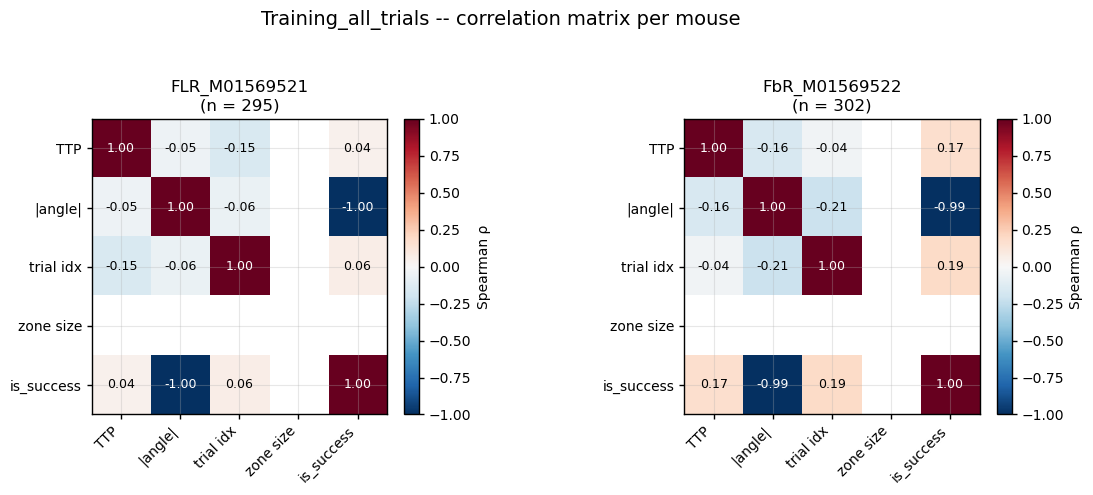

In [12]:
# Use the summarise_dataset function to produce a stats table and correlation heatmaps for the "last_40" training dataset.
summary_table, fig, axes = summarise_dataset(dataset_df = training_dfs["all_trials"],
                                             mouse_IDs = mouse_IDs,
                                             days_to_plot = None,                    # If None, every day in dataset_df is used
                                             save_path = FIGURE_DIR,
                                             title = None,                           # If None, uses "{dataset_name} -- correlation matrix per mouse"
                                             save_figures = SAVE_FIGURES,
                                             append_date = APPEND_DATE,
                                             display_figure = DISPLAY_FIGURES,
                                             fig_format = FIG_FORMAT,
                                             dpi = DPI,
                                             figsize = (12, 5),
                                             display_summary_statistics = True,
                                             )

### Utility: Plot summary columns over days
----------------------------

Operates on the per-(mouse, day) table from `summarise_dataset` (not the trial-level dataframe). 
Pass `columns=[...]` to plot one or more aggregated stats (e.g. `n_success`, `ttp_mean`, `absangle_median`) 
as markers + lines, one subplot per (mouse, column). Pass `columns=None` to plot every numeric column.

In [13]:
def plot_summary_over_days(summary_table: pd.DataFrame,
                           columns = None,                            # str, list[str], or None for every numeric column
                           save_path: Optional[Path] = FIGURE_DIR,
                           mouse_IDs: Optional[list] = mouse_IDs,
                           mouse_colours: Optional[dict] = mouse_colours,
                           dataset_name: Optional[str] = None,        # used in title and filename
                           title: Optional[str] = None,
                           ylabel: Optional[str] = None,              # single-column only
                           y_min: Optional[float] = None,             # single-column only
                           y_max: Optional[float] = None,             # single-column only
                           save_figures: Optional[bool] = SAVE_FIGURES,
                           append_date: Optional[bool] = APPEND_DATE,
                           display_figure: Optional[bool] = DISPLAY_FIGURES,
                           fig_format: Optional[str] = FIG_FORMAT,
                           dpi: Optional[int] = DPI,
                           figsize: Optional[tuple] = None,
                           marker_size: float = 80,
                           fit_methods: tuple = ("linear", "exponential"),         # any subset of ("linear", "exponential"); () for markers only
                           max_cols_per_row: int = 3,                # wrap to a new block of rows after this many columns
):
    """
    Plot one or more columns of a per-(mouse, day) summary table over days,
    one subplot per (mouse, column). Designed for the table produced by
    summarise_dataset.

    Each subplot draws a marker per day plus optional best-fit overlays --
    linear regression and/or exponential -- in the mouse's solid colour.
    Pass `fit_methods=()` to show only the markers. With multiple columns
    the layout is a grid: rows = mice, columns = variables. y-axes are
    shared per column so mice are visually comparable for each metric.
    With more than `max_cols_per_row` columns the grid wraps: each "block"
    of up to `max_cols_per_row` variables stacks on top of the next,
    keeping each subplot at a sensible minimum size.

    Fits use the same models as plot_abs_angle_offset_figure:
        "linear"      -- y = m*x + b      (scipy.stats.linregress)
        "exponential" -- y = a*exp(-b*x) + c   (scipy.optimize.curve_fit)
    Each successful fit is drawn over the day range with its equation and
    R^2 in the legend. Linear lines are solid, exponential lines dashed.

    Usage:
        summary_table, _, _ = summarise_dataset(training_dfs["last_40"], display_figure=False)
        plot_summary_over_days(summary_table,
                               columns=["n_success", "ttp_mean", "absangle_median"],
                               dataset_name="Training_last_40")

    Parameters
    ----------
    summary_table : pd.DataFrame
        Either a MultiIndex (day_num, mouseID) frame or a flat frame with
        those as plain columns -- both forms are accepted.
    columns : str, list[str], or None
        Which columns to plot. None = every numeric column in the table.
    dataset_name : str, optional
        Used in the figure title and saved filename. If you have the dataset
        dataframe handy, pass `f"{df['training/testing'].iloc[0].capitalize()}_{df['filter_profile'].iloc[0]}"`.

    Returns
    -------
    (fig, axes)
    """

    from scipy.optimize import curve_fit   # local import keeps the imports cell unchanged

    def _exp_model(x, a, b, c):
        return a * np.exp(-b * x) + c

    #==== 1. Normalise inputs =====================================================
    df = summary_table.reset_index() if isinstance(summary_table.index, pd.MultiIndex) else summary_table.copy()

    if "day_num" not in df.columns or "mouseID" not in df.columns:
        raise KeyError(
            "summary_table must expose 'day_num' and 'mouseID' (either as index "
            "levels or as columns). Pass the output of summarise_dataset directly."
        )

    if columns is None:
        columns = [c for c in df.select_dtypes(include="number").columns
                   if c not in ("day_num", "mouseID")]
    elif isinstance(columns, str):
        columns = [columns]
    else:
        columns = list(columns)

    missing = [c for c in columns if c not in df.columns]
    if missing:
        raise KeyError(f"columns not in summary_table: {missing}")

    #==== 2. Build the wrapped subplot grid =======================================
    # Variables wrap to a new "block" of mouse-rows after every max_cols_per_row
    # columns, so each subplot stays at a sensible size when there are lots of
    # columns. e.g. with 2 mice, 7 columns, max=3 -> 3 blocks (3+3+1), grid is
    # (2 mice * 3 blocks) x 3 = 6 x 3 subplots.
    n_total_vars = len(columns)
    n_mice = len(mouse_IDs)
    cols_per_row = max(1, min(max_cols_per_row, n_total_vars))
    n_blocks = (n_total_vars + cols_per_row - 1) // cols_per_row
    n_grid_rows = n_mice * n_blocks
    n_grid_cols = cols_per_row

    if figsize is None:
        figsize = (5 * n_grid_cols, 2.5 * n_grid_rows)

    fig, axes = plt.subplots(n_grid_rows, n_grid_cols, figsize=figsize, squeeze=False)

    # Pre-compute per-variable y-limits across both mice. We can't use
    # matplotlib's sharey="col" here because matplotlib's "col" refers to the
    # grid column, and the same grid column hosts different variables in
    # different blocks. Set ylim manually instead.
    var_ylims = {}
    for col in columns:
        series = df[col].dropna()
        if not series.empty:
            ymin, ymax = float(series.min()), float(series.max())
            margin = 0.05 * max(abs(ymin), abs(ymax), 1.0)
            var_ylims[col] = (ymin - margin, ymax + margin)

    #==== 3. Populate each subplot ================================================
    day_ticks = sorted(df["day_num"].unique())

    for var_idx, col in enumerate(columns):
        block_idx = var_idx // cols_per_row
        col_in_grid = var_idx % cols_per_row

        for mouse_offset, mouse in enumerate(mouse_IDs):
            row_in_grid = block_idx * n_mice + mouse_offset
            ax = axes[row_in_grid, col_in_grid]
            mouse_df = df[df["mouseID"] == mouse].sort_values("day_num")
            colour = mouse_colours[mouse]

            # (a) Markers only -- the fit overlay below carries the line.
            ax.plot(mouse_df["day_num"], mouse_df[col],
                    marker="o", markersize=np.sqrt(marker_size),
                    markeredgecolor="black",
                    linestyle="none",
                    color=colour, zorder=4)

            # (b) Fit overlays. Drop NaN before fitting; skip the fit if
            # there's not enough distinct x or no variance in y.
            x = mouse_df["day_num"].to_numpy(dtype=float)
            y = mouse_df[col].to_numpy(dtype=float)
            mask = ~np.isnan(y)
            x_fit, y_fit = x[mask], y[mask]
            have_enough = (np.unique(x_fit).size >= 2
                           and len(y_fit) >= 3
                           and np.ptp(y_fit) > 0)
            x_line = np.linspace(x_fit.min(), x_fit.max(), 200) if have_enough else None

            if "linear" in fit_methods and have_enough:
                fit_l = stats.linregress(x_fit, y_fit)
                ax.plot(x_line, fit_l.slope * x_line + fit_l.intercept,
                        color=colour, linewidth=2, linestyle="-", zorder=5,
                        label=(f"lin: {fit_l.slope:.2f}x + {fit_l.intercept:.2f}"
                               f"   (R² = {fit_l.rvalue ** 2:.2f})"))

            if "exponential" in fit_methods and have_enough:
                p0 = [float(y_fit.max() - y_fit.min()), 0.3, float(y_fit.min())]
                try:
                    popt, _ = curve_fit(_exp_model, x_fit, y_fit, p0=p0, maxfev=5000)
                    y_pred = _exp_model(x_fit, *popt)
                    ss_res = np.sum((y_fit - y_pred) ** 2)
                    ss_tot = np.sum((y_fit - y_fit.mean()) ** 2)
                    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
                    a, b, c = popt
                    ax.plot(x_line, _exp_model(x_line, *popt),
                            color=colour, linewidth=2, linestyle="--", zorder=5,
                            label=(f"exp: {a:.2f}·e^(-{b:.3f}x) + {c:.2f}"
                                   f"   (R² = {r2:.2f})"))
                except (RuntimeError, ValueError) as e:
                    print(f"Exponential fit failed for {mouse} / {col}: {e}")

            if fit_methods:
                ax.legend(loc="best", fontsize=8)

            ax.set_xticks(day_ticks)
            if col in var_ylims:
                ax.set_ylim(*var_ylims[col])

            # Column header on the top mouse-row of each block; x-label on
            # the bottom mouse-row of each block; mouse name as ylabel on
            # the leftmost grid column.
            if mouse_offset == 0:
                ax.set_title(col)
            if mouse_offset == n_mice - 1:
                ax.set_xlabel("Day")
            if col_in_grid == 0:
                ax.set_ylabel(ylabel if (ylabel and n_total_vars == 1) else mouse)

    # Hide unused subplots in the last block.
    used_in_last_block = n_total_vars - (n_blocks - 1) * cols_per_row
    for j in range(used_in_last_block, n_grid_cols):
        for mouse_offset in range(n_mice):
            row_in_grid = (n_blocks - 1) * n_mice + mouse_offset
            axes[row_in_grid, j].set_visible(False)

    if n_total_vars == 1 and (y_min is not None or y_max is not None):
        axes[0, 0].set_ylim(y_min, y_max)

    #==== 4. Title, save, show ====================================================
    if title is None:
        cols_str = columns[0] if n_total_vars == 1 else ", ".join(columns)
        prefix = (dataset_name + " - ") if dataset_name else ""
        title = f"{prefix}{cols_str} across days"
    fig.suptitle(title)
    fig.tight_layout(rect=(0, 0, 1, 0.95))

    if save_figures and save_path is not None:
        cols_tag = columns[0] if n_total_vars == 1 else "_".join(columns)
        stem = ((dataset_name + "_") if dataset_name else "") + f"summary_{cols_tag}_plot"
        if append_date:
            stem += f"_{pd.Timestamp.today().strftime('%Y-%m-%d')}"
        fig.savefig(Path(save_path) / f"{stem}.{fig_format}",
                    dpi=dpi, format=fig_format, bbox_inches="tight")

    if display_figure:
        plt.show()
    else:
        plt.close(fig)

    return fig, axes


=== Per-(mouse, day) summary: Training_last_40 ===


n_trials  n_success  n_fail  n_miss  ttp_n  ttp_mean  \
day_num mouseID                                                               
1       FLR_M01569521        40         15       5      20     40     4.196   
        FbR_M01569522        40         13      14      13     40     3.440   
2       FLR_M01569521        40         33       0       7     40     3.674   
        FbR_M01569522        40         32       1       7     40     3.120   
3       FLR_M01569521        40         26       2      12     40     3.701   
        FbR_M01569522        40         22       9       9     40     3.514   
4       FLR_M01569521        40         38       0       2     40     2.983   
        FbR_M01569522        40         37       3       0     40     2.974   
5       FLR_M01569521        40         36       0       4     40     2.910   
        FbR_M01569522        40         33       1       6     40     3.201   

                       ttp_sd  ttp_median  ttp_min  ttp_max  absangle_n  \
day_num mouseID                                                           
1       FLR_M01569521   1.073       4.887    1.637    5.022          20   
        FbR_M01569522   1.375       3.361    1.186    5.017          27   
2       FLR_M01569521   0.914       3.559    2.098    5.026          33   
        FbR_M01569522   1.193       2.729    1.623    5.023          33   
3       FLR_M01569521   1.085       3.738    1.619    5.015          28   
        FbR_M01569522   1.212       3.592    1.436    5.029          31   
4       FLR_M01569521   0.973       2.781    1.520    5.032          38   
        FbR_M01569522   0.955       2.823    1.255    5.005          40   
5       FLR_M01569521   1.060       2.461    1.446    5.029          36   
        FbR_M01569522   0.955       2.977    1.725    5.020          34   

                       absangle_mean  absangle_sd  absangle_median  \
day_num mouseID                                                      
1       FLR_M01569521         32.000       63.379              0.0   
        FbR_M01569522         20.741       28.001             20.0   
2       FLR_M01569521          0.000        0.000              0.0   
        FbR_M01569522          0.606        3.482              0.0   
3       FLR_M01569521          1.429        5.245              0.0   
        FbR_M01569522         15.484       35.669              0.0   
4       FLR_M01569521          0.000        0.000              0.0   
        FbR_M01569522          1.500        5.335              0.0   
5       FLR_M01569521          0.000        0.000              0.0   
        FbR_M01569522          0.588        3.430              0.0   

                       absangle_min  absangle_max zone_sizes  
day_num mouseID                                               
1       FLR_M01569521           0.0         160.0        150  
        FbR_M01569522           0.0         100.0        150  
2       FLR_M01569521           0.0           0.0        150  
        FbR_M01569522           0.0          20.0        150  
3       FLR_M01569521           0.0          20.0        150  
        FbR_M01569522           0.0         160.0        150  
4       FLR_M01569521           0.0           0.0        150  
        FbR_M01569522           0.0          20.0        150  
5       FLR_M01569521           0.0           0.0        150  
        FbR_M01569522           0.0          20.0        150

Exponential fit failed for FLR_M01569521 / absangle_mean: Optimal parameters not found: Number of calls to function has reached maxfev = 5000.
Exponential fit failed for FbR_M01569522 / absangle_median: Optimal parameters not found: Number of calls to function has reached maxfev = 5000.


/tmp/ipykernel_2892238/2885219848.py:173: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="best", fontsize=8)


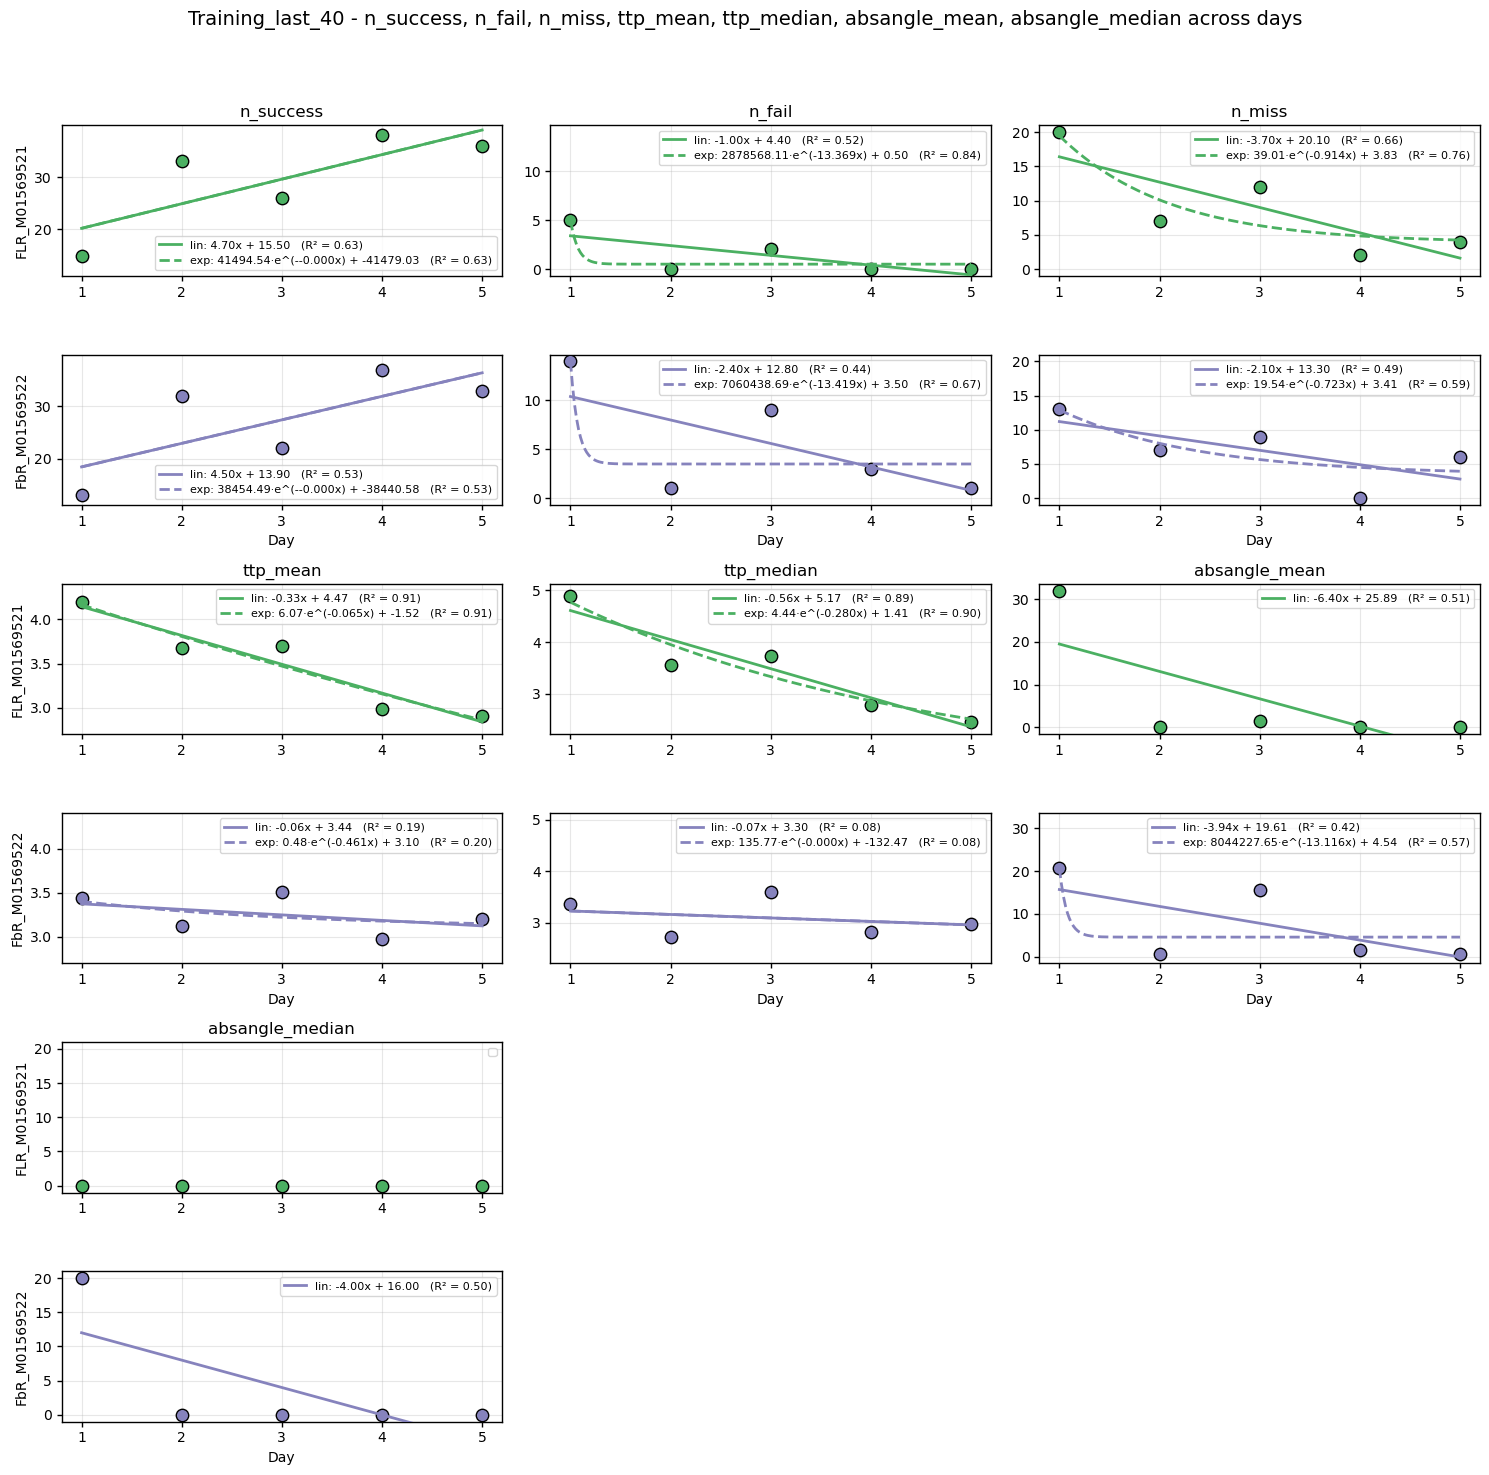

(<Figure size 1500x1500 with 18 Axes>,
 array([[<Axes: title={'center': 'n_success'}, ylabel='FLR_M01569521'>,
         <Axes: title={'center': 'n_fail'}>,
         <Axes: title={'center': 'n_miss'}>],
        [<Axes: xlabel='Day', ylabel='FbR_M01569522'>,
         <Axes: xlabel='Day'>, <Axes: xlabel='Day'>],
        [<Axes: title={'center': 'ttp_mean'}, ylabel='FLR_M01569521'>,
         <Axes: title={'center': 'ttp_median'}>,
         <Axes: title={'center': 'absangle_mean'}>],
        [<Axes: xlabel='Day', ylabel='FbR_M01569522'>,
         <Axes: xlabel='Day'>, <Axes: xlabel='Day'>],
        [<Axes: title={'center': 'absangle_median'}, ylabel='FLR_M01569521'>,
         <Axes: >, <Axes: >],
        [<Axes: xlabel='Day', ylabel='FbR_M01569522'>, <Axes: >, <Axes: >]],
       dtype=object))

In [14]:
# Compute the summary table first, then plot any of its columns over days.
summary_table, _, _ = summarise_dataset(training_dfs["last_40"], display_figure=False)
plot_summary_over_days(summary_table,
                       columns = ["n_success", "n_fail", "n_miss",
                                  "ttp_mean", "ttp_median",
                                  "absangle_mean", "absangle_median"],
                       dataset_name = "Training_last_40",
                       )


## Iteration Through All Desired Datasets
-----------------------------------------

### Iterator Loop

In [15]:
#==== Figure-suite helpers for ordered dataset iteration ======================================

def dataset_name_from_dataframe(dataset_df: pd.DataFrame) -> str:
    """
    Build the standard dataset name used in figure titles and filenames.

    The processed trial tables carry this information in two columns:
        - "training/testing": usually "training" or "testing"
        - "filter_profile": e.g. "all_trials", "last_40", "last_25", "first_40"

    Returns examples like:
        - "Training_all_trials"
        - "Testing_last_40"
        - "Testing_first_25"
    """
    if dataset_df is None or dataset_df.empty:
        raise ValueError("dataset_df must be a non-empty dataframe.")

    train_test = dataset_df["training/testing"].iloc[0]
    profile = dataset_df["filter_profile"].iloc[0]
    return f"{train_test.capitalize()}_{profile}"



def plot_sfm_panels_for_dataset(dataset_df: pd.DataFrame,
                                dataset_name: Optional[str] = None,
                                save_path: Optional[Path] = FIGURE_DIR,
                                mouse_IDs: Optional[list] = mouse_IDs,
                                mouse_colours: Optional[dict] = mouse_colours,
                                days_to_plot: Optional[list] = None,
                                save_figures: bool = SAVE_FIGURES,
                                append_date: bool = APPEND_DATE,
                                display_figure: bool = DISPLAY_FIGURES,
                                fig_format: str = FIG_FORMAT,
                                dpi: int = DPI,
                                figsize: tuple = (18, 6),
                                point_size: float = 45,
                                display_summary_statistics: bool = False,
):
    """
    Plot Success, Miss, and Failure rates as one three-panel figure.

    This function deliberately reuses `plot_sfm_figure` rather than duplicating
    its rate/regression code. It creates the three subplot axes here, then calls
    `plot_sfm_figure` once per outcome while passing the target axis through
    `ax=...`.

    Saving is handled once at the combined-figure level. That means each dataset
    produces one SFM SVG instead of three separate Success/Miss/Failure SVGs.

    Returns
    -------
    fig, axes
        The combined matplotlib Figure and its three Axes.
    """
    dataset_name = dataset_name or dataset_name_from_dataframe(dataset_df)
    sfm_outcomes = ("Success", "Miss", "Failure")

    fig, axes = plt.subplots(1, 3, figsize=figsize, sharey=True)

    for ax, outcome in zip(axes, sfm_outcomes):
        plot_sfm_figure(
            dataset_df=dataset_df,
            plot_outcome=outcome,
            save_path=None,                  # avoid separate single-outcome files
            mouse_IDs=mouse_IDs,
            mouse_colours=mouse_colours,
            days_to_plot=days_to_plot,
            title=f"{outcome} Rate",
            save_figures=False,              # combined figure is saved below
            append_date=append_date,
            display_figure=False,            # combined figure is displayed below
            fig_format=fig_format,
            dpi=dpi,
            figsize=figsize,
            point_size=point_size,
            display_summary_statistics=display_summary_statistics,
            ax=ax,
        )

    axes[0].set_ylabel("Outcome Rate")
    for ax in axes[1:]:
        ax.set_ylabel("")

    fig.suptitle(f"{dataset_name} - Success / Miss / Failure Rates Across Days")
    fig.tight_layout(rect=(0, 0, 1, 0.93))

    if save_figures and save_path is not None:
        stem = f"{dataset_name}_sfm_rate_subplots"
        if append_date:
            stem += f"_{pd.Timestamp.today().strftime('%Y-%m-%d')}"
        fig.savefig(Path(save_path) / f"{stem}.{fig_format}",
                    dpi=dpi, format=fig_format, bbox_inches="tight")

    if display_figure:
        plt.show()
    else:
        plt.close(fig)

    return fig, axes



def generate_figures_for_dataset(dataset_df: pd.DataFrame,
                                 dataset_name: Optional[str] = None,
                                 save_path: Optional[Path] = FIGURE_DIR,
                                 mouse_IDs: Optional[list] = mouse_IDs,
                                 mouse_colours: Optional[dict] = mouse_colours,
                                 mouse_cmaps: Optional[dict] = mouse_cmaps,
                                 days_to_plot: Optional[list] = None,
                                 save_figures: bool = SAVE_FIGURES,
                                 append_date: bool = APPEND_DATE,
                                 display_figure: bool = DISPLAY_FIGURES,
                                 fig_format: str = FIG_FORMAT,
                                 dpi: int = DPI,
                                 display_summary_statistics: bool = True,
                                 ttp_trial_filter: str = "no_miss",
                                 angle_trial_filter: str = "all",
                                 abs_angle_trial_filter: str = "all",
                                 abs_angle_fit_methods: tuple = ("linear", "exponential"),
):
    """
    Generate the standard figure set for one processed trial dataframe.

    This is the function to call inside the dataset loop. For each dataset, it
    creates the same outputs in the same order:
        1. Success/Miss/Failure rate panels
        2. Time-to-poke plot
        3. Signed angle-offset plot
        4. Absolute angle-offset plot with fitted trend lines
        5. Summary statistics table plus correlation heatmap

    Parameters
    ----------
    dataset_df : pd.DataFrame
        One processed dataset, for example `training_dfs["last_40"]`.
    dataset_name : str, optional
        Human-readable label for progress messages, titles, and the SFM filename.
        If omitted, it is inferred from the dataframe columns.
    days_to_plot : list, optional
        Restrict all plots to these day numbers. If None, every available day is used.
    display_summary_statistics : bool
        Whether each plotting function prints/displays its summary table. This is
        useful for inspection, but can make the notebook long during bulk runs.
    ttp_trial_filter, angle_trial_filter, abs_angle_trial_filter : str
        Trial filters forwarded to the corresponding plotting functions.

    Returns
    -------
    summary_table : pd.DataFrame
        The per-(mouse, day) summary table returned by `summarise_dataset`.
        The outer loop stores these in `summary_tables` for later inspection.
    """
    dataset_name = dataset_name or dataset_name_from_dataframe(dataset_df)
    print(f"\n========== {dataset_name} ==========")

    plot_sfm_panels_for_dataset(
        dataset_df=dataset_df,
        dataset_name=dataset_name,
        save_path=save_path,
        mouse_IDs=mouse_IDs,
        mouse_colours=mouse_colours,
        days_to_plot=days_to_plot,
        save_figures=save_figures,
        append_date=append_date,
        display_figure=display_figure,
        fig_format=fig_format,
        dpi=dpi,
        figsize=(18, 6),
        point_size=45,
        display_summary_statistics=False,
    )

    plot_ttp_figure(
        dataset_df=dataset_df,
        trial_filter=ttp_trial_filter,          # "all" | "no_miss" | "success_only"
        save_path=save_path,
        mouse_IDs=mouse_IDs,
        mouse_colours=mouse_colours,
        days_to_plot=days_to_plot,
        title=None,
        save_figures=save_figures,
        append_date=append_date,
        display_figure=display_figure,
        fig_format=fig_format,
        dpi=dpi,
        figsize=(18, 12),
        point_size=14,
        mean_size=90,
        jitter_width=0.4,
        y_min=0.0,
        y_max_floor=6.0,
        display_summary_statistics=display_summary_statistics,
    )

    plot_angle_offset_figure(
        dataset_df=dataset_df,
        trial_filter=angle_trial_filter,        # "all" | "no_miss" | "no_success" | "success_only"
        save_path=save_path,
        mouse_IDs=mouse_IDs,
        mouse_colours=mouse_colours,
        mouse_cmaps=mouse_cmaps,
        days_to_plot=days_to_plot,
        title=None,
        save_figures=save_figures,
        append_date=append_date,
        display_figure=display_figure,
        fig_format=fig_format,
        dpi=dpi,
        figsize=(14, 14),
        point_size=14,
        jitter_width=0.0,
        y_limit=180.0,
        display_summary_statistics=display_summary_statistics,
    )

    plot_abs_angle_offset_figure(
        dataset_df=dataset_df,
        trial_filter=abs_angle_trial_filter,    # "all" | "no_miss" | "no_success" | "success_only"
        save_path=save_path,
        mouse_IDs=mouse_IDs,
        mouse_colours=mouse_colours,
        mouse_cmaps=mouse_cmaps,
        days_to_plot=days_to_plot,
        title=None,
        save_figures=save_figures,
        append_date=append_date,
        display_figure=display_figure,
        fig_format=fig_format,
        dpi=dpi,
        figsize=(14, 6),
        point_size=14,
        jitter_width=0.4,
        y_limit=180.0,
        fit_methods=abs_angle_fit_methods,
        display_summary_statistics=display_summary_statistics,
    )

    summary_table, _, _ = summarise_dataset(
        dataset_df=dataset_df,
        mouse_IDs=mouse_IDs,
        days_to_plot=days_to_plot,
        save_path=save_path,
        title=None,
        save_figures=save_figures,
        append_date=append_date,
        display_figure=display_figure,
        fig_format=fig_format,
        dpi=dpi,
        figsize=(12, 5),
        display_summary_statistics=display_summary_statistics,
    )

    return summary_table



========== Training_all_trials ==========


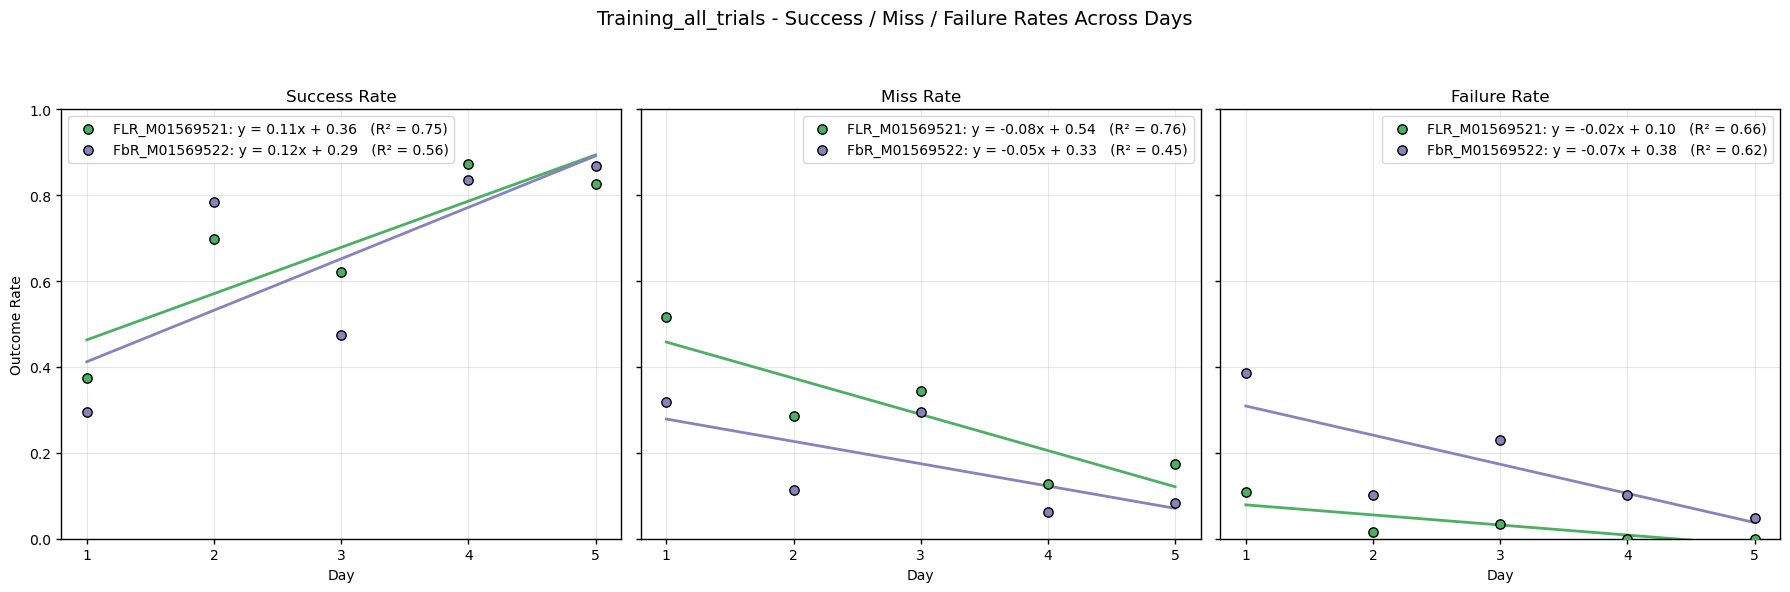

=== Summary statistics: Training_all_trials (trial_filter='no_miss') ===


/tmp/ipykernel_2892238/969829571.py:91: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_all_trials["rank_norm"] = df_all_trials.groupby("session", group_keys=False).apply(_rank_norm)


n_trials  n_success  n_fail  n_miss   mean     sd  \
day_num mouseID                                                            
1       FLR_M01569521        64         24       7      33  3.162  0.962   
        FbR_M01569522        44         13      17      14  2.692  1.000   
2       FLR_M01569521        63         44       1      18  3.375  0.782   
        FbR_M01569522        88         69       9      10  2.685  0.833   
3       FLR_M01569521        58         36       2      20  3.239  0.875   
        FbR_M01569522        61         29      14      18  3.053  0.955   
4       FLR_M01569521       109         95       0      14  2.974  0.878   
        FbR_M01569522        79         66       8       5  3.039  0.954   
5       FLR_M01569521       104         86       0      18  2.792  0.833   
        FbR_M01569522        84         73       4       7  3.014  0.723   

                       median    min    max  
day_num mouseID                              
1       FLR_M01569521   3.181  1.637  4.761  
        FbR_M01569522   2.520  1.186  4.561  
2       FLR_M01569521   3.395  1.771  4.986  
        FbR_M01569522   2.456  1.052  4.819  
3       FLR_M01569521   3.402  1.606  4.529  
        FbR_M01569522   3.035  1.436  4.961  
4       FLR_M01569521   2.818  1.520  5.007  
        FbR_M01569522   2.894  1.105  5.005  
5       FLR_M01569521   2.564  1.270  4.815  
        FbR_M01569522   2.971  1.725  4.707

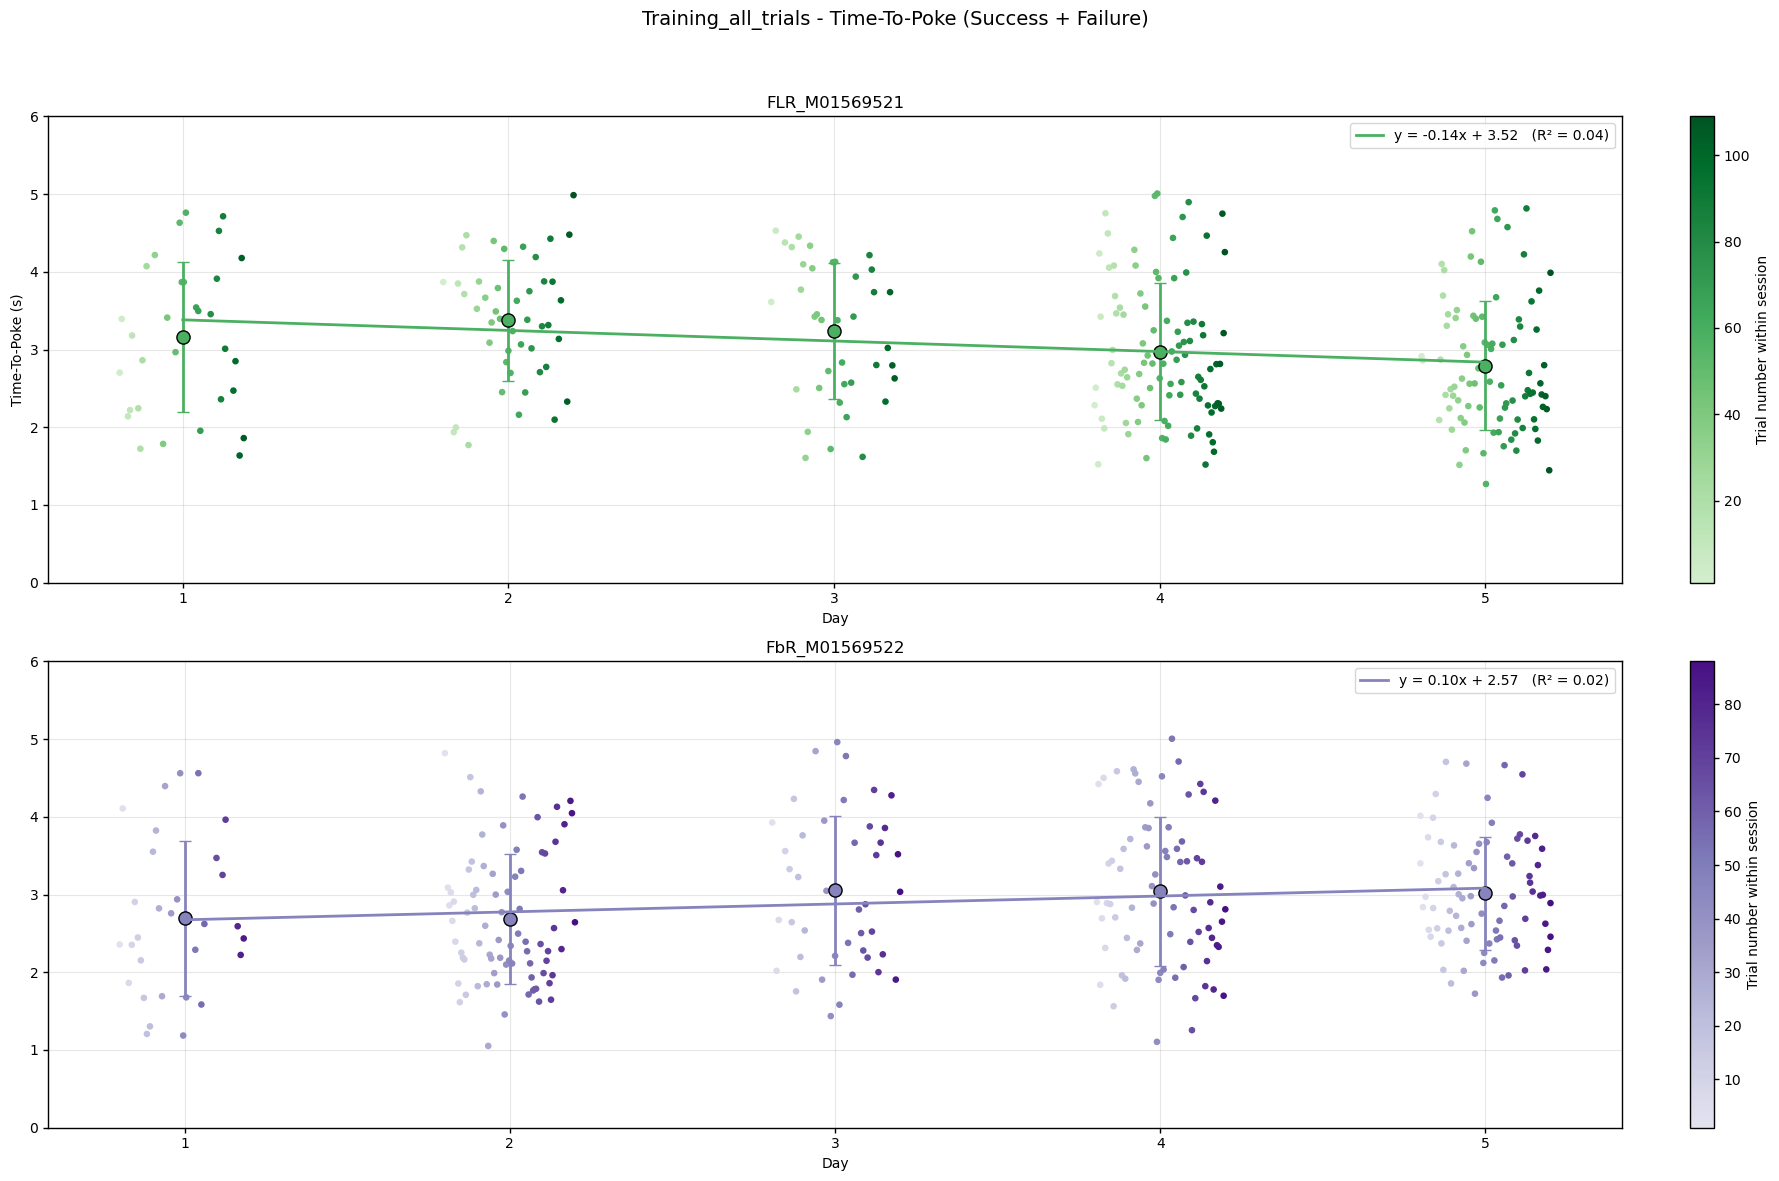

=== Summary statistics: Training_all_trials (trial_filter='all') ===


/tmp/ipykernel_2892238/3405151723.py:59: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_all_trials["rank_norm"] = df_all_trials.groupby("session", group_keys=False).apply(_rank_norm)


n_trials  n_success  n_fail  n_miss  n_angle    mean  \
day_num mouseID                                                               
1       FLR_M01569521        64         24       7      33       31   9.677   
        FbR_M01569522        44         13      17      14       30 -23.333   
2       FLR_M01569521        63         44       1      18       45  -1.333   
        FbR_M01569522        88         69       9      10       78  -4.615   
3       FLR_M01569521        58         36       2      20       38   1.053   
        FbR_M01569522        61         29      14      18       43  -6.512   
4       FLR_M01569521       109         95       0      14       95   0.000   
        FbR_M01569522        79         66       8       5       74   2.432   
5       FLR_M01569521       104         86       0      18       86   0.000   
        FbR_M01569522        84         73       4       7       77   0.779   

                           sd  median    min    max  n_pos  n_neg  
day_num mouseID                                                    
1       FLR_M01569521  71.156     0.0 -180.0  160.0      4      3  
        FbR_M01569522  37.905     0.0 -120.0   20.0      3     14  
2       FLR_M01569521   8.944     0.0  -60.0    0.0      0      1  
        FbR_M01569522  31.896     0.0 -180.0  160.0      1      8  
3       FLR_M01569521   4.526     0.0    0.0   20.0      2      0  
        FbR_M01569522  49.899     0.0 -160.0  100.0      8      6  
4       FLR_M01569521   0.000     0.0    0.0    0.0      0      0  
        FbR_M01569522   9.905     0.0  -20.0   60.0      7      1  
5       FLR_M01569521   0.000     0.0    0.0    0.0      0      0  
        FbR_M01569522   9.969     0.0  -20.0   80.0      2      2

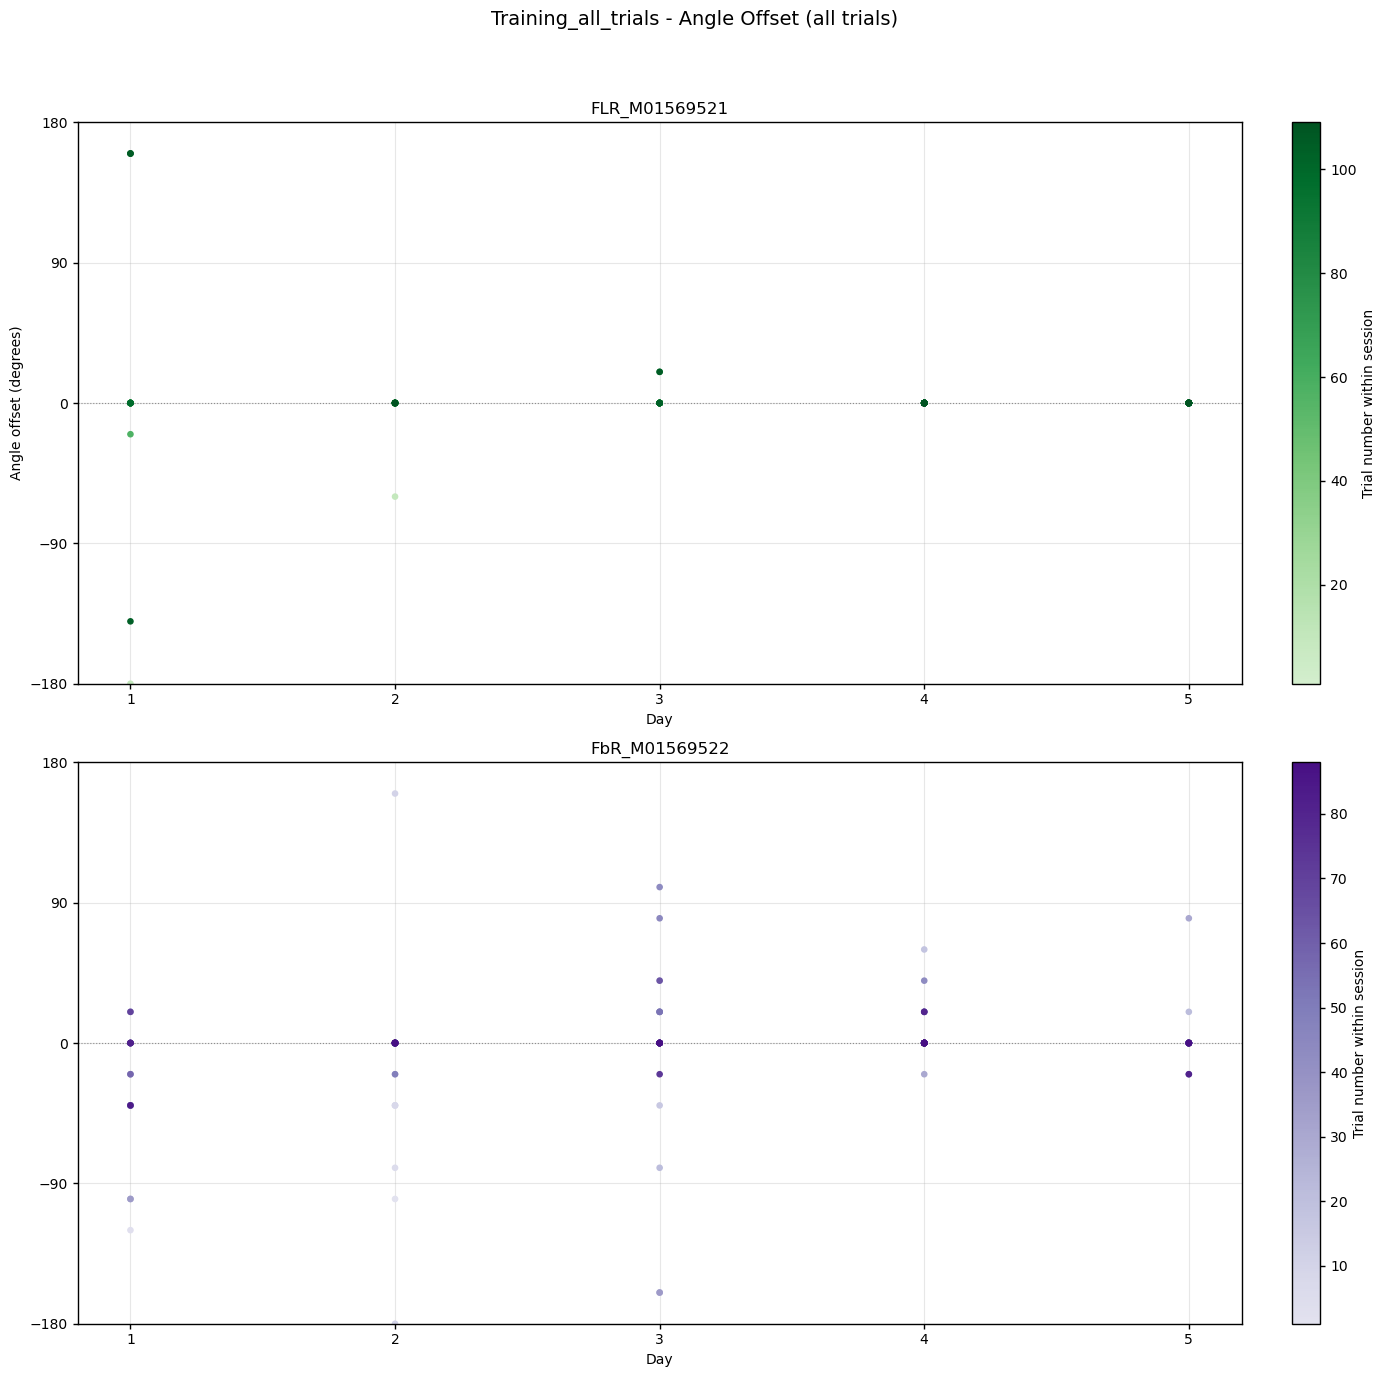

=== Summary statistics: Training_all_trials (trial_filter='all') ===


/tmp/ipykernel_2892238/338652183.py:59: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_all_trials["rank_norm"] = df_all_trials.groupby("session", group_keys=False).apply(_rank_norm)


n_trials  n_success  n_fail  n_miss  n_angle    mean  \
day_num mouseID                                                               
1       FLR_M01569521        64         24       7      33       31  31.613   
        FbR_M01569522        44         13      17      14       30  27.333   
2       FLR_M01569521        63         44       1      18       45   1.333   
        FbR_M01569522        88         69       9      10       78   8.718   
3       FLR_M01569521        58         36       2      20       38   1.053   
        FbR_M01569522        61         29      14      18       43  22.326   
4       FLR_M01569521       109         95       0      14       95   0.000   
        FbR_M01569522        79         66       8       5       74   2.973   
5       FLR_M01569521       104         86       0      18       86   0.000   
        FbR_M01569522        84         73       4       7       77   1.818   

                           sd  median  min    max  
day_num mouseID                                    
1       FLR_M01569521  64.244     0.0  0.0  180.0  
        FbR_M01569522  35.030    20.0  0.0  120.0  
2       FLR_M01569521   8.944     0.0  0.0   60.0  
        FbR_M01569522  31.016     0.0  0.0  180.0  
3       FLR_M01569521   4.526     0.0  0.0   20.0  
        FbR_M01569522  44.978     0.0  0.0  160.0  
4       FLR_M01569521   0.000     0.0  0.0    0.0  
        FbR_M01569522   9.754     0.0  0.0   60.0  
5       FLR_M01569521   0.000     0.0  0.0    0.0  
        FbR_M01569522   9.831     0.0  0.0   80.0

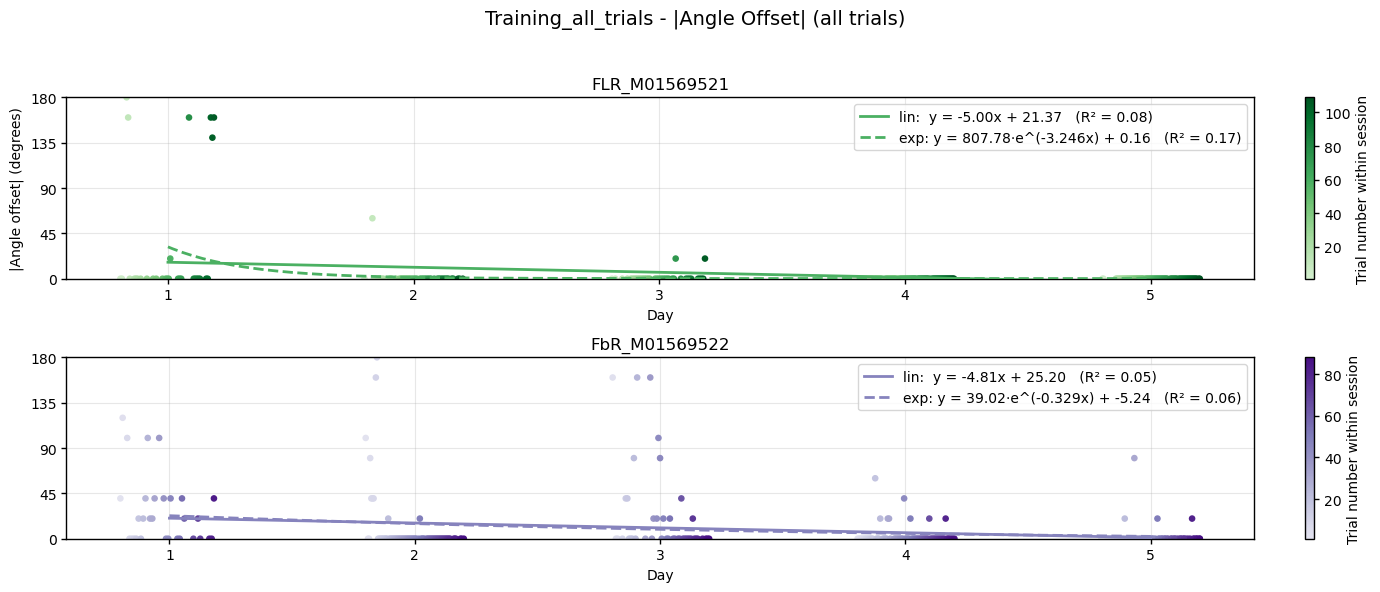

=== Per-(mouse, day) summary: Training_all_trials ===


n_trials  n_success  n_fail  n_miss  ttp_n  ttp_mean  \
day_num mouseID                                                               
1       FLR_M01569521        64         24       7      33     64     4.118   
        FbR_M01569522        44         13      17      14     44     3.430   
2       FLR_M01569521        63         44       1      18     63     3.845   
        FbR_M01569522        88         69       9      10     88     2.951   
3       FLR_M01569521        58         36       2      20     58     3.851   
        FbR_M01569522        61         29      14      18     61     3.632   
4       FLR_M01569521       109         95       0      14    109     3.236   
        FbR_M01569522        79         66       8       5     79     3.164   
5       FLR_M01569521       104         86       0      18    104     3.178   
        FbR_M01569522        84         73       4       7     84     3.181   

                       ttp_sd  ttp_median  ttp_min  ttp_max  absangle_n  \
day_num mouseID                                                           
1       FLR_M01569521   1.146       5.012    1.637    5.022          31   
        FbR_M01569522   1.367       3.361    1.186    5.017          30   
2       FLR_M01569521   0.997       3.849    1.771    5.026          45   
        FbR_M01569522   1.081       2.714    1.052    5.023          78   
3       FLR_M01569521   1.105       4.071    1.606    5.015          38   
        FbR_M01569522   1.205       3.667    1.436    5.030          43   
4       FLR_M01569521   1.069       2.975    1.520    5.032          95   
        FbR_M01569522   1.041       2.989    1.105    5.014          74   
5       FLR_M01569521   1.136       2.892    1.270    5.029          86   
        FbR_M01569522   0.888       2.991    1.725    5.024          77   

                       absangle_mean  absangle_sd  absangle_median  \
day_num mouseID                                                      
1       FLR_M01569521         31.613       64.244              0.0   
        FbR_M01569522         27.333       35.030             20.0   
2       FLR_M01569521          1.333        8.944              0.0   
        FbR_M01569522          8.718       31.016              0.0   
3       FLR_M01569521          1.053        4.526              0.0   
        FbR_M01569522         22.326       44.978              0.0   
4       FLR_M01569521          0.000        0.000              0.0   
        FbR_M01569522          2.973        9.754              0.0   
5       FLR_M01569521          0.000        0.000              0.0   
        FbR_M01569522          1.818        9.831              0.0   

                       absangle_min  absangle_max zone_sizes  
day_num mouseID                                               
1       FLR_M01569521           0.0         180.0        150  
        FbR_M01569522           0.0         120.0        150  
2       FLR_M01569521           0.0          60.0        150  
        FbR_M01569522           0.0         180.0        150  
3       FLR_M01569521           0.0          20.0        150  
        FbR_M01569522           0.0         160.0        150  
4       FLR_M01569521           0.0           0.0        150  
        FbR_M01569522           0.0          60.0        150  
5       FLR_M01569521           0.0           0.0        150  
        FbR_M01569522           0.0          80.0        150

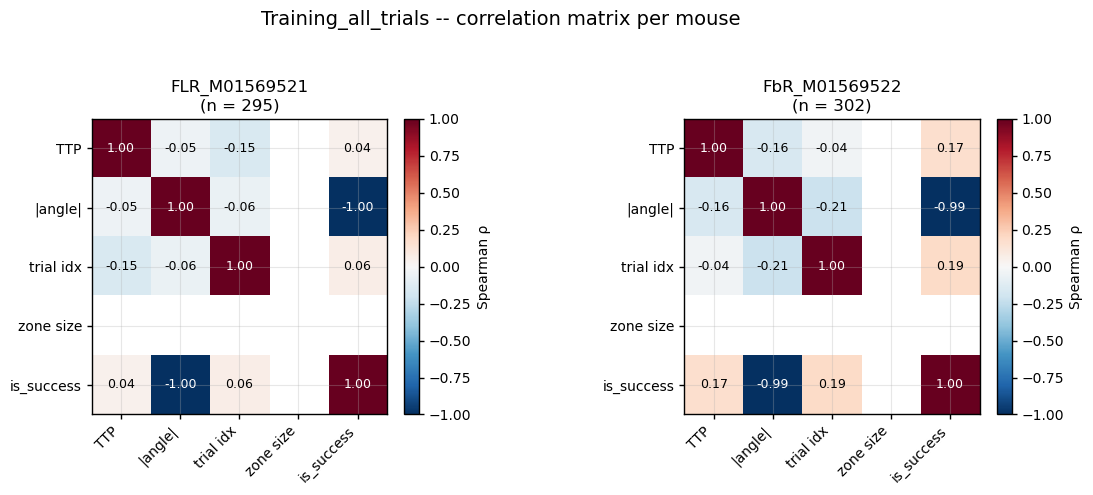


========== Testing_all_trials ==========


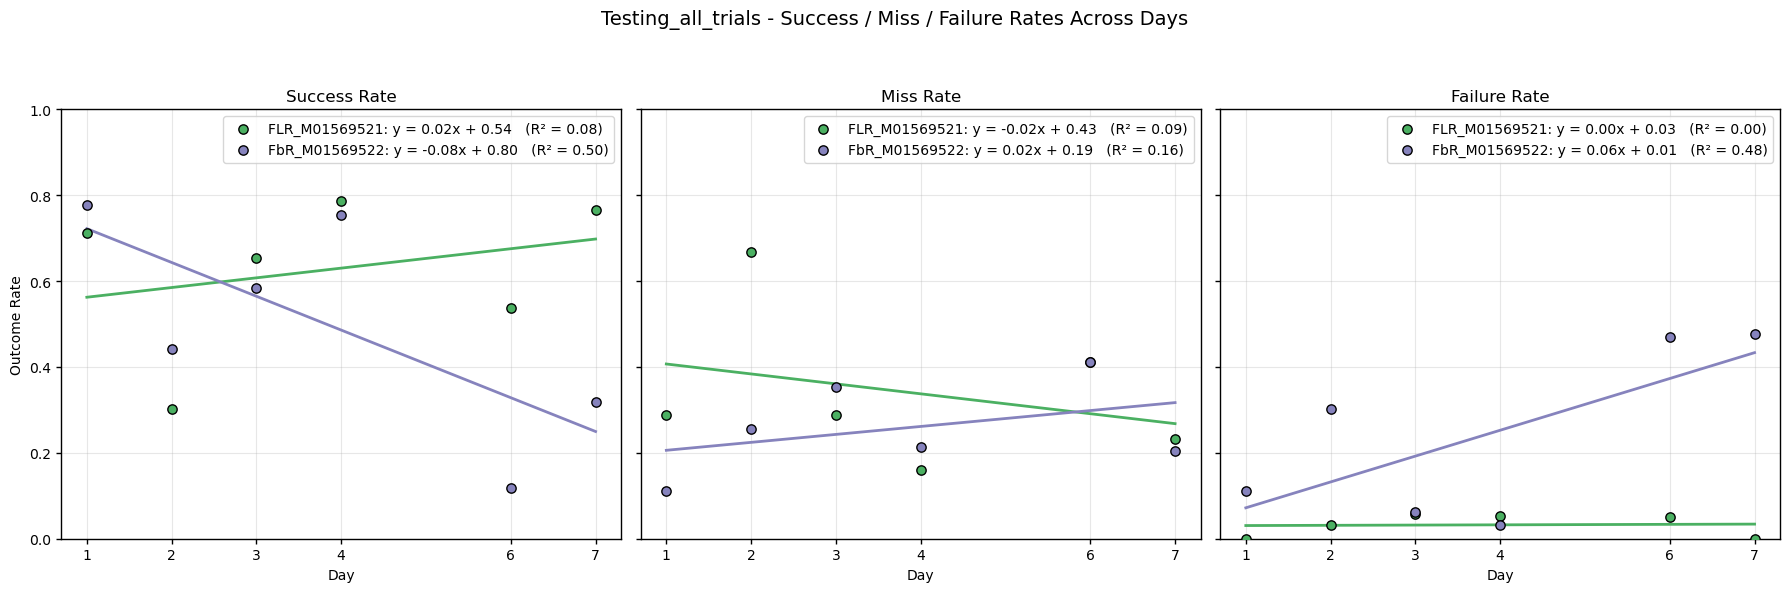

=== Summary statistics: Testing_all_trials (trial_filter='no_miss') ===


/tmp/ipykernel_2892238/969829571.py:91: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_all_trials["rank_norm"] = df_all_trials.groupby("session", group_keys=False).apply(_rank_norm)


n_trials  n_success  n_fail  n_miss   mean     sd  \
day_num mouseID                                                            
1       FLR_M01569521        59         42       0      17  2.753  0.665   
        FbR_M01569522        27         21       3       3  2.654  0.921   
2       FLR_M01569521        96         29       3      64  3.271  0.921   
        FbR_M01569522        43         19      13      11  2.728  1.084   
3       FLR_M01569521        52         34       3      15  3.324  1.052   
        FbR_M01569522        65         38       4      23  3.031  0.912   
4       FLR_M01569521        94         74       5      15  2.698  0.800   
        FbR_M01569522        61         46       2      13  2.883  0.968   
6       FLR_M01569521       136         73       7      56  3.150  0.964   
        FbR_M01569522        34          4      16      14  3.024  1.097   
7       FLR_M01569521        90         69       0      21  2.900  0.783   
        FbR_M01569522        44         14      21       9  2.839  0.743   

                       median    min    max  
day_num mouseID                              
1       FLR_M01569521   2.715  1.634  4.304  
        FbR_M01569522   2.459  0.876  4.647  
2       FLR_M01569521   3.022  1.706  4.998  
        FbR_M01569522   2.514  0.946  4.955  
3       FLR_M01569521   3.330  1.483  5.010  
        FbR_M01569522   2.928  1.504  4.834  
4       FLR_M01569521   2.605  1.173  4.885  
        FbR_M01569522   2.645  1.043  4.640  
6       FLR_M01569521   3.211  1.081  5.012  
        FbR_M01569522   2.887  1.174  4.823  
7       FLR_M01569521   2.738  1.277  4.901  
        FbR_M01569522   2.922  1.554  4.638

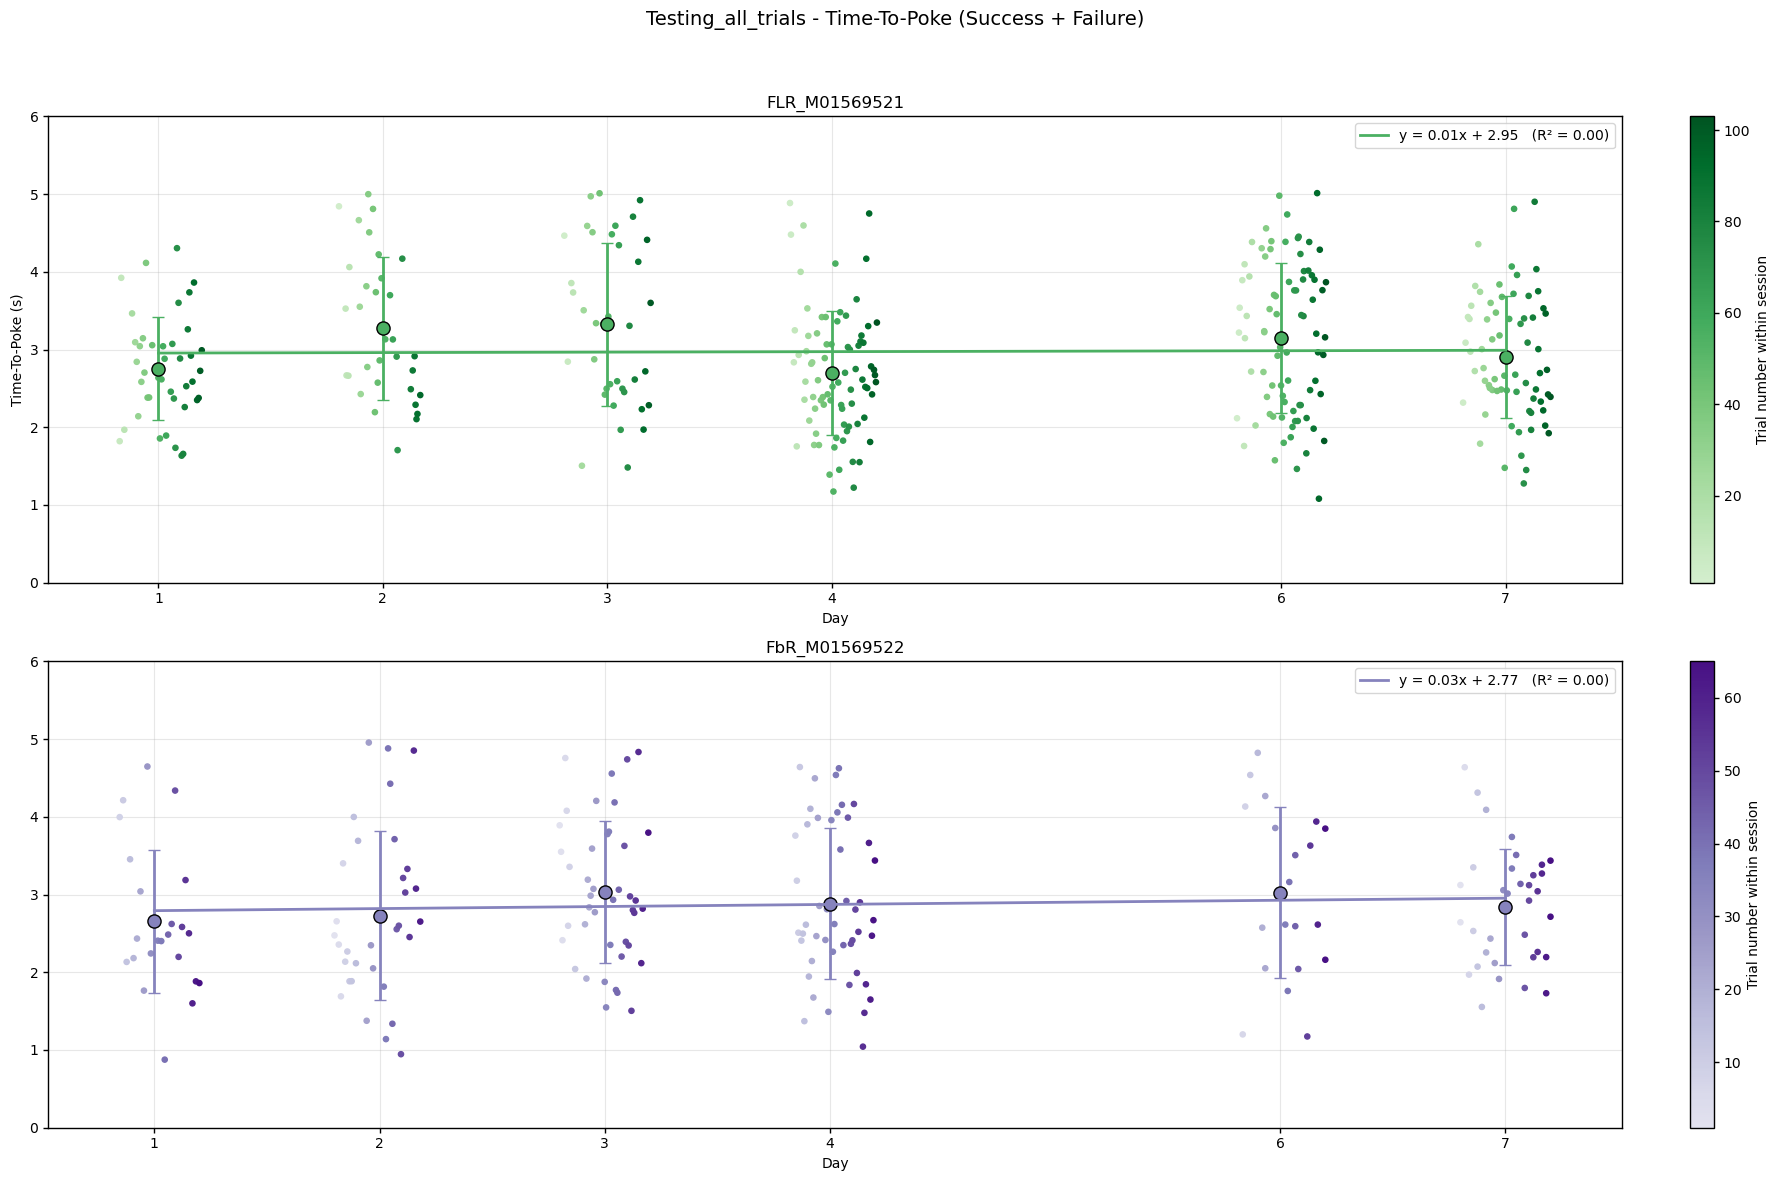

=== Summary statistics: Testing_all_trials (trial_filter='all') ===


/tmp/ipykernel_2892238/3405151723.py:59: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_all_trials["rank_norm"] = df_all_trials.groupby("session", group_keys=False).apply(_rank_norm)


n_trials  n_success  n_fail  n_miss  n_angle    mean  \
day_num mouseID                                                               
1       FLR_M01569521        59         42       0      17       42   0.000   
        FbR_M01569522        27         21       3       3       24   2.500   
2       FLR_M01569521        96         29       3      64       32   4.375   
        FbR_M01569522        43         19      13      11       32  -3.125   
3       FLR_M01569521        52         34       3      15       37  -2.162   
        FbR_M01569522        65         38       4      23       42  -1.905   
4       FLR_M01569521        94         74       5      15       79   1.519   
        FbR_M01569522        61         46       2      13       48   0.000   
6       FLR_M01569521       136         73       7      56       80  -4.250   
        FbR_M01569522        34          4      16      14       20  11.000   
7       FLR_M01569521        90         69       0      21       69   0.000   
        FbR_M01569522        44         14      21       9       35  -7.429   

                           sd  median    min    max  n_pos  n_neg  
day_num mouseID                                                    
1       FLR_M01569521   0.000     0.0    0.0    0.0      0      0  
        FbR_M01569522   6.757     0.0    0.0   20.0      3      0  
2       FLR_M01569521  15.013     0.0    0.0   60.0      3      0  
        FbR_M01569522  45.183     0.0 -180.0   40.0     11      2  
3       FLR_M01569521  27.802     0.0 -120.0  100.0      1      2  
        FbR_M01569522  29.569     0.0 -180.0   40.0      3      1  
4       FLR_M01569521   8.928     0.0  -20.0   60.0      4      1  
        FbR_M01569522   4.126     0.0  -20.0   20.0      1      1  
6       FLR_M01569521  26.945     0.0 -120.0  120.0      1      6  
        FbR_M01569522  76.907     0.0 -120.0  140.0      9      7  
7       FLR_M01569521   0.000     0.0    0.0    0.0      0      0  
        FbR_M01569522  57.820     0.0 -180.0   80.0     15      6

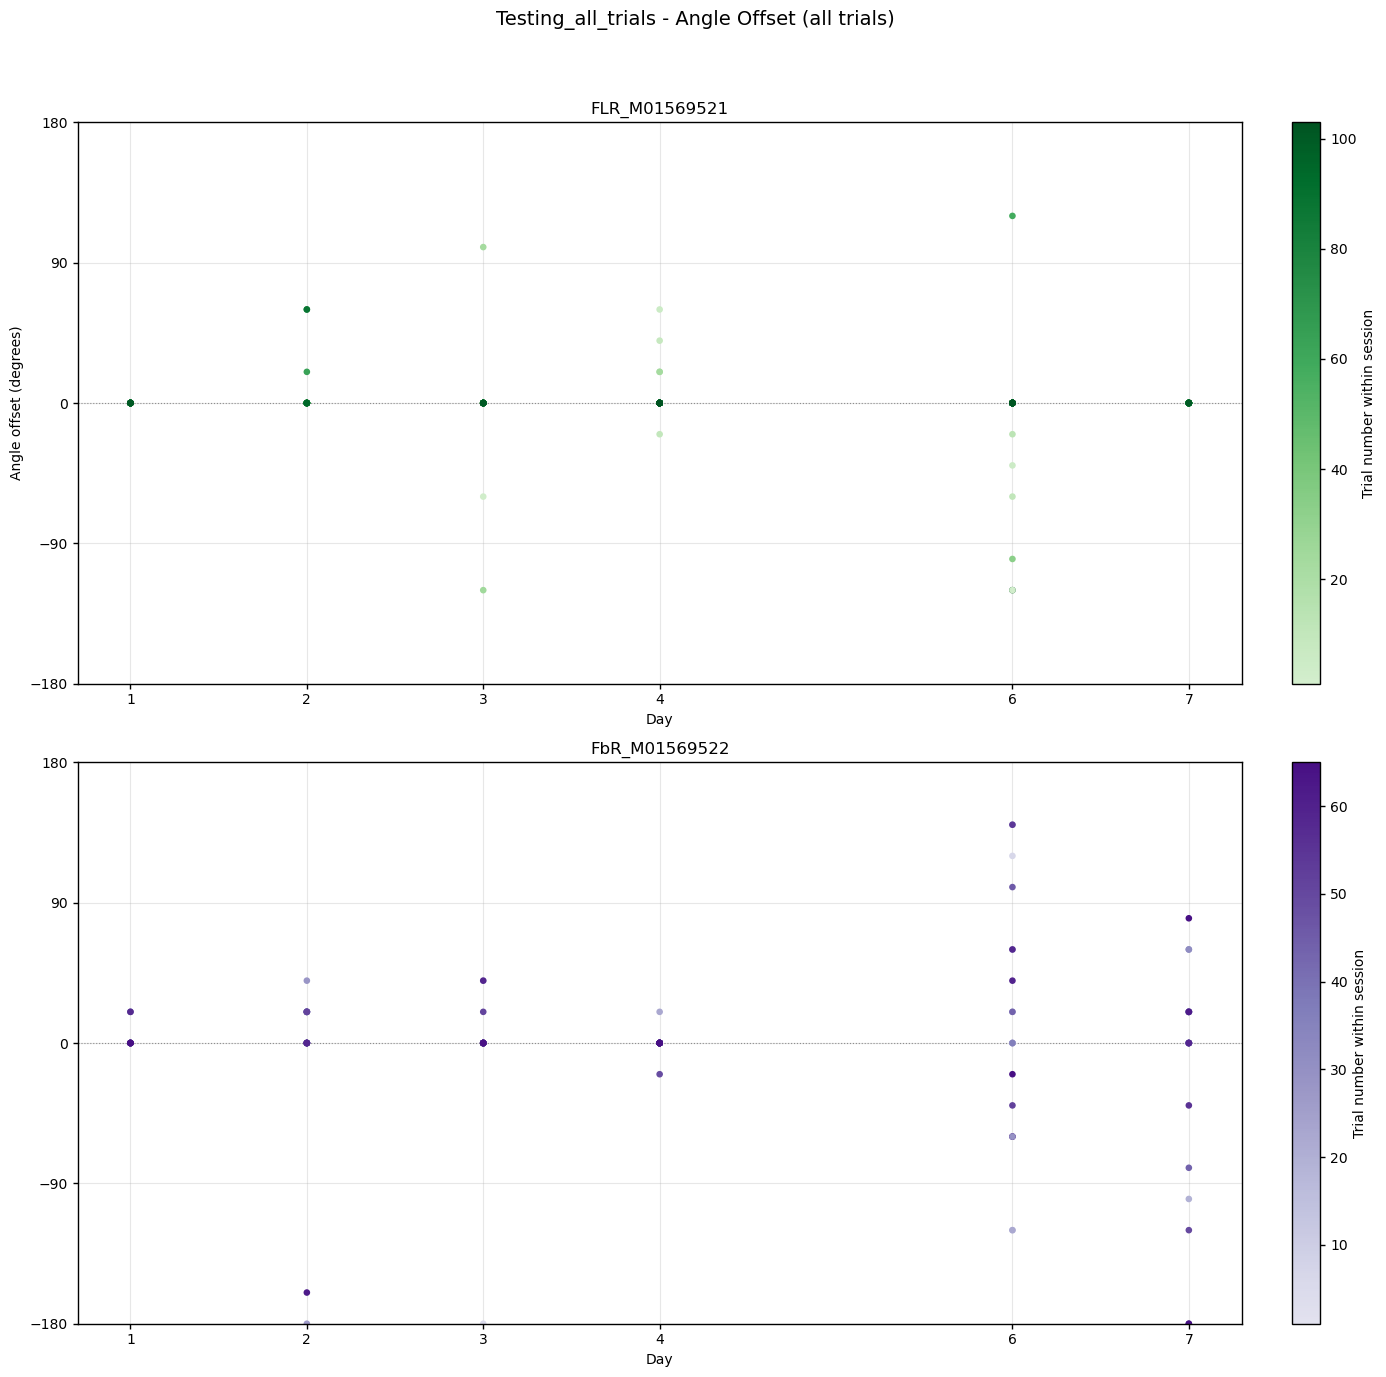

=== Summary statistics: Testing_all_trials (trial_filter='all') ===


/tmp/ipykernel_2892238/338652183.py:59: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_all_trials["rank_norm"] = df_all_trials.groupby("session", group_keys=False).apply(_rank_norm)


n_trials  n_success  n_fail  n_miss  n_angle    mean  \
day_num mouseID                                                               
1       FLR_M01569521        59         42       0      17       42   0.000   
        FbR_M01569522        27         21       3       3       24   2.500   
2       FLR_M01569521        96         29       3      64       32   4.375   
        FbR_M01569522        43         19      13      11       32  18.125   
3       FLR_M01569521        52         34       3      15       37   7.568   
        FbR_M01569522        65         38       4      23       42   6.667   
4       FLR_M01569521        94         74       5      15       79   2.025   
        FbR_M01569522        61         46       2      13       48   0.833   
6       FLR_M01569521       136         73       7      56       80   7.250   
        FbR_M01569522        34          4      16      14       20  59.000   
7       FLR_M01569521        90         69       0      21       69   0.000   
        FbR_M01569522        44         14      21       9       35  32.571   

                           sd  median  min    max  
day_num mouseID                                    
1       FLR_M01569521   0.000     0.0  0.0    0.0  
        FbR_M01569522   6.757     0.0  0.0   20.0  
2       FLR_M01569521  15.013     0.0  0.0   60.0  
        FbR_M01569522  41.382     0.0  0.0  180.0  
3       FLR_M01569521  26.813     0.0  0.0  120.0  
        FbR_M01569522  28.853     0.0  0.0  180.0  
4       FLR_M01569521   8.826     0.0  0.0   60.0  
        FbR_M01569522   4.039     0.0  0.0   20.0  
6       FLR_M01569521  26.288     0.0  0.0  120.0  
        FbR_M01569522  48.764    60.0  0.0  140.0  
7       FLR_M01569521   0.000     0.0  0.0    0.0  
        FbR_M01569522  48.041    20.0  0.0  180.0

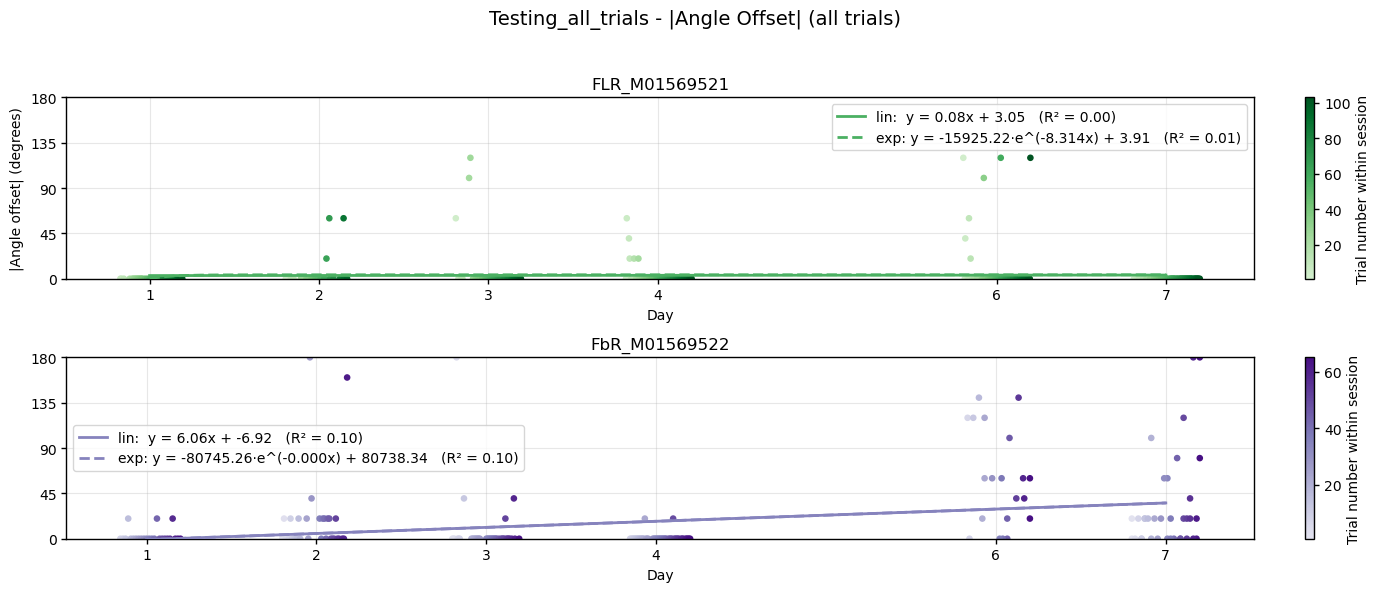

=== Per-(mouse, day) summary: Testing_all_trials ===


n_trials  n_success  n_fail  n_miss  ttp_n  ttp_mean  \
day_num mouseID                                                               
1       FLR_M01569521        59         42       0      17     59     3.406   
        FbR_M01569522        27         21       3       3     27     2.917   
2       FLR_M01569521        96         29       3      64     96     4.433   
        FbR_M01569522        43         19      13      11     43     3.314   
3       FLR_M01569521        52         34       3      15     52     3.812   
        FbR_M01569522        65         38       4      23     65     3.733   
4       FLR_M01569521        94         74       5      15     94     3.068   
        FbR_M01569522        61         46       2      13     61     3.337   
6       FLR_M01569521       136         73       7      56    136     3.918   
        FbR_M01569522        34          4      16      14     34     3.844   
7       FLR_M01569521        90         69       0      21     90     3.395   
        FbR_M01569522        44         14      21       9     44     3.285   

                       ttp_sd  ttp_median  ttp_min  ttp_max  absangle_n  \
day_num mouseID                                                           
1       FLR_M01569521   1.176       3.043    1.634    5.027          42   
        FbR_M01569522   1.151       2.501    0.876    5.024          24   
2       FLR_M01569521   0.979       5.011    1.706    5.026          32   
        FbR_M01569522   1.374       3.076    0.946    5.029          32   
3       FLR_M01569521   1.175       4.236    1.483    5.030          37   
        FbR_M01569522   1.203       3.796    1.504    5.021          42   
4       FLR_M01569521   1.125       2.826    1.173    5.022          79   
        FbR_M01569522   1.227       2.917    1.043    5.016          48   
6       FLR_M01569521   1.180       4.288    1.081    5.031          80   
        FbR_M01569522   1.297       4.200    1.174    5.021          20   
7       FLR_M01569521   1.132       3.359    1.277    5.084          69   
        FbR_M01569522   1.107       3.121    1.554    5.024          35   

                       absangle_mean  absangle_sd  absangle_median  \
day_num mouseID                                                      
1       FLR_M01569521          0.000        0.000              0.0   
        FbR_M01569522          2.500        6.757              0.0   
2       FLR_M01569521          4.375       15.013              0.0   
        FbR_M01569522         18.125       41.382              0.0   
3       FLR_M01569521          7.568       26.813              0.0   
        FbR_M01569522          6.667       28.853              0.0   
4       FLR_M01569521          2.025        8.826              0.0   
        FbR_M01569522          0.833        4.039              0.0   
6       FLR_M01569521          7.250       26.288              0.0   
        FbR_M01569522         59.000       48.764             60.0   
7       FLR_M01569521          0.000        0.000              0.0   
        FbR_M01569522         32.571       48.041             20.0   

                       absangle_min  absangle_max zone_sizes  
day_num mouseID                                               
1       FLR_M01569521           0.0           0.0        150  
        FbR_M01569522           0.0          20.0        150  
2       FLR_M01569521           0.0          60.0        150  
        FbR_M01569522           0.0         180.0        150  
3       FLR_M01569521           0.0         120.0        150  
        FbR_M01569522           0.0         180.0        150  
4       FLR_M01569521           0.0          60.0        150  
        FbR_M01569522           0.0          20.0        150  
6       FLR_M01569521           0.0         120.0        150  
        FbR_M01569522           0.0         140.0        150  
7       FLR_M01569521           0.0           0.0   150, 400  
        FbR_M01569522           0.0         180.0        150

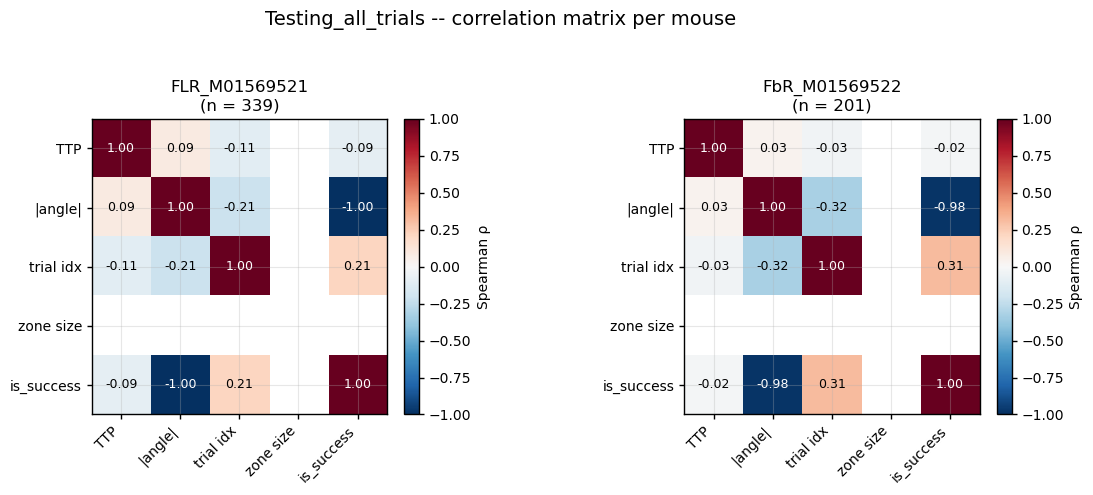


========== Training_last_40 ==========


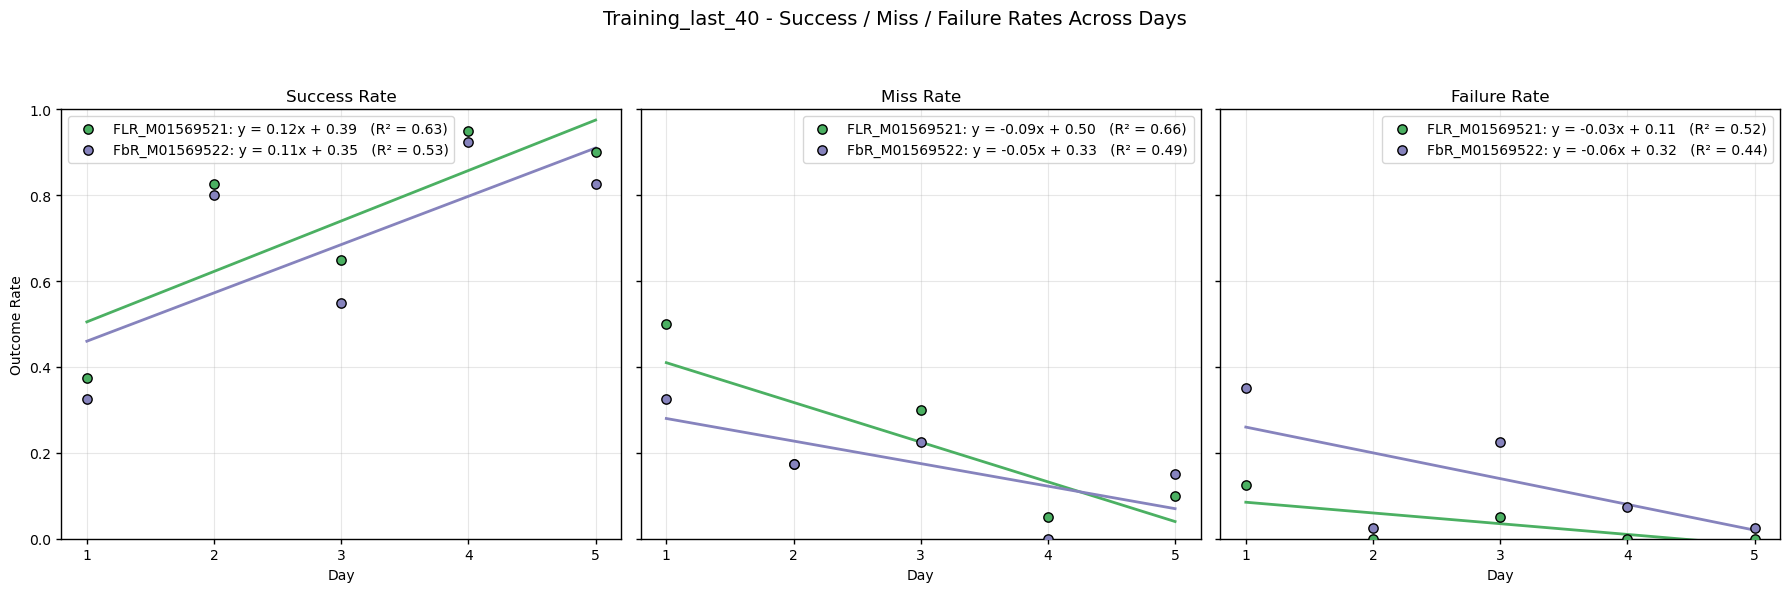

=== Summary statistics: Training_last_40 (trial_filter='no_miss') ===


/tmp/ipykernel_2892238/969829571.py:91: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_all_trials["rank_norm"] = df_all_trials.groupby("session", group_keys=False).apply(_rank_norm)


n_trials  n_success  n_fail  n_miss   mean     sd  \
day_num mouseID                                                            
1       FLR_M01569521        40         15       5      20  3.373  0.969   
        FbR_M01569522        40         13      14      13  2.683  1.004   
2       FLR_M01569521        40         33       0       7  3.389  0.734   
        FbR_M01569522        40         32       1       7  2.717  0.882   
3       FLR_M01569521        40         26       2      12  3.139  0.779   
        FbR_M01569522        40         22       9       9  3.078  1.020   
4       FLR_M01569521        40         38       0       2  2.875  0.871   
        FbR_M01569522        40         37       3       0  2.974  0.955   
5       FLR_M01569521        40         36       0       4  2.676  0.829   
        FbR_M01569522        40         33       1       6  2.880  0.612   

                       median    min    max  
day_num mouseID                              
1       FLR_M01569521   3.475  1.637  4.761  
        FbR_M01569522   2.592  1.186  4.561  
2       FLR_M01569521   3.348  2.098  4.986  
        FbR_M01569522   2.393  1.623  4.260  
3       FLR_M01569521   3.199  1.619  4.335  
        FbR_M01569522   3.035  1.436  4.961  
4       FLR_M01569521   2.699  1.520  4.896  
        FbR_M01569522   2.823  1.255  5.005  
5       FLR_M01569521   2.426  1.446  4.815  
        FbR_M01569522   2.872  1.725  4.244

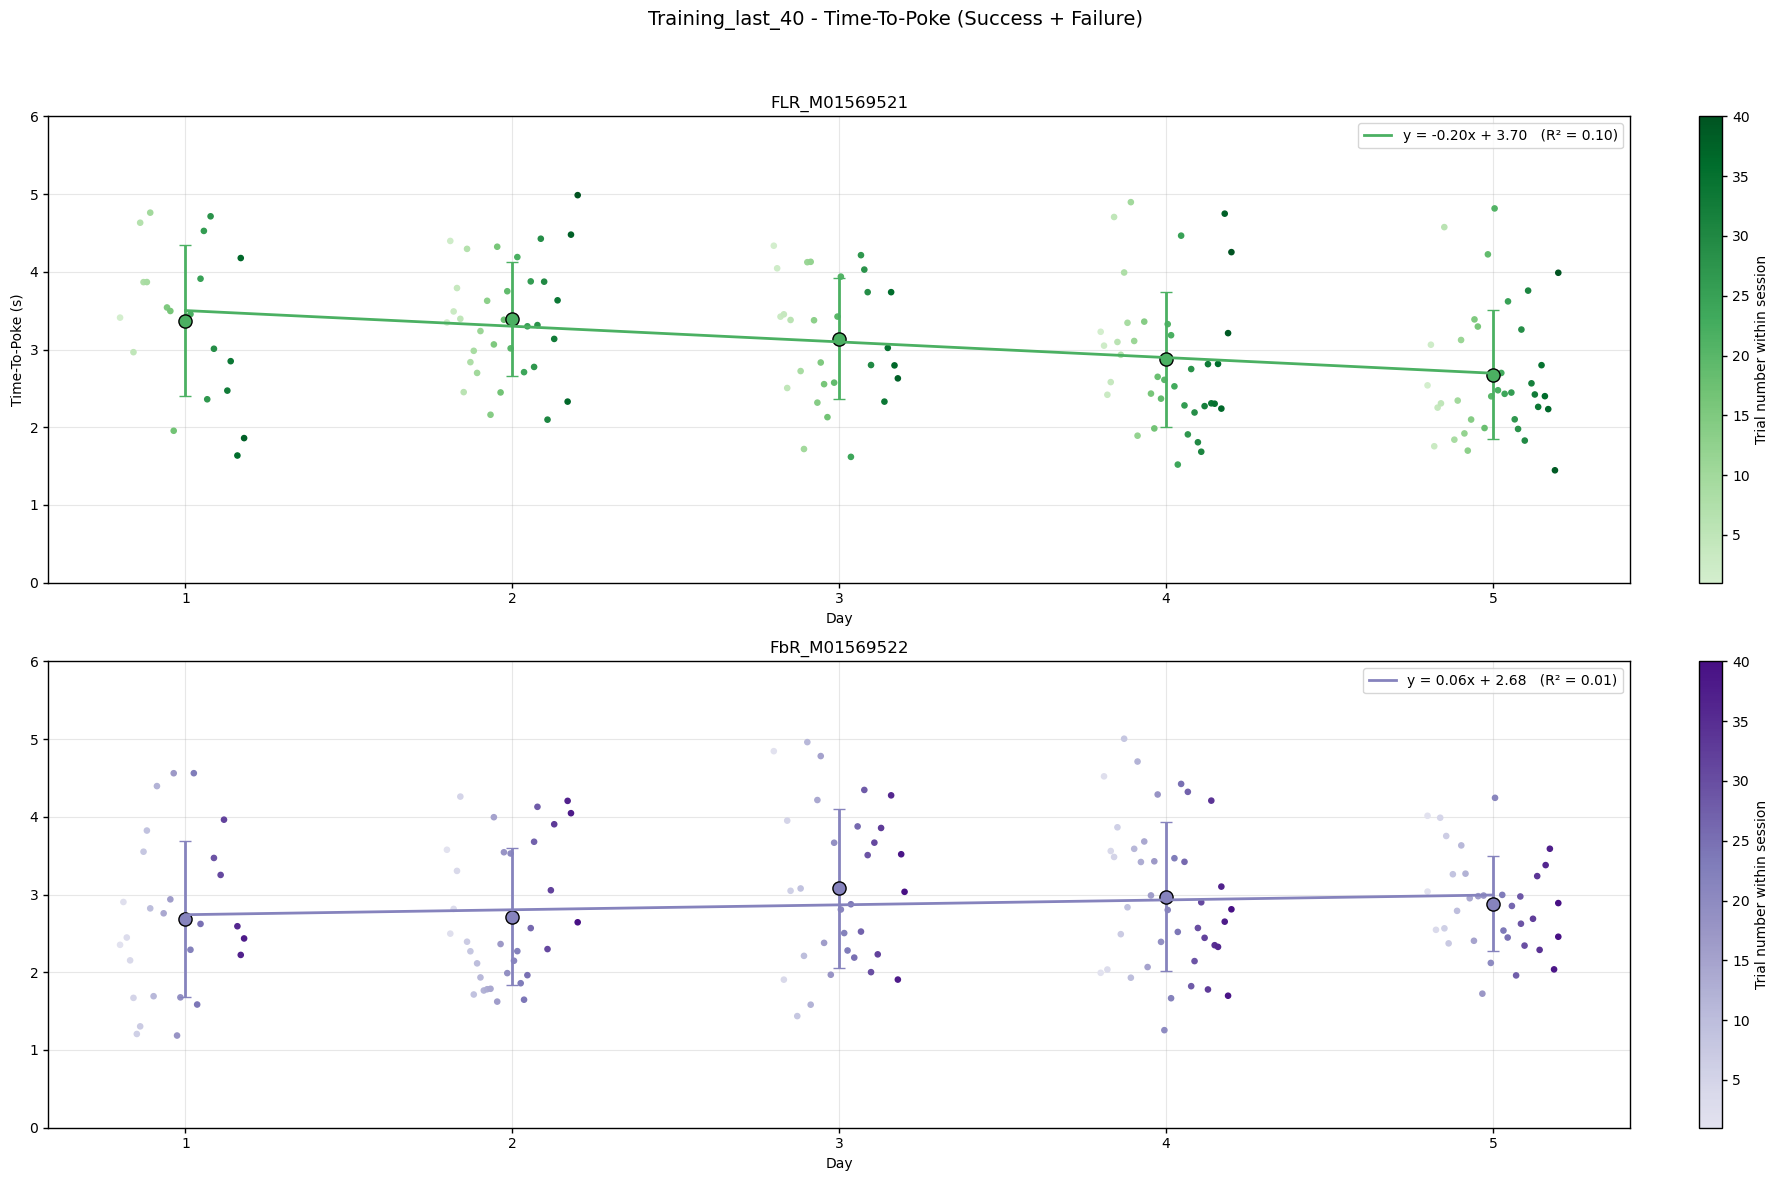

=== Summary statistics: Training_last_40 (trial_filter='all') ===


/tmp/ipykernel_2892238/3405151723.py:59: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_all_trials["rank_norm"] = df_all_trials.groupby("session", group_keys=False).apply(_rank_norm)


n_trials  n_success  n_fail  n_miss  n_angle    mean  \
day_num mouseID                                                               
1       FLR_M01569521        40         15       5      20       20  16.000   
        FbR_M01569522        40         13      14      13       27 -16.296   
2       FLR_M01569521        40         33       0       7       33   0.000   
        FbR_M01569522        40         32       1       7       33  -0.606   
3       FLR_M01569521        40         26       2      12       28   1.429   
        FbR_M01569522        40         22       9       9       31   3.871   
4       FLR_M01569521        40         38       0       2       38   0.000   
        FbR_M01569522        40         37       3       0       40   1.500   
5       FLR_M01569521        40         36       0       4       36   0.000   
        FbR_M01569522        40         33       1       6       34  -0.588   

                           sd  median    min    max  n_pos  n_neg  
day_num mouseID                                                    
1       FLR_M01569521  69.464     0.0 -140.0  160.0      3      2  
        FbR_M01569522  30.903     0.0 -100.0   20.0      3     11  
2       FLR_M01569521   0.000     0.0    0.0    0.0      0      0  
        FbR_M01569522   3.482     0.0  -20.0    0.0      0      1  
3       FLR_M01569521   5.245     0.0    0.0   20.0      2      0  
        FbR_M01569522  38.788     0.0 -160.0  100.0      7      2  
4       FLR_M01569521   0.000     0.0    0.0    0.0      0      0  
        FbR_M01569522   5.335     0.0    0.0   20.0      3      0  
5       FLR_M01569521   0.000     0.0    0.0    0.0      0      0  
        FbR_M01569522   3.430     0.0  -20.0    0.0      0      1

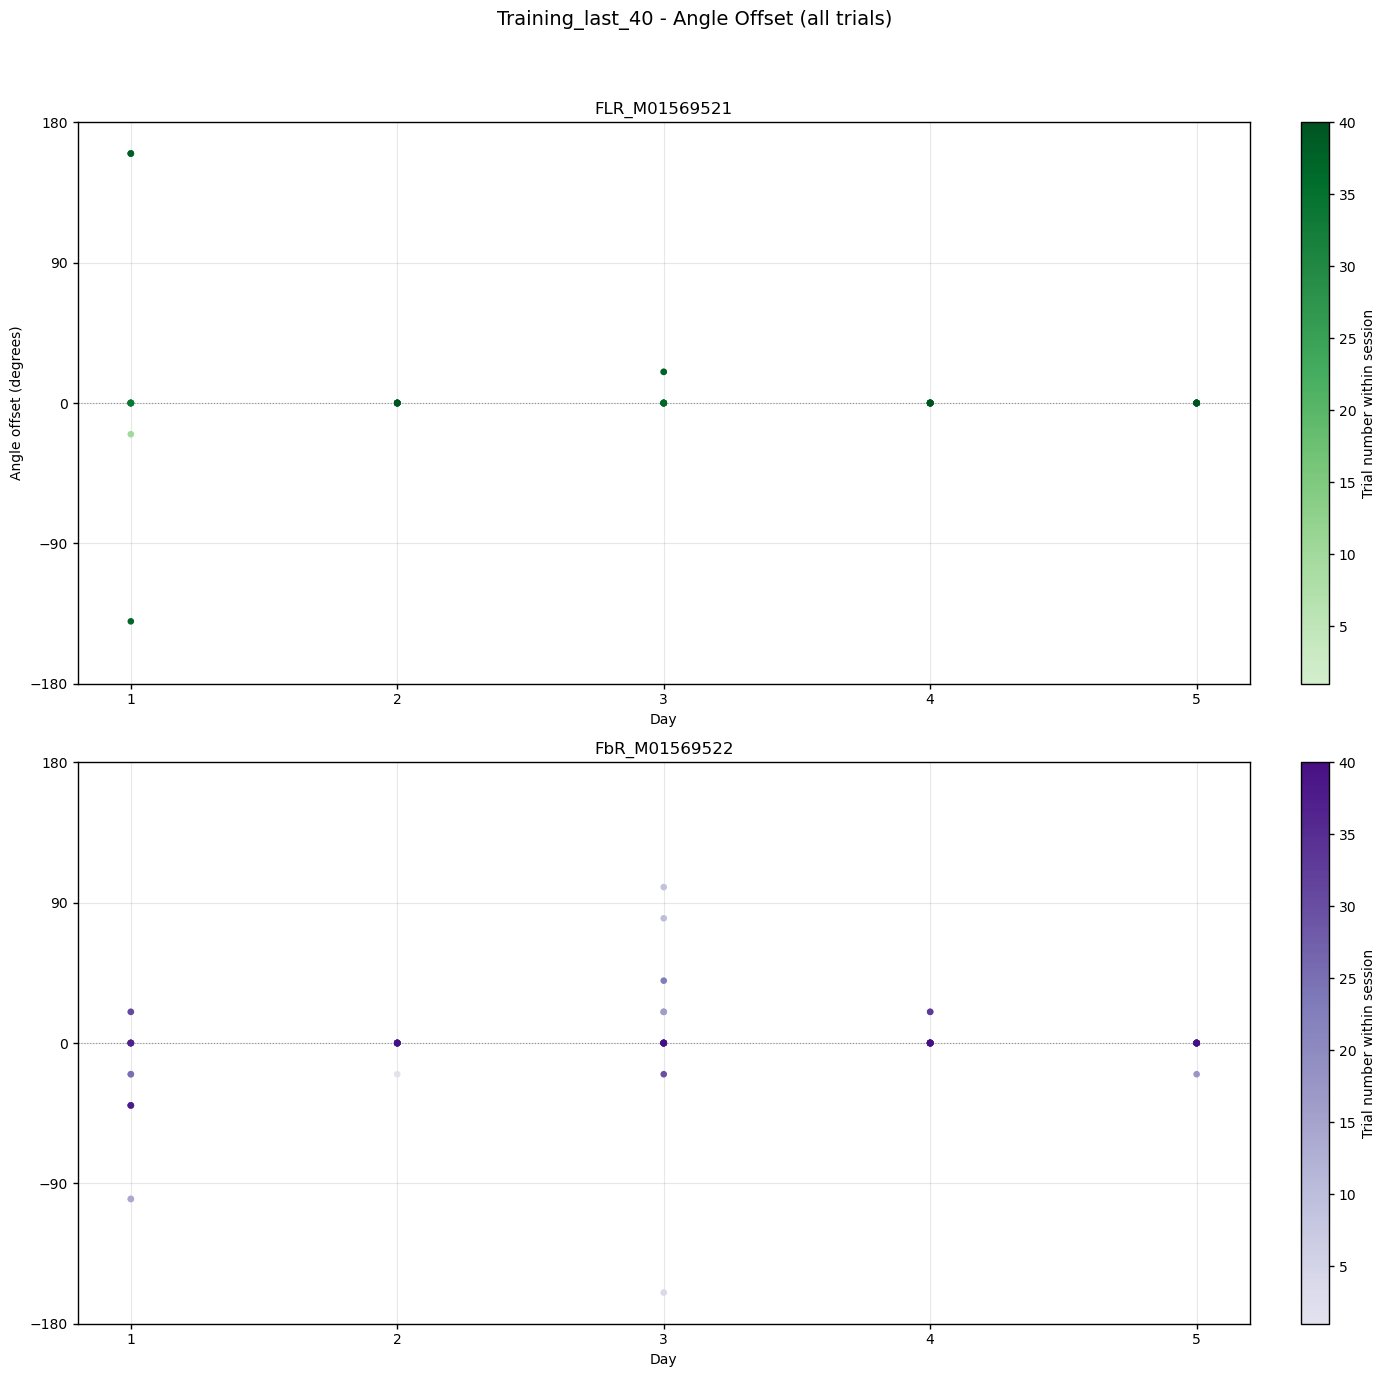

=== Summary statistics: Training_last_40 (trial_filter='all') ===


/tmp/ipykernel_2892238/338652183.py:59: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_all_trials["rank_norm"] = df_all_trials.groupby("session", group_keys=False).apply(_rank_norm)


n_trials  n_success  n_fail  n_miss  n_angle    mean  \
day_num mouseID                                                               
1       FLR_M01569521        40         15       5      20       20  32.000   
        FbR_M01569522        40         13      14      13       27  20.741   
2       FLR_M01569521        40         33       0       7       33   0.000   
        FbR_M01569522        40         32       1       7       33   0.606   
3       FLR_M01569521        40         26       2      12       28   1.429   
        FbR_M01569522        40         22       9       9       31  15.484   
4       FLR_M01569521        40         38       0       2       38   0.000   
        FbR_M01569522        40         37       3       0       40   1.500   
5       FLR_M01569521        40         36       0       4       36   0.000   
        FbR_M01569522        40         33       1       6       34   0.588   

                           sd  median  min    max  
day_num mouseID                                    
1       FLR_M01569521  63.379     0.0  0.0  160.0  
        FbR_M01569522  28.001    20.0  0.0  100.0  
2       FLR_M01569521   0.000     0.0  0.0    0.0  
        FbR_M01569522   3.482     0.0  0.0   20.0  
3       FLR_M01569521   5.245     0.0  0.0   20.0  
        FbR_M01569522  35.669     0.0  0.0  160.0  
4       FLR_M01569521   0.000     0.0  0.0    0.0  
        FbR_M01569522   5.335     0.0  0.0   20.0  
5       FLR_M01569521   0.000     0.0  0.0    0.0  
        FbR_M01569522   3.430     0.0  0.0   20.0

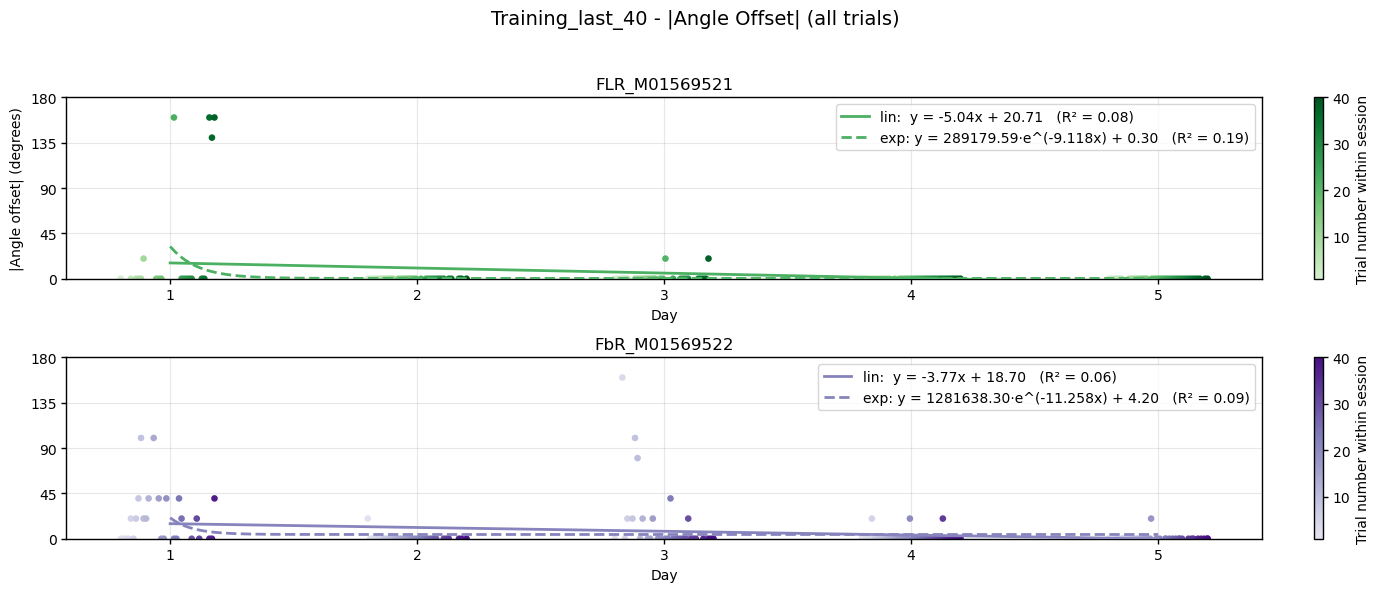

=== Per-(mouse, day) summary: Training_last_40 ===


n_trials  n_success  n_fail  n_miss  ttp_n  ttp_mean  \
day_num mouseID                                                               
1       FLR_M01569521        40         15       5      20     40     4.196   
        FbR_M01569522        40         13      14      13     40     3.440   
2       FLR_M01569521        40         33       0       7     40     3.674   
        FbR_M01569522        40         32       1       7     40     3.120   
3       FLR_M01569521        40         26       2      12     40     3.701   
        FbR_M01569522        40         22       9       9     40     3.514   
4       FLR_M01569521        40         38       0       2     40     2.983   
        FbR_M01569522        40         37       3       0     40     2.974   
5       FLR_M01569521        40         36       0       4     40     2.910   
        FbR_M01569522        40         33       1       6     40     3.201   

                       ttp_sd  ttp_median  ttp_min  ttp_max  absangle_n  \
day_num mouseID                                                           
1       FLR_M01569521   1.073       4.887    1.637    5.022          20   
        FbR_M01569522   1.375       3.361    1.186    5.017          27   
2       FLR_M01569521   0.914       3.559    2.098    5.026          33   
        FbR_M01569522   1.193       2.729    1.623    5.023          33   
3       FLR_M01569521   1.085       3.738    1.619    5.015          28   
        FbR_M01569522   1.212       3.592    1.436    5.029          31   
4       FLR_M01569521   0.973       2.781    1.520    5.032          38   
        FbR_M01569522   0.955       2.823    1.255    5.005          40   
5       FLR_M01569521   1.060       2.461    1.446    5.029          36   
        FbR_M01569522   0.955       2.977    1.725    5.020          34   

                       absangle_mean  absangle_sd  absangle_median  \
day_num mouseID                                                      
1       FLR_M01569521         32.000       63.379              0.0   
        FbR_M01569522         20.741       28.001             20.0   
2       FLR_M01569521          0.000        0.000              0.0   
        FbR_M01569522          0.606        3.482              0.0   
3       FLR_M01569521          1.429        5.245              0.0   
        FbR_M01569522         15.484       35.669              0.0   
4       FLR_M01569521          0.000        0.000              0.0   
        FbR_M01569522          1.500        5.335              0.0   
5       FLR_M01569521          0.000        0.000              0.0   
        FbR_M01569522          0.588        3.430              0.0   

                       absangle_min  absangle_max zone_sizes  
day_num mouseID                                               
1       FLR_M01569521           0.0         160.0        150  
        FbR_M01569522           0.0         100.0        150  
2       FLR_M01569521           0.0           0.0        150  
        FbR_M01569522           0.0          20.0        150  
3       FLR_M01569521           0.0          20.0        150  
        FbR_M01569522           0.0         160.0        150  
4       FLR_M01569521           0.0           0.0        150  
        FbR_M01569522           0.0          20.0        150  
5       FLR_M01569521           0.0           0.0        150  
        FbR_M01569522           0.0          20.0        150

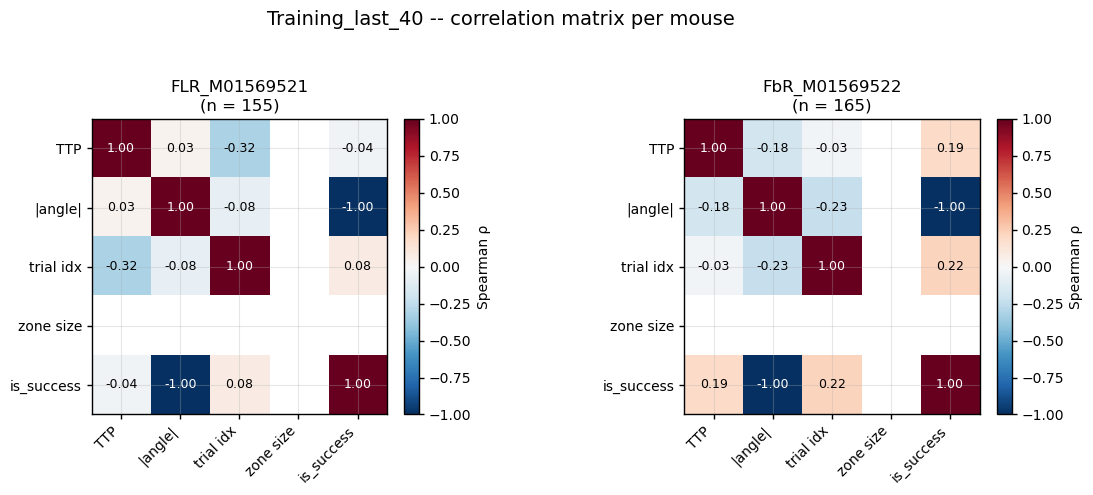


========== Testing_last_40 ==========


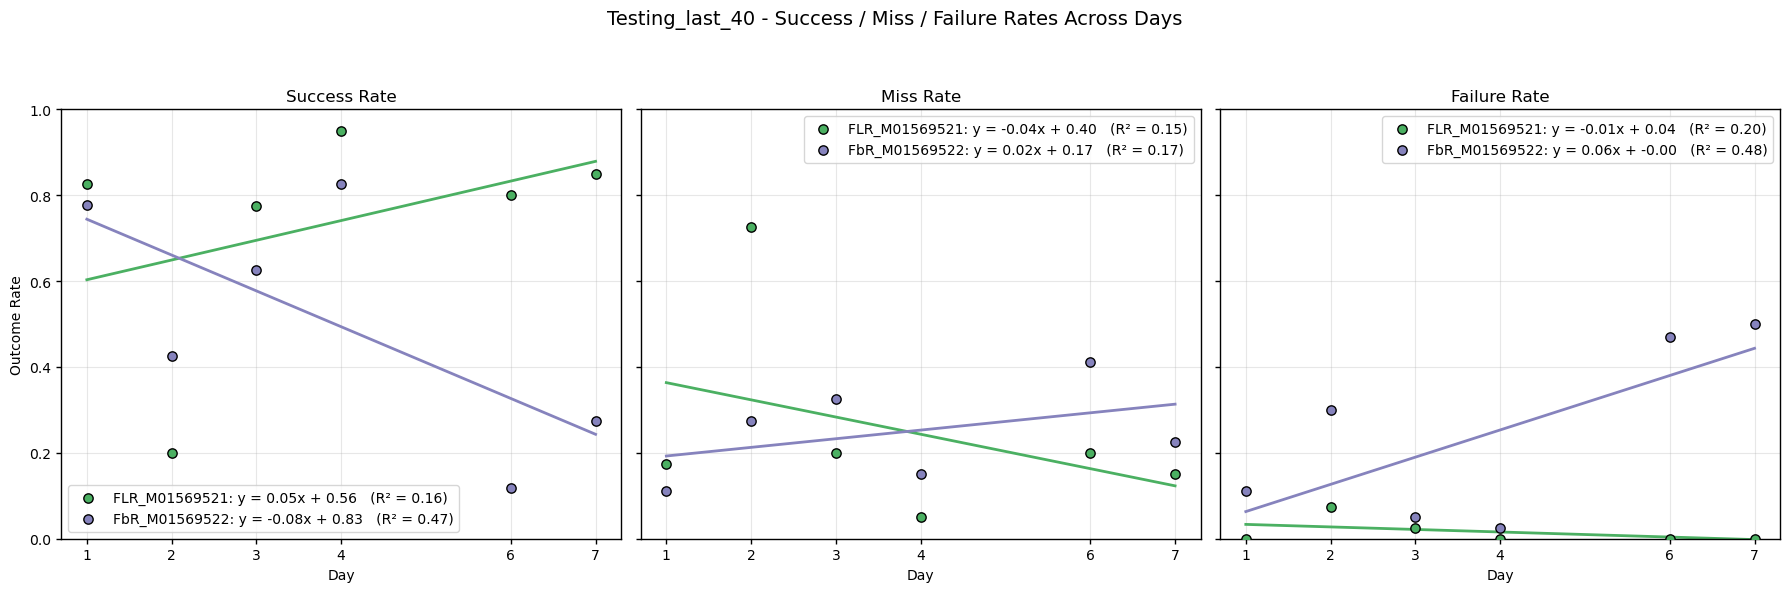

=== Summary statistics: Testing_last_40 (trial_filter='no_miss') ===


/tmp/ipykernel_2892238/969829571.py:91: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_all_trials["rank_norm"] = df_all_trials.groupby("session", group_keys=False).apply(_rank_norm)


n_trials  n_success  n_fail  n_miss   mean     sd  \
day_num mouseID                                                            
1       FLR_M01569521        40         33       0       7  2.750  0.666   
        FbR_M01569522        27         21       3       3  2.654  0.921   
2       FLR_M01569521        40          8       3      29  2.639  0.656   
        FbR_M01569522        40         17      12      11  2.752  1.137   
3       FLR_M01569521        40         31       1       8  3.331  1.056   
        FbR_M01569522        40         25       2      13  2.979  0.990   
4       FLR_M01569521        40         38       0       2  2.625  0.749   
        FbR_M01569522        40         33       1       6  2.857  0.940   
6       FLR_M01569521        40         32       0       8  3.106  1.011   
        FbR_M01569522        34          4      16      14  3.024  1.097   
7       FLR_M01569521        40         34       0       6  2.652  0.747   
        FbR_M01569522        40         11      20       9  2.799  0.693   

                       median    min    max  
day_num mouseID                              
1       FLR_M01569521   2.703  1.634  4.304  
        FbR_M01569522   2.459  0.876  4.647  
2       FLR_M01569521   2.490  1.706  4.169  
        FbR_M01569522   2.554  0.946  4.955  
3       FLR_M01569521   3.317  1.483  5.010  
        FbR_M01569522   2.818  1.504  4.834  
4       FLR_M01569521   2.597  1.223  4.750  
        FbR_M01569522   2.738  1.043  4.624  
6       FLR_M01569521   3.181  1.081  5.012  
        FbR_M01569522   2.887  1.174  4.823  
7       FLR_M01569521   2.481  1.277  4.810  
        FbR_M01569522   2.922  1.554  4.311

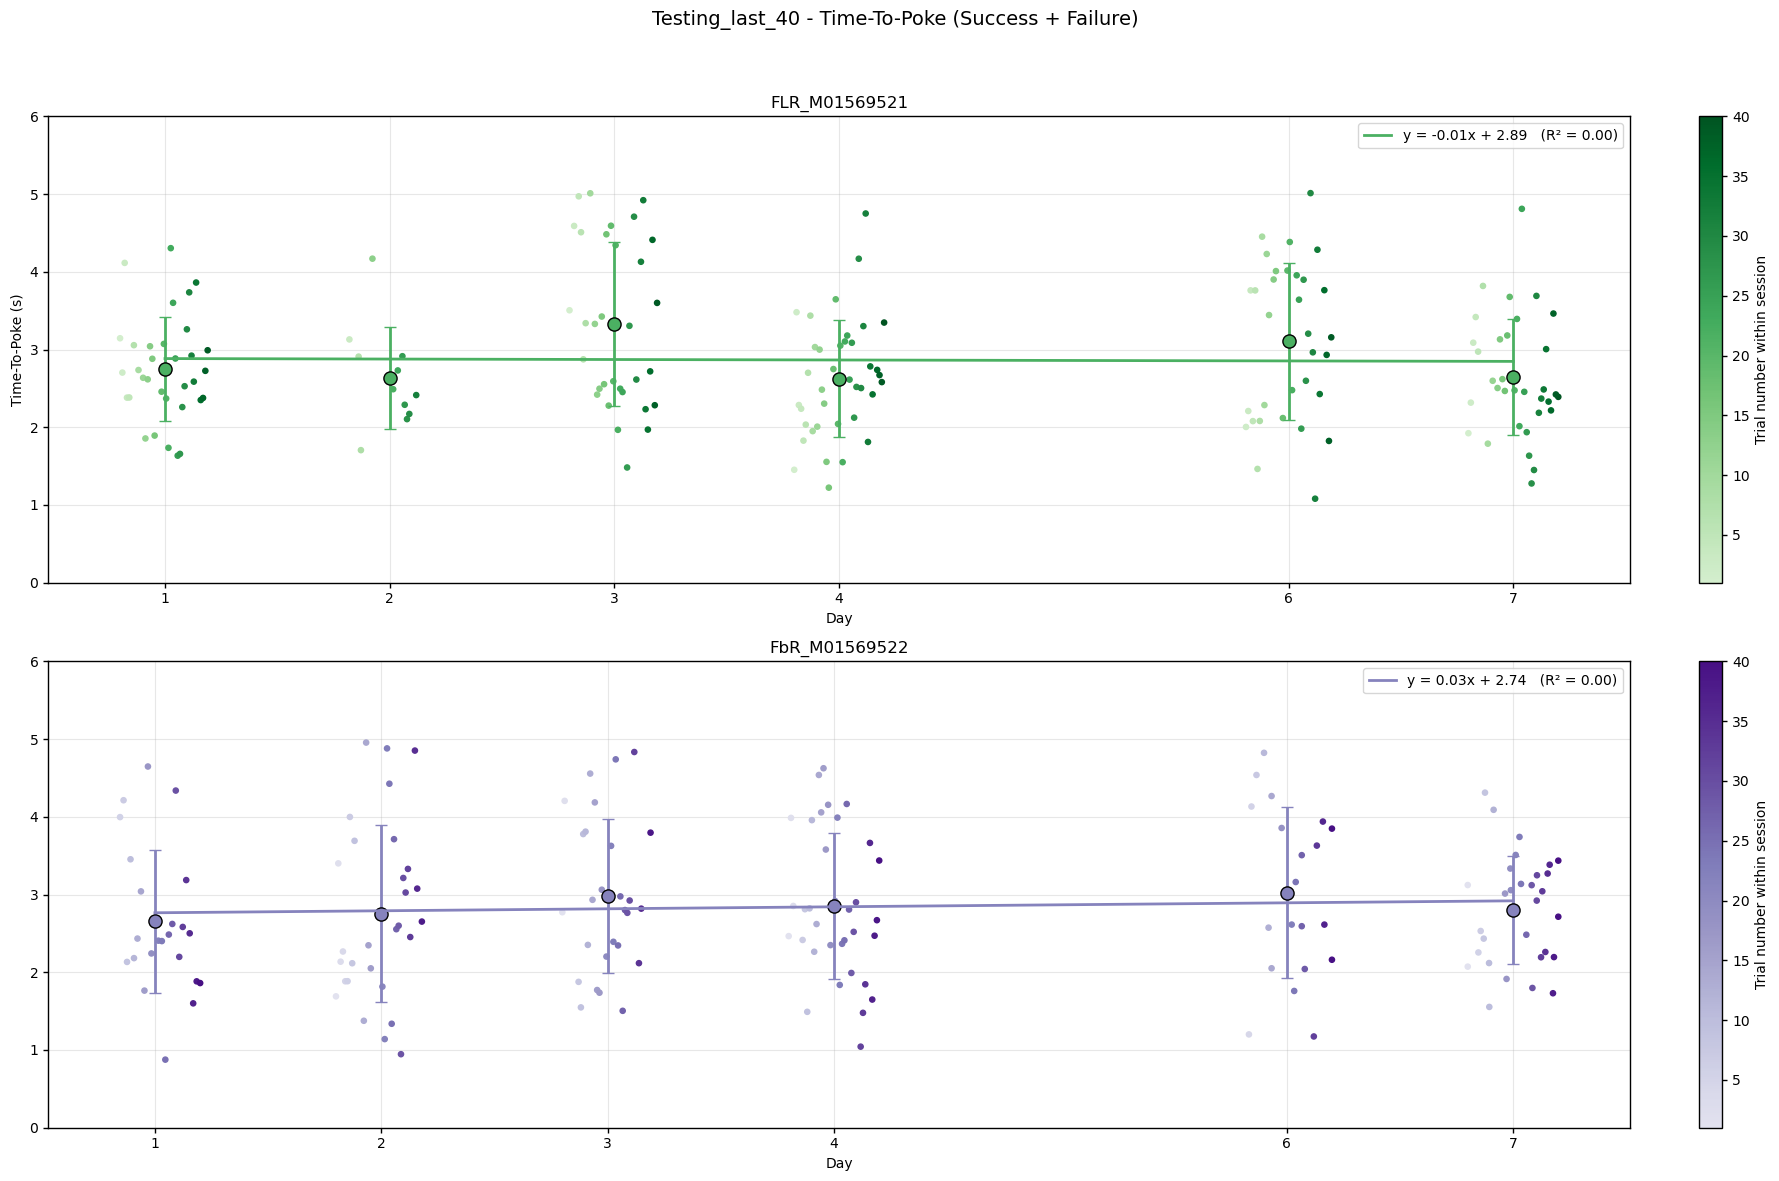

=== Summary statistics: Testing_last_40 (trial_filter='all') ===


/tmp/ipykernel_2892238/3405151723.py:59: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_all_trials["rank_norm"] = df_all_trials.groupby("session", group_keys=False).apply(_rank_norm)


n_trials  n_success  n_fail  n_miss  n_angle    mean  \
day_num mouseID                                                               
1       FLR_M01569521        40         33       0       7       33   0.000   
        FbR_M01569522        27         21       3       3       24   2.500   
2       FLR_M01569521        40          8       3      29       11  12.727   
        FbR_M01569522        40         17      12      11       29  -4.138   
3       FLR_M01569521        40         31       1       8       32  -3.750   
        FbR_M01569522        40         25       2      13       27   2.222   
4       FLR_M01569521        40         38       0       2       38   0.000   
        FbR_M01569522        40         33       1       6       34  -0.588   
6       FLR_M01569521        40         32       0       8       32   0.000   
        FbR_M01569522        34          4      16      14       20  11.000   
7       FLR_M01569521        40         34       0       6       34   0.000   
        FbR_M01569522        40         11      20       9       31  -9.032   

                           sd  median    min    max  n_pos  n_neg  
day_num mouseID                                                    
1       FLR_M01569521   0.000     0.0    0.0    0.0      0      0  
        FbR_M01569522   6.757     0.0    0.0   20.0      3      0  
2       FLR_M01569521  24.121     0.0    0.0   60.0      3      0  
        FbR_M01569522  47.322     0.0 -180.0   40.0     10      2  
3       FLR_M01569521  21.213     0.0 -120.0    0.0      0      1  
        FbR_M01569522   8.473     0.0    0.0   40.0      2      0  
4       FLR_M01569521   0.000     0.0    0.0    0.0      0      0  
        FbR_M01569522   3.430     0.0  -20.0    0.0      0      1  
6       FLR_M01569521   0.000     0.0    0.0    0.0      0      0  
        FbR_M01569522  76.907     0.0 -120.0  140.0      9      7  
7       FLR_M01569521   0.000     0.0    0.0    0.0      0      0  
        FbR_M01569522  61.284     0.0 -180.0   80.0     14      6

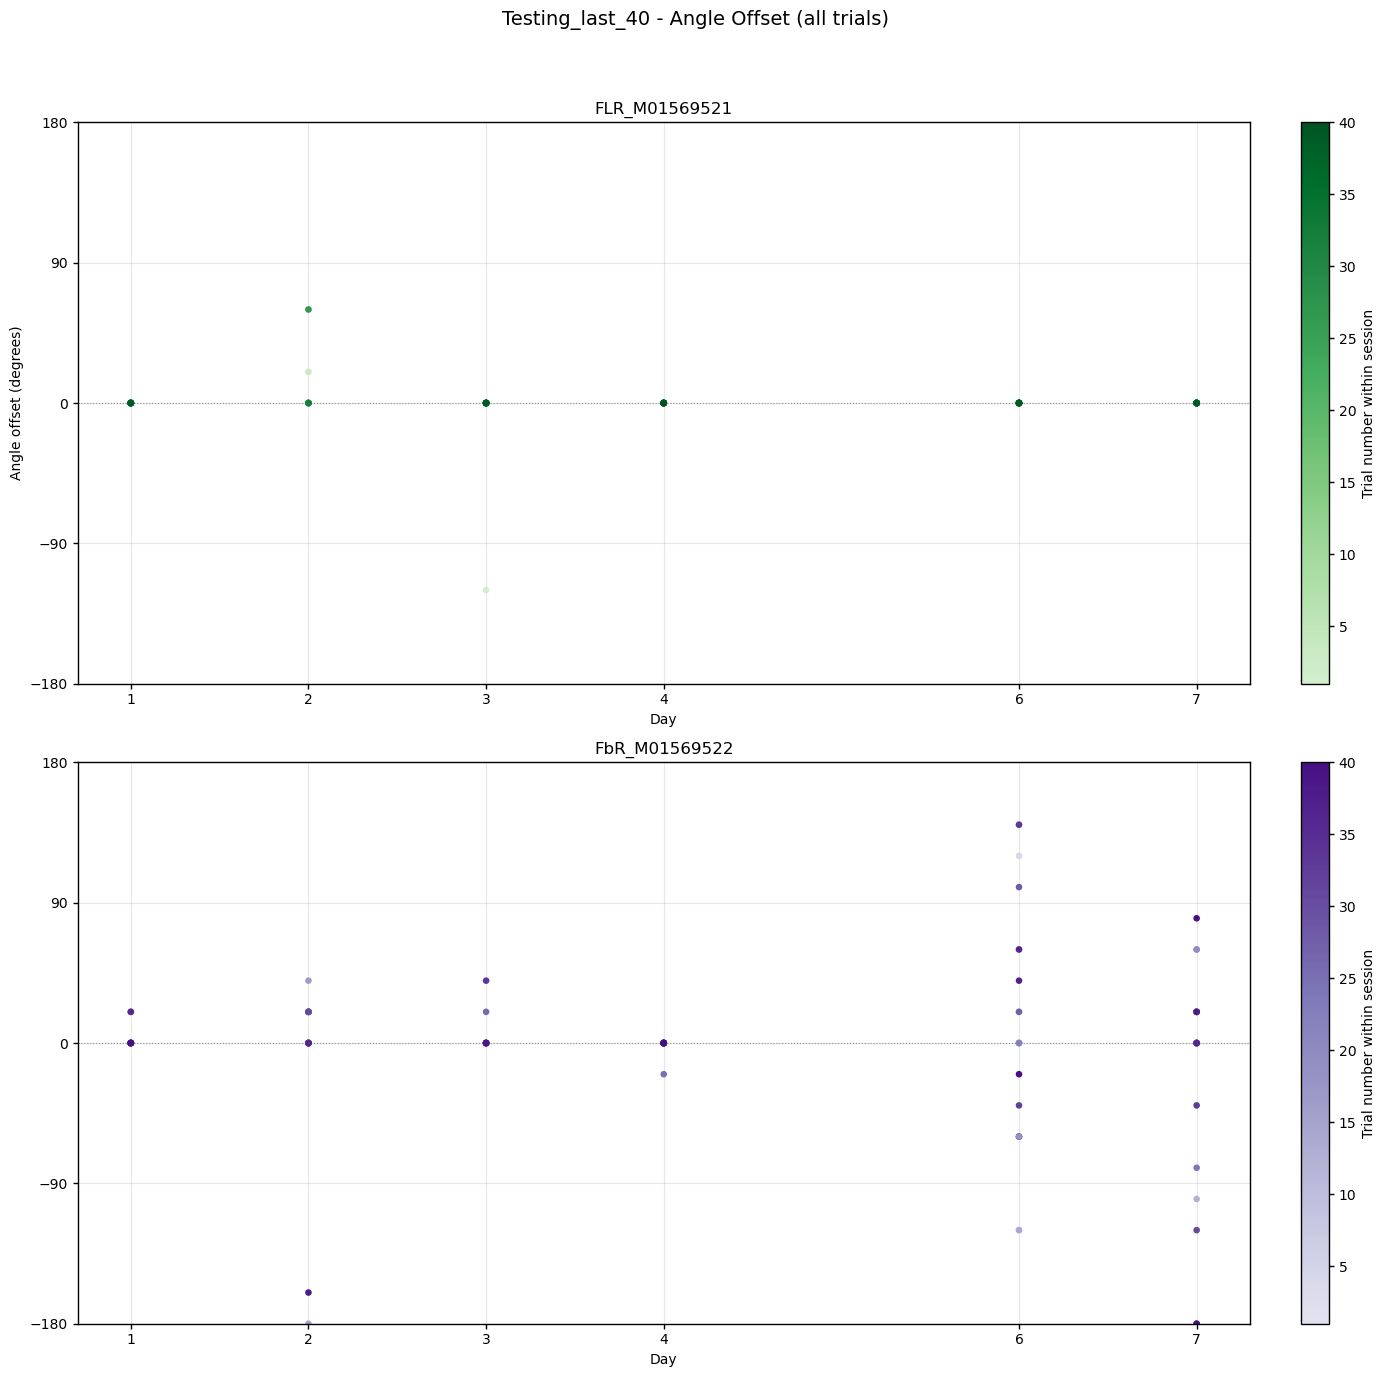

=== Summary statistics: Testing_last_40 (trial_filter='all') ===


/tmp/ipykernel_2892238/338652183.py:59: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_all_trials["rank_norm"] = df_all_trials.groupby("session", group_keys=False).apply(_rank_norm)


n_trials  n_success  n_fail  n_miss  n_angle    mean  \
day_num mouseID                                                               
1       FLR_M01569521        40         33       0       7       33   0.000   
        FbR_M01569522        27         21       3       3       24   2.500   
2       FLR_M01569521        40          8       3      29       11  12.727   
        FbR_M01569522        40         17      12      11       29  19.310   
3       FLR_M01569521        40         31       1       8       32   3.750   
        FbR_M01569522        40         25       2      13       27   2.222   
4       FLR_M01569521        40         38       0       2       38   0.000   
        FbR_M01569522        40         33       1       6       34   0.588   
6       FLR_M01569521        40         32       0       8       32   0.000   
        FbR_M01569522        34          4      16      14       20  59.000   
7       FLR_M01569521        40         34       0       6       34   0.000   
        FbR_M01569522        40         11      20       9       31  36.129   

                           sd  median  min    max  
day_num mouseID                                    
1       FLR_M01569521   0.000     0.0  0.0    0.0  
        FbR_M01569522   6.757     0.0  0.0   20.0  
2       FLR_M01569521  24.121     0.0  0.0   60.0  
        FbR_M01569522  43.254     0.0  0.0  180.0  
3       FLR_M01569521  21.213     0.0  0.0  120.0  
        FbR_M01569522   8.473     0.0  0.0   40.0  
4       FLR_M01569521   0.000     0.0  0.0    0.0  
        FbR_M01569522   3.430     0.0  0.0   20.0  
6       FLR_M01569521   0.000     0.0  0.0    0.0  
        FbR_M01569522  48.764    60.0  0.0  140.0  
7       FLR_M01569521   0.000     0.0  0.0    0.0  
        FbR_M01569522  49.912    20.0  0.0  180.0

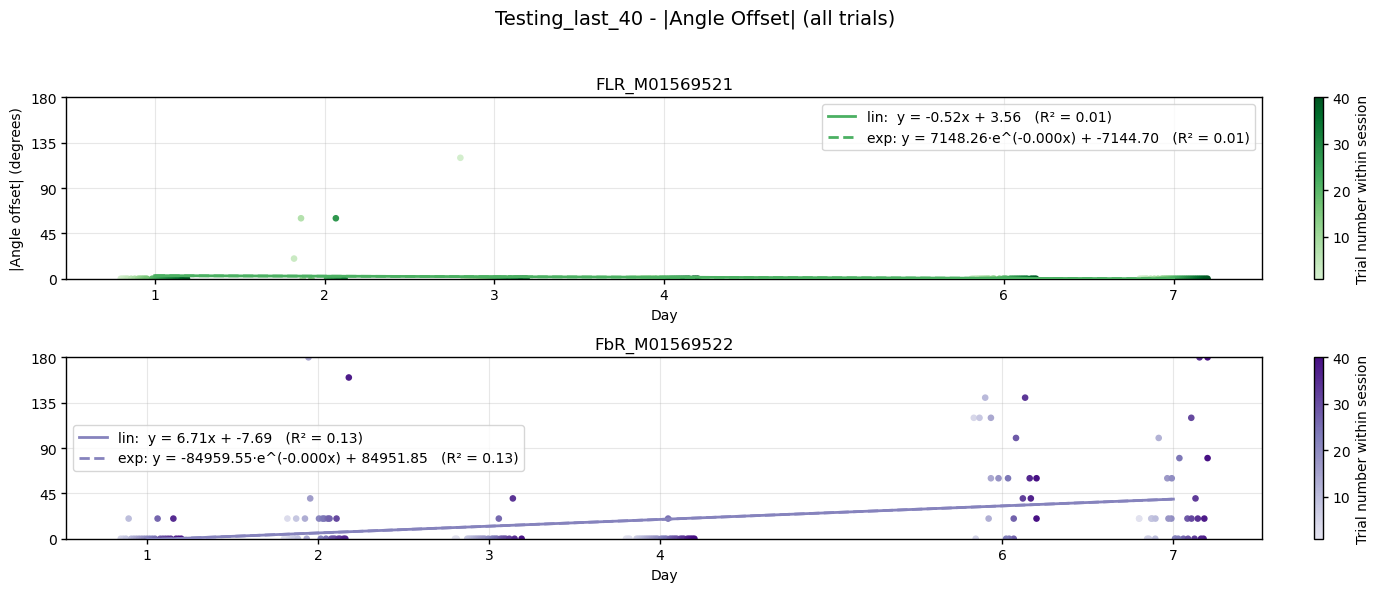

=== Per-(mouse, day) summary: Testing_last_40 ===


n_trials  n_success  n_fail  n_miss  ttp_n  ttp_mean  \
day_num mouseID                                                               
1       FLR_M01569521        40         33       0       7     40     3.146   
        FbR_M01569522        27         21       3       3     27     2.917   
2       FLR_M01569521        40          8       3      29     40     4.361   
        FbR_M01569522        40         17      12      11     40     3.375   
3       FLR_M01569521        40         31       1       8     40     3.669   
        FbR_M01569522        40         25       2      13     40     3.641   
4       FLR_M01569521        40         38       0       2     40     2.745   
        FbR_M01569522        40         33       1       6     40     3.181   
6       FLR_M01569521        40         32       0       8     40     3.488   
        FbR_M01569522        34          4      16      14     34     3.844   
7       FLR_M01569521        40         34       0       6     40     3.008   
        FbR_M01569522        40         11      20       9     40     3.299   

                       ttp_sd  ttp_median  ttp_min  ttp_max  absangle_n  \
day_num mouseID                                                           
1       FLR_M01569521   1.059       2.883    1.634    5.022          33   
        FbR_M01569522   1.151       2.501    0.876    5.024          24   
2       FLR_M01569521   1.125       5.014    1.706    5.020          11   
        FbR_M01569522   1.406       3.271    0.946    5.029          29   
3       FLR_M01569521   1.163       3.552    1.483    5.030          32   
        FbR_M01569522   1.260       3.787    1.504    5.021          27   
4       FLR_M01569521   0.901       2.642    1.223    5.022          38   
        FbR_M01569522   1.164       2.837    1.043    5.016          34   
6       FLR_M01569521   1.187       3.761    1.081    5.016          32   
        FbR_M01569522   1.297       4.200    1.174    5.021          20   
7       FLR_M01569521   1.100       2.609    1.277    5.084          34   
        FbR_M01569522   1.118       3.121    1.554    5.024          31   

                       absangle_mean  absangle_sd  absangle_median  \
day_num mouseID                                                      
1       FLR_M01569521          0.000        0.000              0.0   
        FbR_M01569522          2.500        6.757              0.0   
2       FLR_M01569521         12.727       24.121              0.0   
        FbR_M01569522         19.310       43.254              0.0   
3       FLR_M01569521          3.750       21.213              0.0   
        FbR_M01569522          2.222        8.473              0.0   
4       FLR_M01569521          0.000        0.000              0.0   
        FbR_M01569522          0.588        3.430              0.0   
6       FLR_M01569521          0.000        0.000              0.0   
        FbR_M01569522         59.000       48.764             60.0   
7       FLR_M01569521          0.000        0.000              0.0   
        FbR_M01569522         36.129       49.912             20.0   

                       absangle_min  absangle_max zone_sizes  
day_num mouseID                                               
1       FLR_M01569521           0.0           0.0        150  
        FbR_M01569522           0.0          20.0        150  
2       FLR_M01569521           0.0          60.0        150  
        FbR_M01569522           0.0         180.0        150  
3       FLR_M01569521           0.0         120.0        150  
        FbR_M01569522           0.0          40.0        150  
4       FLR_M01569521           0.0           0.0        150  
        FbR_M01569522           0.0          20.0        150  
6       FLR_M01569521           0.0           0.0        150  
        FbR_M01569522           0.0         140.0        150  
7       FLR_M01569521           0.0           0.0        150  
        FbR_M01569522           0.0         180.0        150

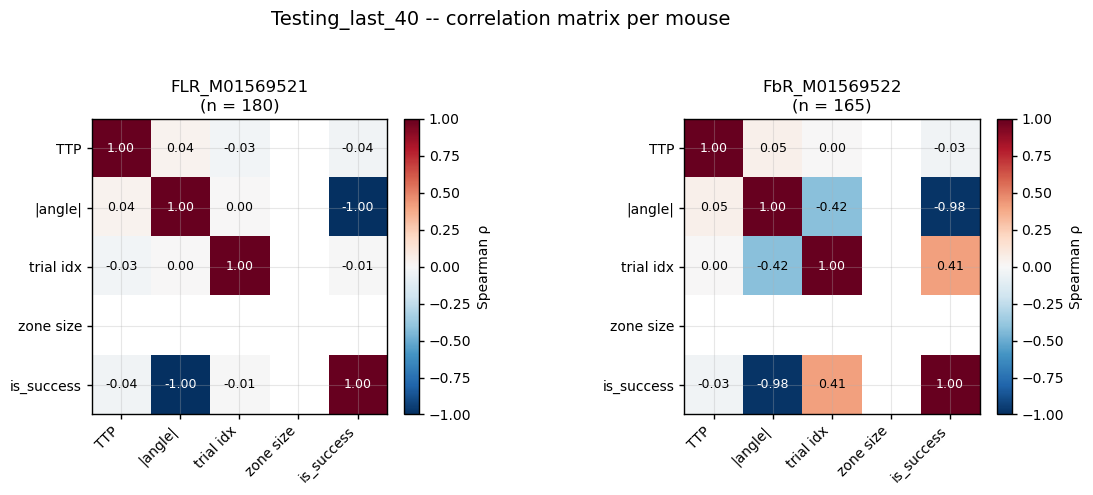


========== Training_last_25 ==========


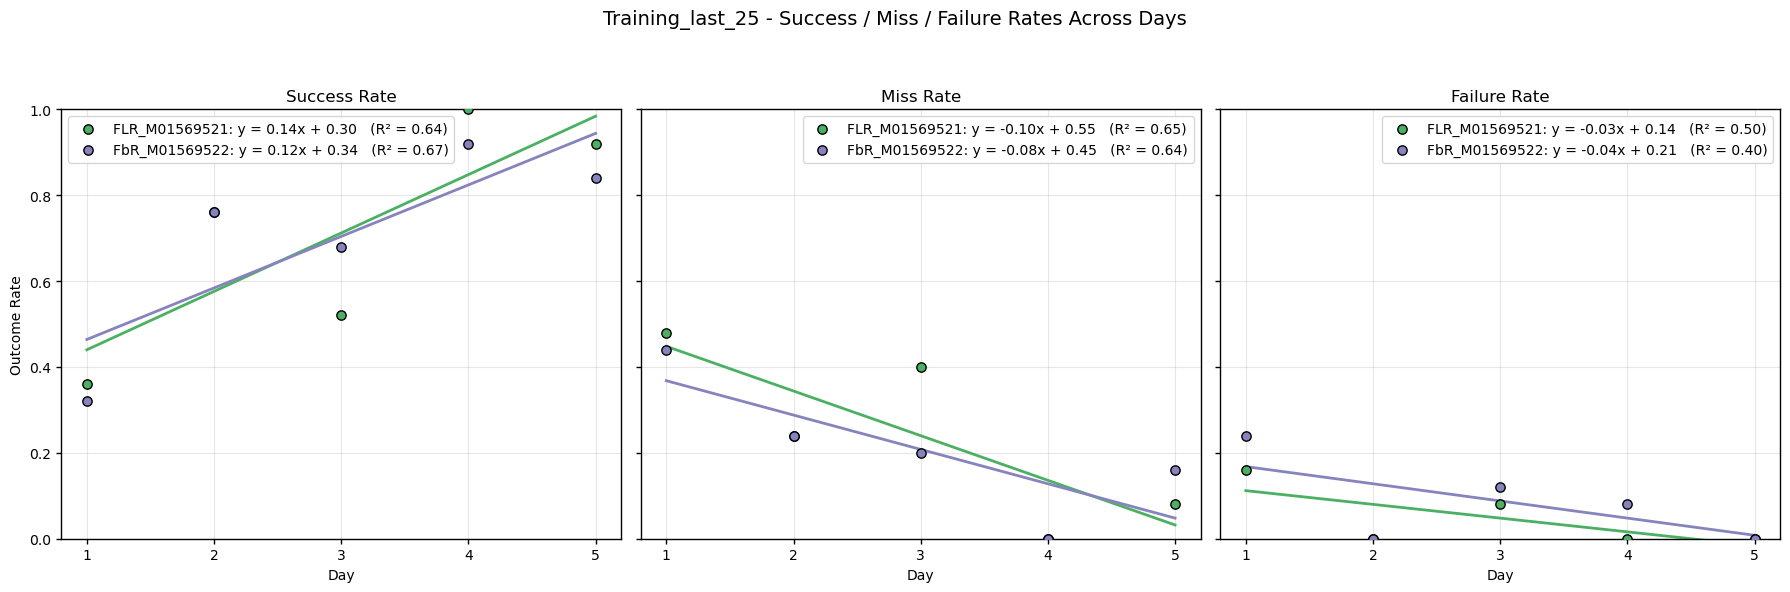

=== Summary statistics: Training_last_25 (trial_filter='no_miss') ===


/tmp/ipykernel_2892238/969829571.py:91: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_all_trials["rank_norm"] = df_all_trials.groupby("session", group_keys=False).apply(_rank_norm)


n_trials  n_success  n_fail  n_miss   mean     sd  \
day_num mouseID                                                            
1       FLR_M01569521        25          9       4      12  3.109  1.030   
        FbR_M01569522        25          8       6      11  2.811  1.051   
2       FLR_M01569521        25         19       0       6  3.476  0.802   
        FbR_M01569522        25         19       0       6  2.814  0.901   
3       FLR_M01569521        25         13       2      10  3.036  0.773   
        FbR_M01569522        25         17       3       5  2.970  0.804   
4       FLR_M01569521        25         25       0       0  2.666  0.825   
        FbR_M01569522        25         23       2       0  2.791  0.883   
5       FLR_M01569521        25         23       0       2  2.758  0.842   
        FbR_M01569522        25         21       0       4  2.812  0.621   

                       median    min    max  
day_num mouseID                              
1       FLR_M01569521   3.010  1.637  4.714  
        FbR_M01569522   2.607  1.186  4.561  
2       FLR_M01569521   3.383  2.098  4.986  
        FbR_M01569522   2.568  1.623  4.205  
3       FLR_M01569521   2.801  1.619  4.214  
        FbR_M01569522   2.841  1.906  4.346  
4       FLR_M01569521   2.433  1.520  4.748  
        FbR_M01569522   2.651  1.255  4.423  
5       FLR_M01569521   2.446  1.446  4.815  
        FbR_M01569522   2.853  1.725  4.244

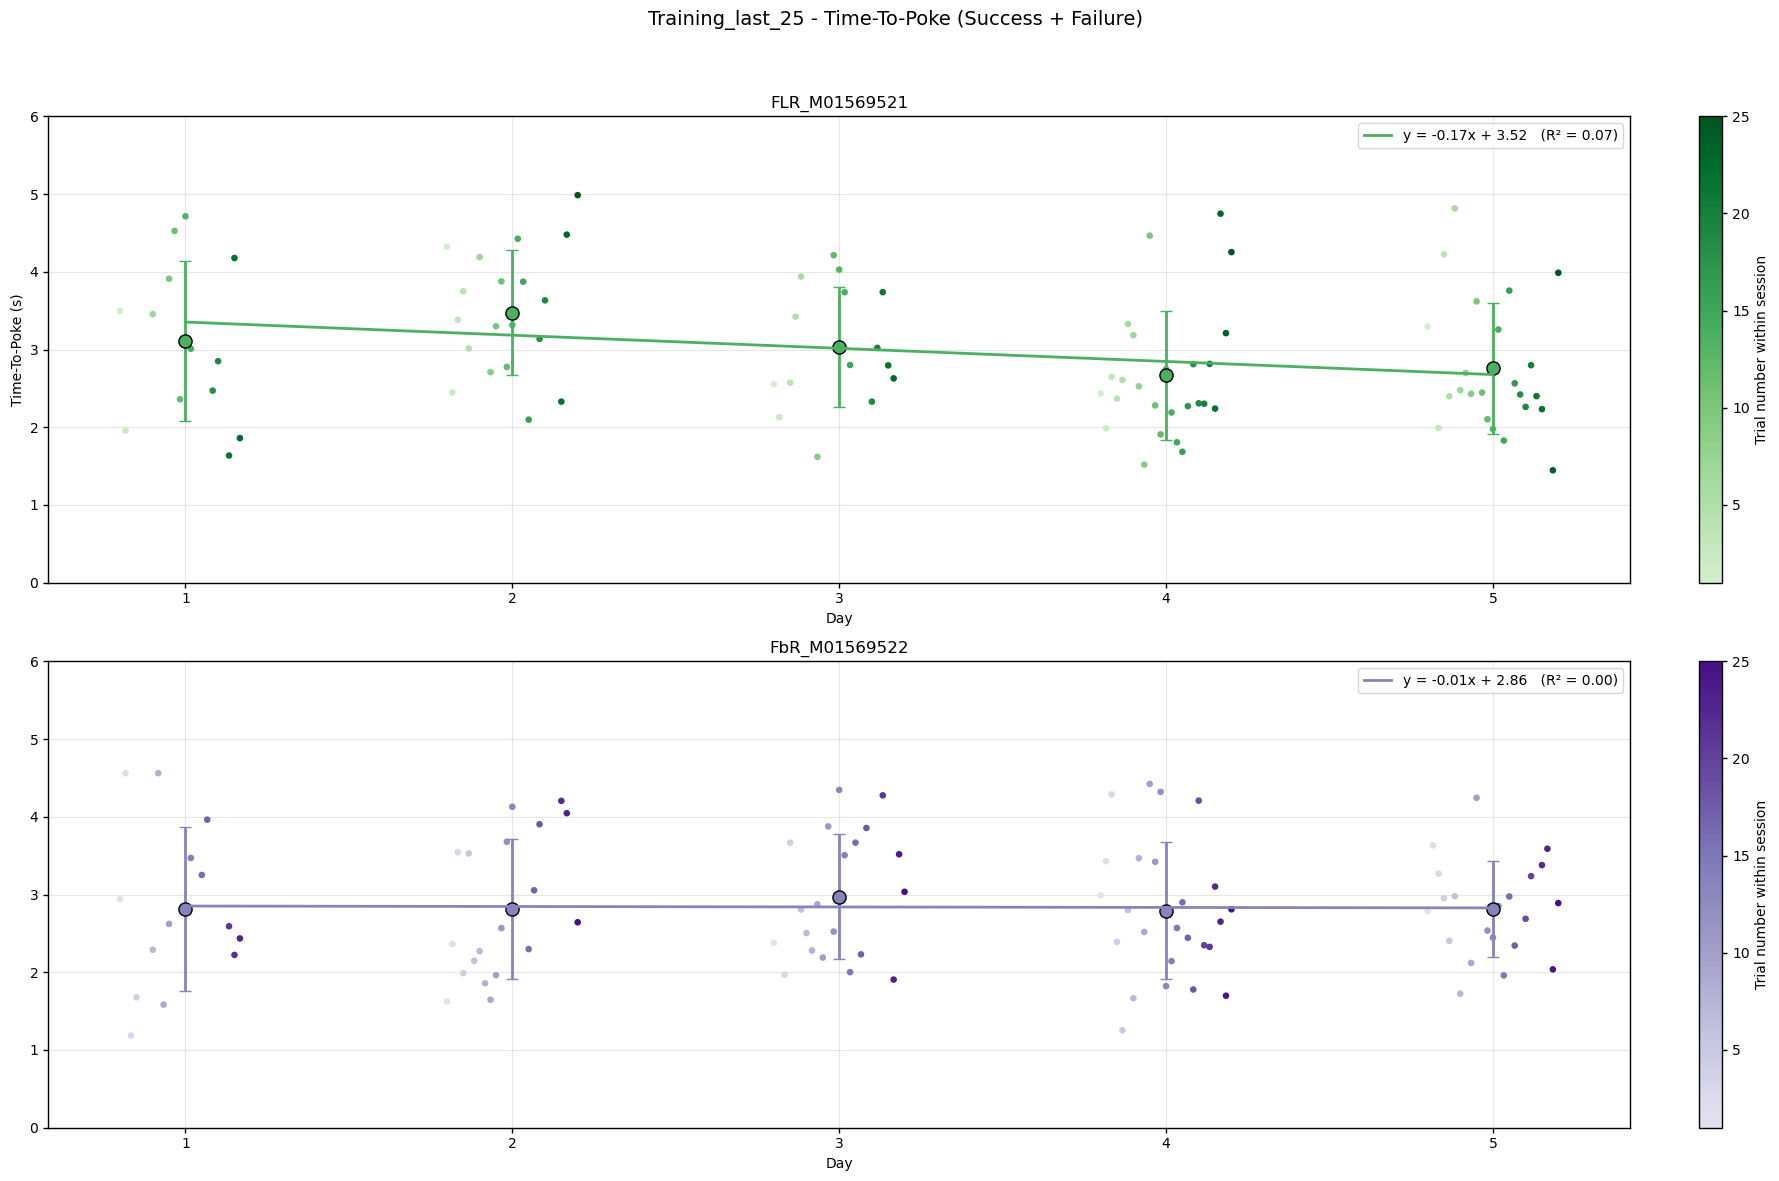

=== Summary statistics: Training_last_25 (trial_filter='all') ===


/tmp/ipykernel_2892238/3405151723.py:59: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_all_trials["rank_norm"] = df_all_trials.groupby("session", group_keys=False).apply(_rank_norm)


n_trials  n_success  n_fail  n_miss  n_angle    mean  \
day_num mouseID                                                               
1       FLR_M01569521        25          9       4      12       13  26.154   
        FbR_M01569522        25          8       6      11       14 -11.429   
2       FLR_M01569521        25         19       0       6       19   0.000   
        FbR_M01569522        25         19       0       6       19   0.000   
3       FLR_M01569521        25         13       2      10       15   2.667   
        FbR_M01569522        25         17       3       5       20   2.000   
4       FLR_M01569521        25         25       0       0       25   0.000   
        FbR_M01569522        25         23       2       0       25   1.600   
5       FLR_M01569521        25         23       0       2       23   0.000   
        FbR_M01569522        25         21       0       4       21   0.000   

                           sd  median    min    max  n_pos  n_neg  
day_num mouseID                                                    
1       FLR_M01569521  85.395     0.0 -140.0  160.0      3      1  
        FbR_M01569522  20.327     0.0  -40.0   20.0      1      5  
2       FLR_M01569521   0.000     0.0    0.0    0.0      0      0  
        FbR_M01569522   0.000     0.0    0.0    0.0      0      0  
3       FLR_M01569521   7.037     0.0    0.0   20.0      2      0  
        FbR_M01569522  11.050     0.0  -20.0   40.0      2      1  
4       FLR_M01569521   0.000     0.0    0.0    0.0      0      0  
        FbR_M01569522   5.538     0.0    0.0   20.0      2      0  
5       FLR_M01569521   0.000     0.0    0.0    0.0      0      0  
        FbR_M01569522   0.000     0.0    0.0    0.0      0      0

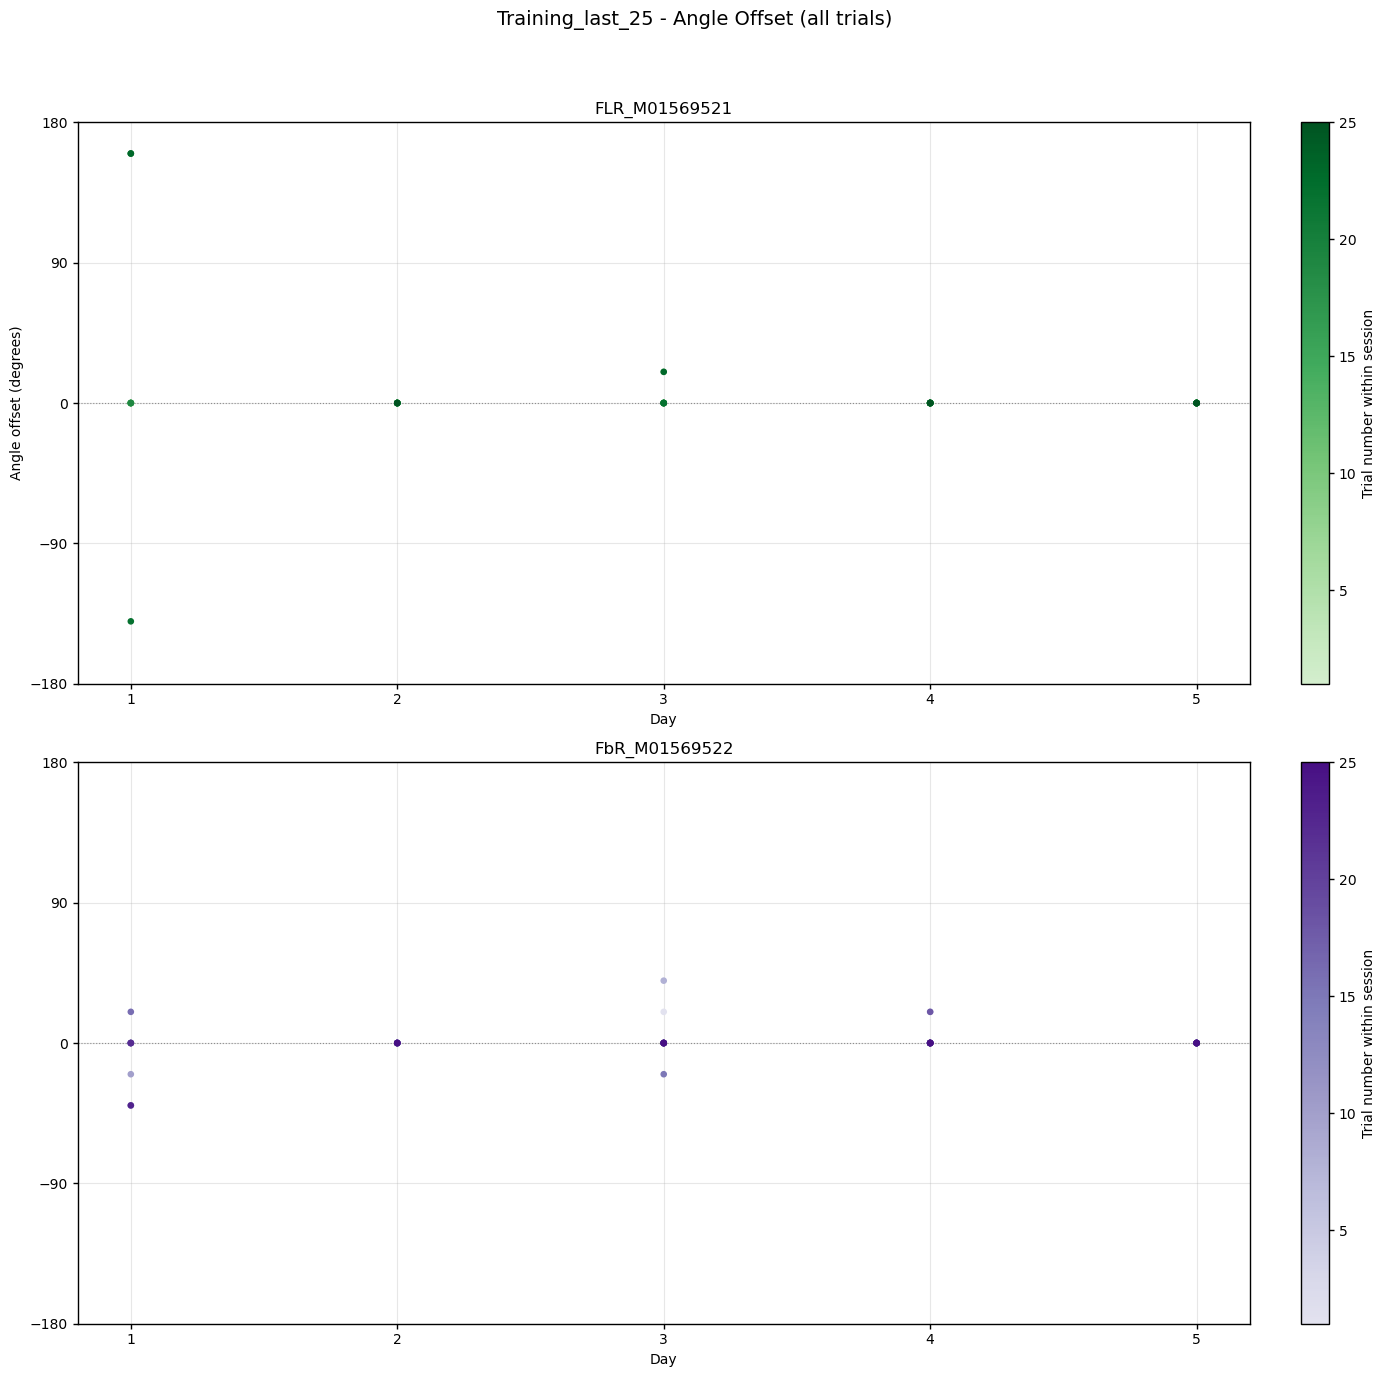

=== Summary statistics: Training_last_25 (trial_filter='all') ===


/tmp/ipykernel_2892238/338652183.py:59: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_all_trials["rank_norm"] = df_all_trials.groupby("session", group_keys=False).apply(_rank_norm)


n_trials  n_success  n_fail  n_miss  n_angle    mean  \
day_num mouseID                                                               
1       FLR_M01569521        25          9       4      12       13  47.692   
        FbR_M01569522        25          8       6      11       14  14.286   
2       FLR_M01569521        25         19       0       6       19   0.000   
        FbR_M01569522        25         19       0       6       19   0.000   
3       FLR_M01569521        25         13       2      10       15   2.667   
        FbR_M01569522        25         17       3       5       20   4.000   
4       FLR_M01569521        25         25       0       0       25   0.000   
        FbR_M01569522        25         23       2       0       25   1.600   
5       FLR_M01569521        25         23       0       2       23   0.000   
        FbR_M01569522        25         21       0       4       21   0.000   

                           sd  median  min    max  
day_num mouseID                                    
1       FLR_M01569521  74.627     0.0  0.0  160.0  
        FbR_M01569522  18.277     0.0  0.0   40.0  
2       FLR_M01569521   0.000     0.0  0.0    0.0  
        FbR_M01569522   0.000     0.0  0.0    0.0  
3       FLR_M01569521   7.037     0.0  0.0   20.0  
        FbR_M01569522  10.463     0.0  0.0   40.0  
4       FLR_M01569521   0.000     0.0  0.0    0.0  
        FbR_M01569522   5.538     0.0  0.0   20.0  
5       FLR_M01569521   0.000     0.0  0.0    0.0  
        FbR_M01569522   0.000     0.0  0.0    0.0

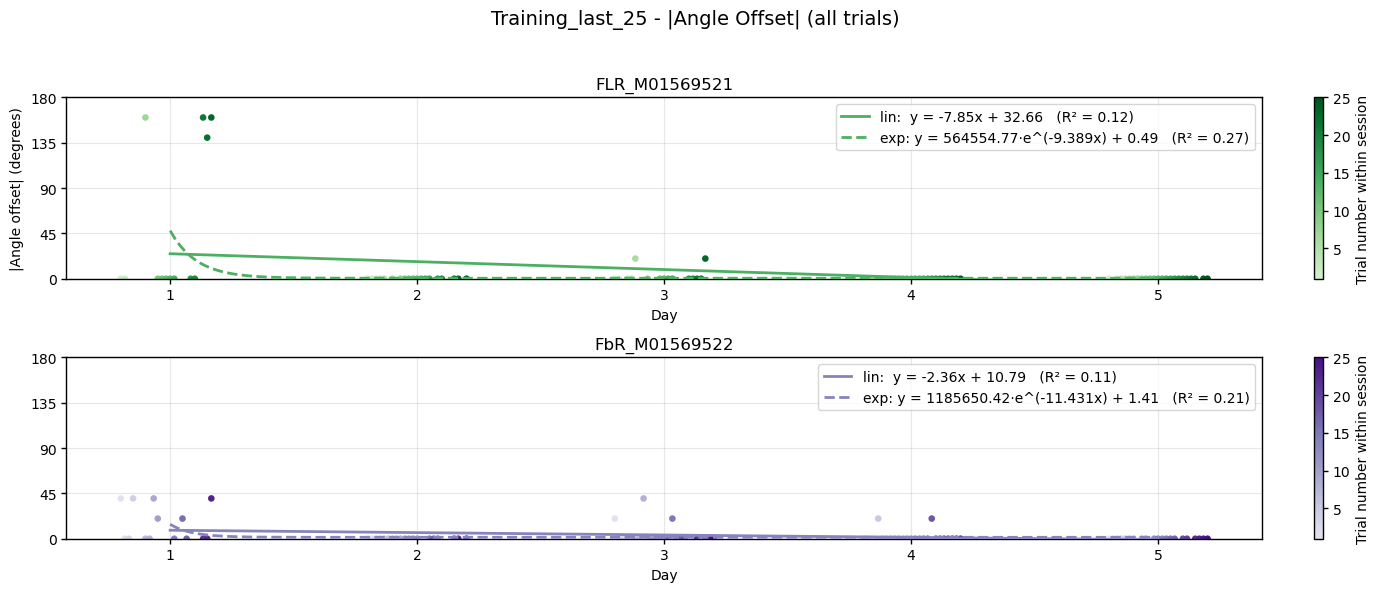

=== Per-(mouse, day) summary: Training_last_25 ===


n_trials  n_success  n_fail  n_miss  ttp_n  ttp_mean  \
day_num mouseID                                                               
1       FLR_M01569521        25          9       4      12     25     4.026   
        FbR_M01569522        25          8       6      11     25     3.779   
2       FLR_M01569521        25         19       0       6     25     3.846   
        FbR_M01569522        25         19       0       6     25     3.343   
3       FLR_M01569521        25         13       2      10     25     3.827   
        FbR_M01569522        25         17       3       5     25     3.379   
4       FLR_M01569521        25         25       0       0     25     2.666   
        FbR_M01569522        25         23       2       0     25     2.791   
5       FLR_M01569521        25         23       0       2     25     2.939   
        FbR_M01569522        25         21       0       4     25     3.165   

                       ttp_sd  ttp_median  ttp_min  ttp_max  absangle_n  \
day_num mouseID                                                           
1       FLR_M01569521   1.216       4.714    1.637    5.022          13   
        FbR_M01569522   1.357       4.560    1.186    5.017          14   
2       FLR_M01569521   0.967       3.873    2.098    5.026          19   
        FbR_M01569522   1.239       3.528    1.623    5.023          19   
3       FLR_M01569521   1.152       3.938    1.619    5.015          15   
        FbR_M01569522   1.098       3.507    1.906    5.020          20   
4       FLR_M01569521   0.825       2.433    1.520    4.748          25   
        FbR_M01569522   0.883       2.651    1.255    4.423          25   
5       FLR_M01569521   1.022       2.476    1.446    5.029          23   
        FbR_M01569522   1.001       2.952    1.725    5.020          21   

                       absangle_mean  absangle_sd  absangle_median  \
day_num mouseID                                                      
1       FLR_M01569521         47.692       74.627              0.0   
        FbR_M01569522         14.286       18.277              0.0   
2       FLR_M01569521          0.000        0.000              0.0   
        FbR_M01569522          0.000        0.000              0.0   
3       FLR_M01569521          2.667        7.037              0.0   
        FbR_M01569522          4.000       10.463              0.0   
4       FLR_M01569521          0.000        0.000              0.0   
        FbR_M01569522          1.600        5.538              0.0   
5       FLR_M01569521          0.000        0.000              0.0   
        FbR_M01569522          0.000        0.000              0.0   

                       absangle_min  absangle_max zone_sizes  
day_num mouseID                                               
1       FLR_M01569521           0.0         160.0        150  
        FbR_M01569522           0.0          40.0        150  
2       FLR_M01569521           0.0           0.0        150  
        FbR_M01569522           0.0           0.0        150  
3       FLR_M01569521           0.0          20.0        150  
        FbR_M01569522           0.0          40.0        150  
4       FLR_M01569521           0.0           0.0        150  
        FbR_M01569522           0.0          20.0        150  
5       FLR_M01569521           0.0           0.0        150  
        FbR_M01569522           0.0           0.0        150

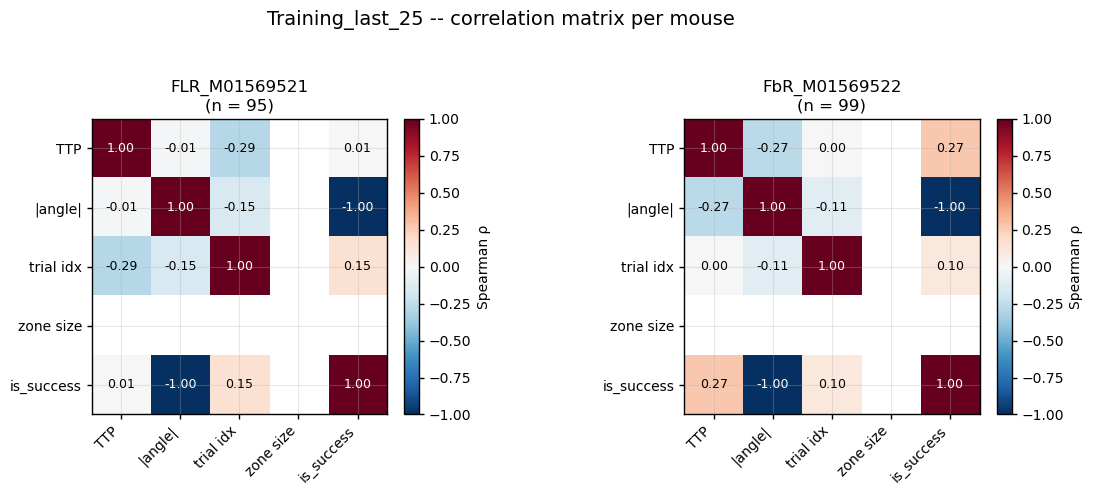


========== Testing_last_25 ==========


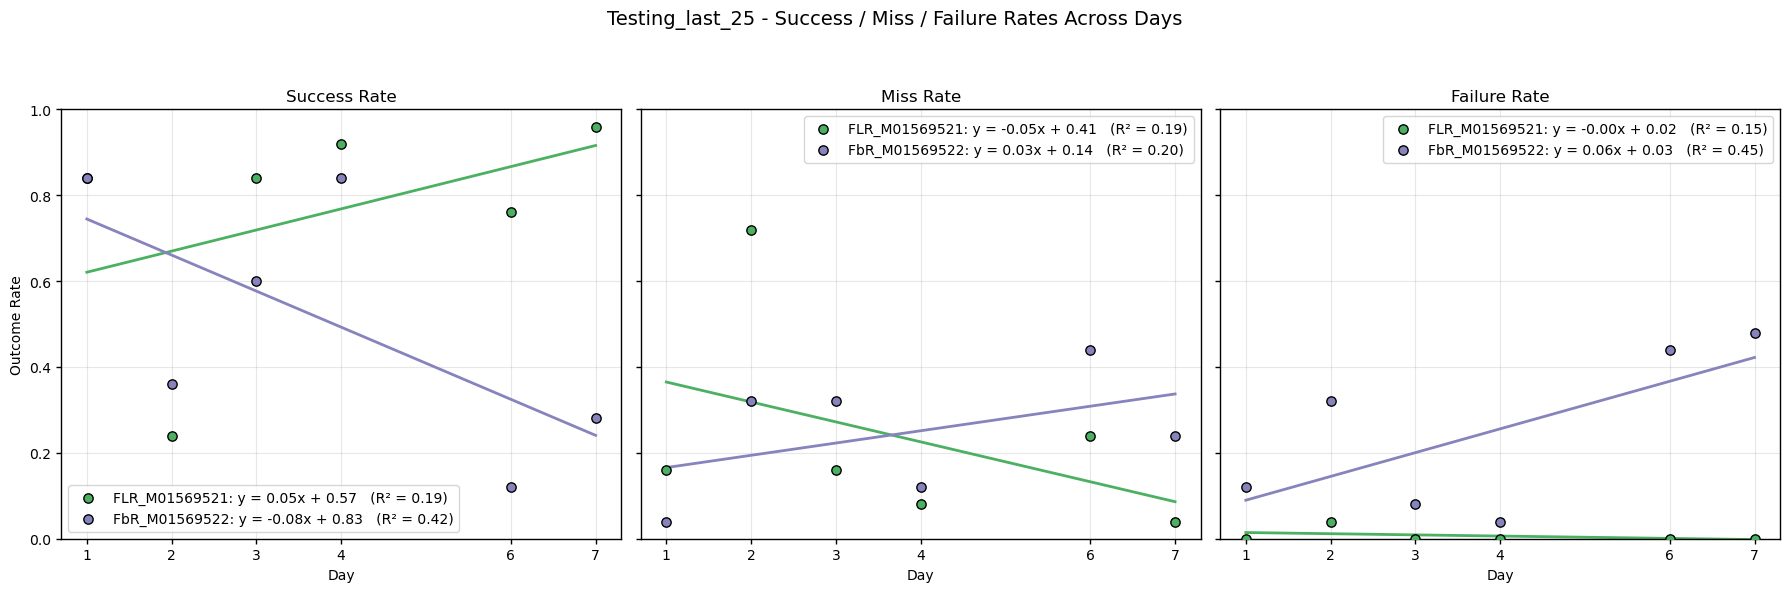

=== Summary statistics: Testing_last_25 (trial_filter='no_miss') ===


/tmp/ipykernel_2892238/969829571.py:91: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_all_trials["rank_norm"] = df_all_trials.groupby("session", group_keys=False).apply(_rank_norm)


n_trials  n_success  n_fail  n_miss   mean     sd  \
day_num mouseID                                                            
1       FLR_M01569521        25         21       0       4  2.724  0.737   
        FbR_M01569522        25         21       3       1  2.654  0.921   
2       FLR_M01569521        25          6       1      18  2.445  0.294   
        FbR_M01569522        25          9       8       8  2.827  1.191   
3       FLR_M01569521        25         21       0       4  3.149  1.086   
        FbR_M01569522        25         15       2       8  2.847  0.959   
4       FLR_M01569521        25         23       0       2  2.781  0.792   
        FbR_M01569522        25         21       1       3  2.767  0.966   
6       FLR_M01569521        25         19       0       6  3.143  1.019   
        FbR_M01569522        25          3      11      11  3.108  0.927   
7       FLR_M01569521        25         24       0       1  2.640  0.799   
        FbR_M01569522        25          7      12       6  2.790  0.802   

                       median    min    max  
day_num mouseID                              
1       FLR_M01569521   2.587  1.634  4.304  
        FbR_M01569522   2.459  0.876  4.647  
2       FLR_M01569521   2.414  2.104  2.914  
        FbR_M01569522   2.652  0.946  4.880  
3       FLR_M01569521   2.614  1.483  4.921  
        FbR_M01569522   2.800  1.504  4.834  
4       FLR_M01569521   2.738  1.223  4.750  
        FbR_M01569522   2.595  1.043  4.624  
6       FLR_M01569521   3.157  1.081  5.012  
        FbR_M01569522   3.334  1.174  4.267  
7       FLR_M01569521   2.471  1.277  4.810  
        FbR_M01569522   2.793  1.554  4.311

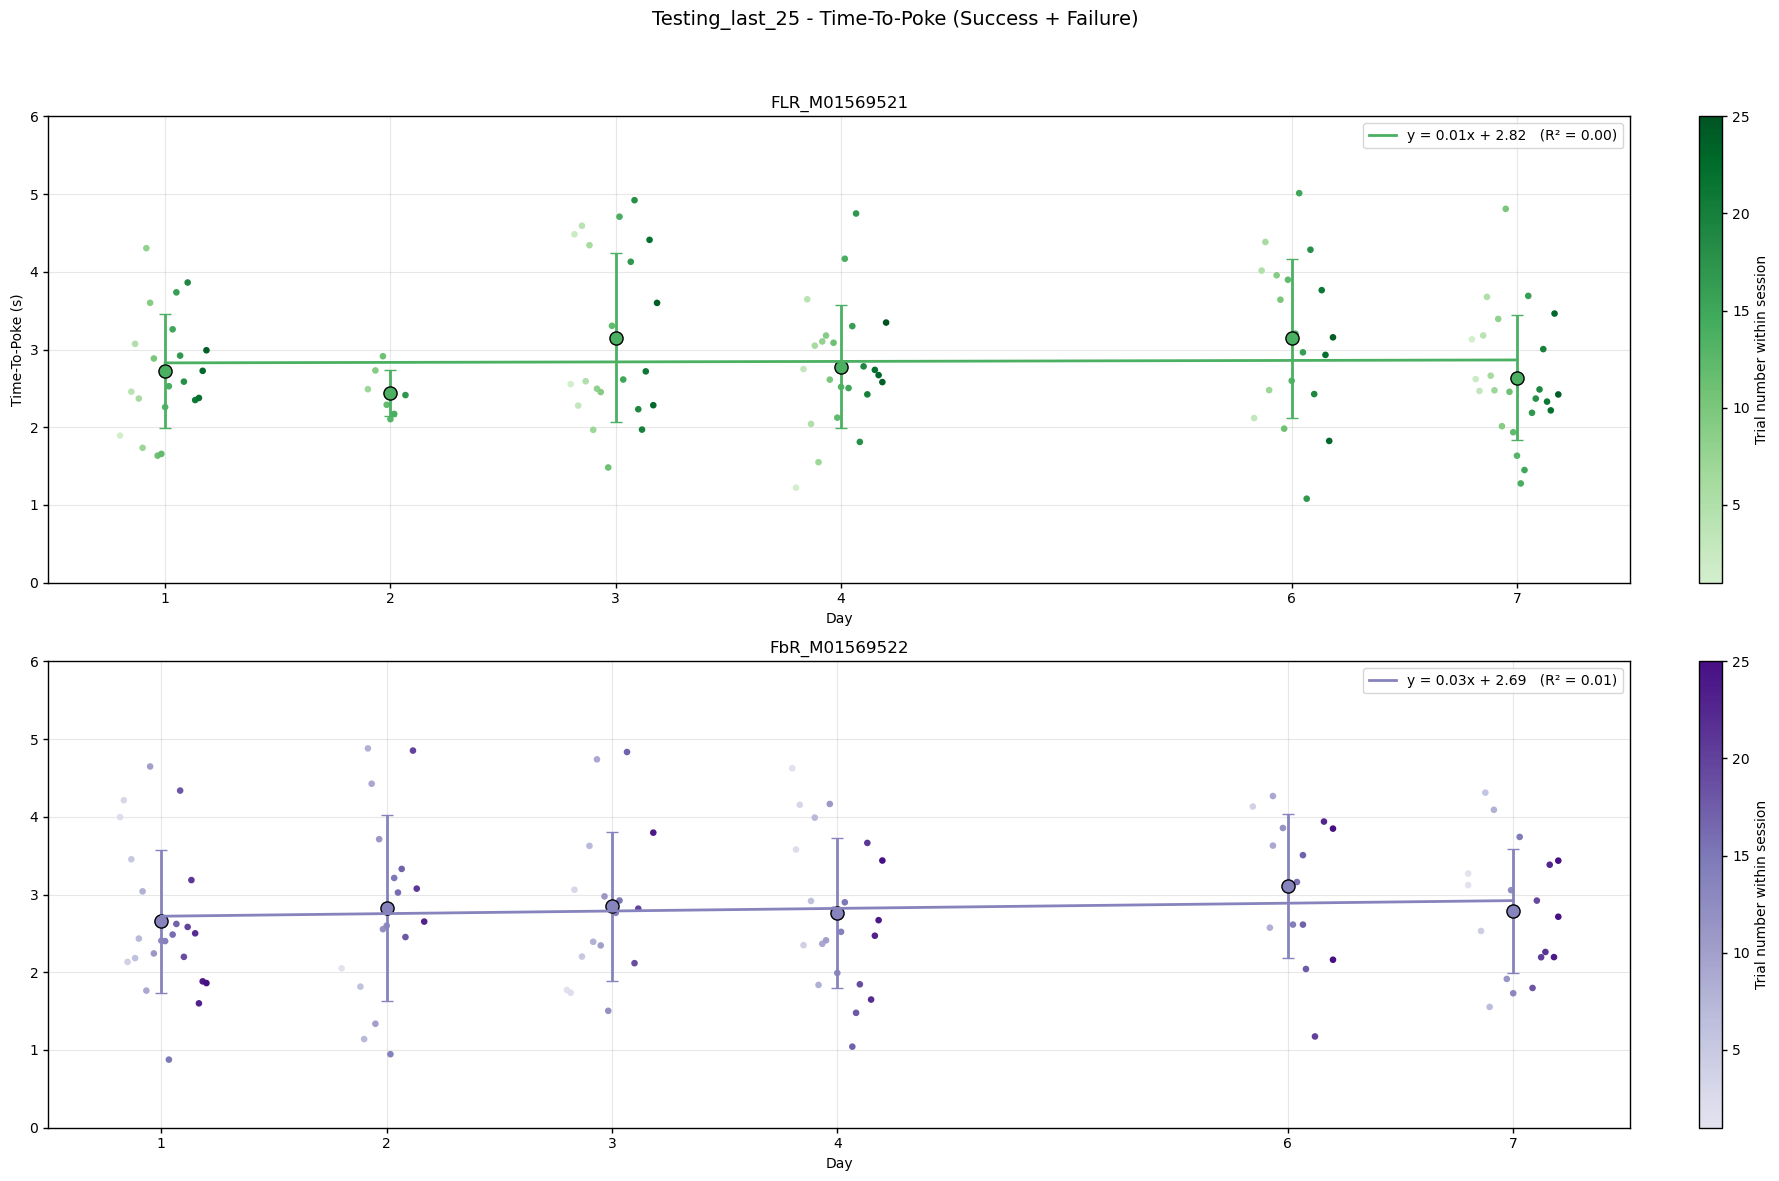

=== Summary statistics: Testing_last_25 (trial_filter='all') ===


/tmp/ipykernel_2892238/3405151723.py:59: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_all_trials["rank_norm"] = df_all_trials.groupby("session", group_keys=False).apply(_rank_norm)


n_trials  n_success  n_fail  n_miss  n_angle    mean  \
day_num mouseID                                                               
1       FLR_M01569521        25         21       0       4       21   0.000   
        FbR_M01569522        25         21       3       1       24   2.500   
2       FLR_M01569521        25          6       1      18        7   8.571   
        FbR_M01569522        25          9       8       8       17   0.000   
3       FLR_M01569521        25         21       0       4       21   0.000   
        FbR_M01569522        25         15       2       8       17   3.529   
4       FLR_M01569521        25         23       0       2       23   0.000   
        FbR_M01569522        25         21       1       3       22  -0.909   
6       FLR_M01569521        25         19       0       6       19   0.000   
        FbR_M01569522        25          3      11      11       14   5.714   
7       FLR_M01569521        25         24       0       1       24   0.000   
        FbR_M01569522        25          7      12       6       19 -16.842   

                           sd  median    min    max  n_pos  n_neg  
day_num mouseID                                                    
1       FLR_M01569521   0.000     0.0    0.0    0.0      0      0  
        FbR_M01569522   6.757     0.0    0.0   20.0      3      0  
2       FLR_M01569521  22.678     0.0    0.0   60.0      1      0  
        FbR_M01569522  43.012     0.0 -160.0   40.0      7      1  
3       FLR_M01569521   0.000     0.0    0.0    0.0      0      0  
        FbR_M01569522  10.572     0.0    0.0   40.0      2      0  
4       FLR_M01569521   0.000     0.0    0.0    0.0      0      0  
        FbR_M01569522   4.264     0.0  -20.0    0.0      0      1  
6       FLR_M01569521   0.000     0.0    0.0    0.0      0      0  
        FbR_M01569522  67.221     0.0 -120.0  140.0      6      5  
7       FLR_M01569521   0.000     0.0    0.0    0.0      0      0  
        FbR_M01569522  73.110     0.0 -180.0   80.0      8      4

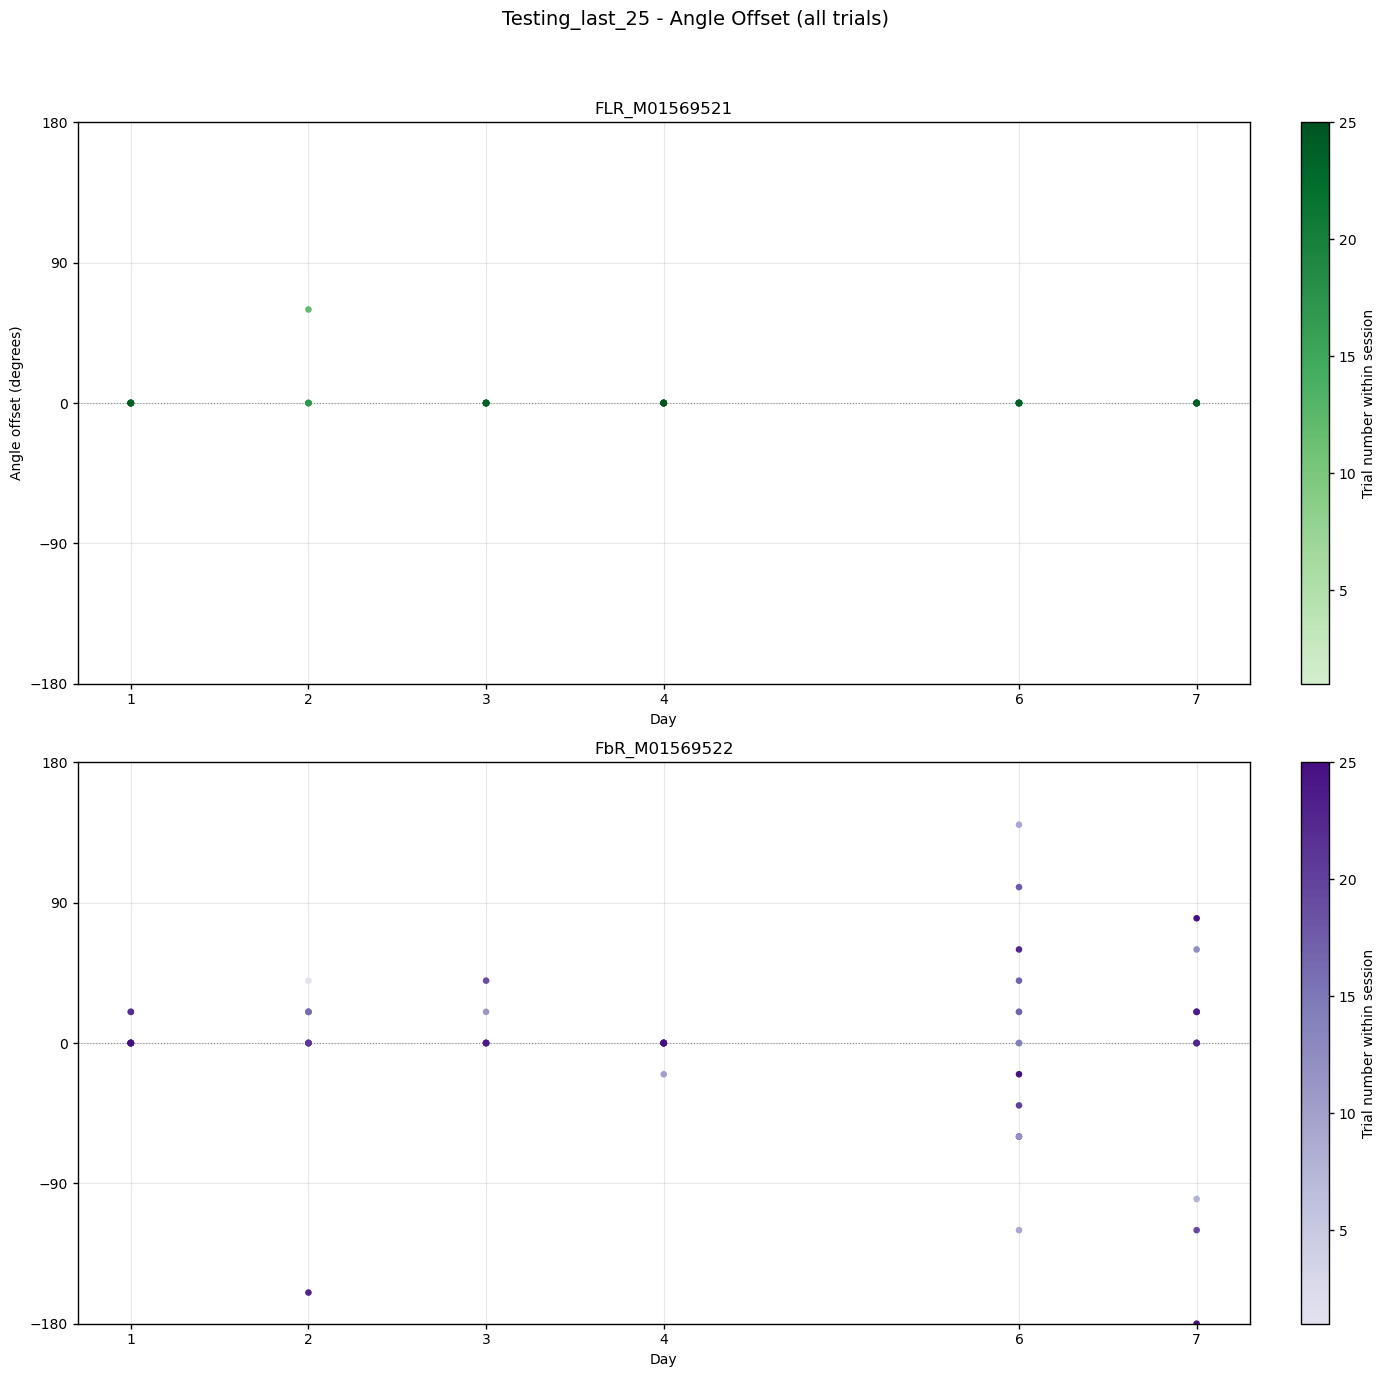

=== Summary statistics: Testing_last_25 (trial_filter='all') ===


/tmp/ipykernel_2892238/338652183.py:59: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_all_trials["rank_norm"] = df_all_trials.groupby("session", group_keys=False).apply(_rank_norm)


n_trials  n_success  n_fail  n_miss  n_angle    mean  \
day_num mouseID                                                               
1       FLR_M01569521        25         21       0       4       21   0.000   
        FbR_M01569522        25         21       3       1       24   2.500   
2       FLR_M01569521        25          6       1      18        7   8.571   
        FbR_M01569522        25          9       8       8       17  18.824   
3       FLR_M01569521        25         21       0       4       21   0.000   
        FbR_M01569522        25         15       2       8       17   3.529   
4       FLR_M01569521        25         23       0       2       23   0.000   
        FbR_M01569522        25         21       1       3       22   0.909   
6       FLR_M01569521        25         19       0       6       19   0.000   
        FbR_M01569522        25          3      11      11       14  48.571   
7       FLR_M01569521        25         24       0       1       24   0.000   
        FbR_M01569522        25          7      12       6       19  44.211   

                           sd  median  min    max  
day_num mouseID                                    
1       FLR_M01569521   0.000     0.0  0.0    0.0  
        FbR_M01569522   6.757     0.0  0.0   20.0  
2       FLR_M01569521  22.678     0.0  0.0   60.0  
        FbR_M01569522  38.387     0.0  0.0  160.0  
3       FLR_M01569521   0.000     0.0  0.0    0.0  
        FbR_M01569522  10.572     0.0  0.0   40.0  
4       FLR_M01569521   0.000     0.0  0.0    0.0  
        FbR_M01569522   4.264     0.0  0.0   20.0  
6       FLR_M01569521   0.000     0.0  0.0    0.0  
        FbR_M01569522  44.869    40.0  0.0  140.0  
7       FLR_M01569521   0.000     0.0  0.0    0.0  
        FbR_M01569522  59.844    20.0  0.0  180.0

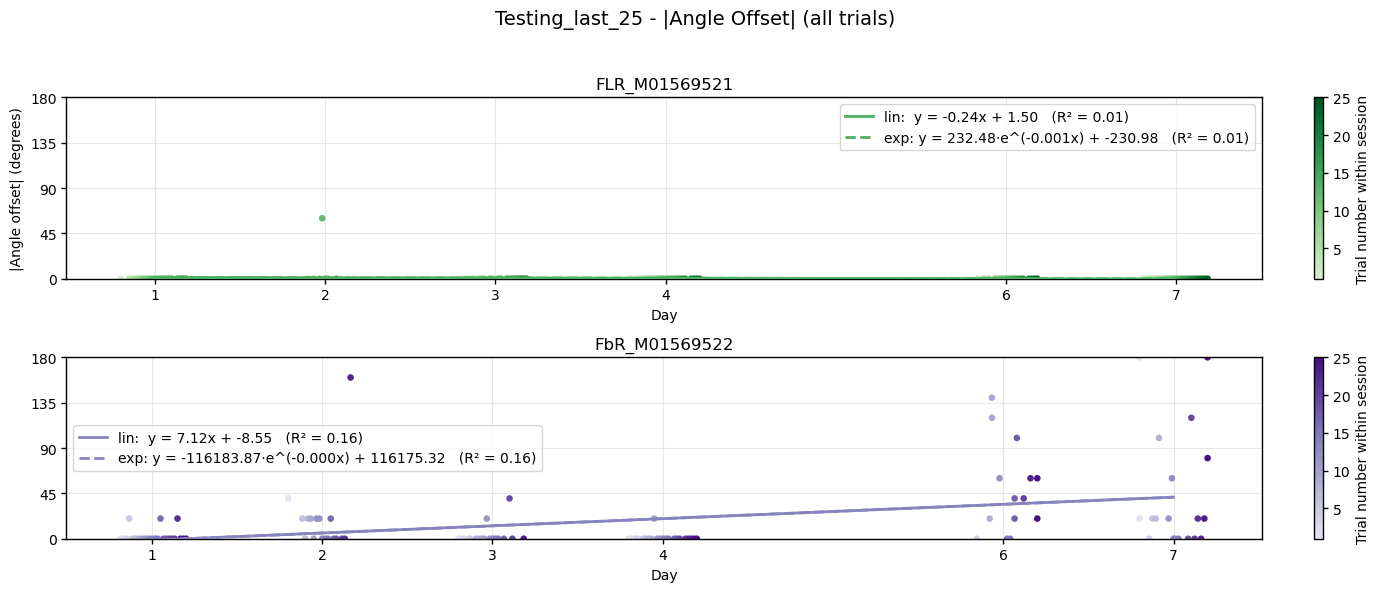

=== Per-(mouse, day) summary: Testing_last_25 ===


n_trials  n_success  n_fail  n_miss  ttp_n  ttp_mean  \
day_num mouseID                                                               
1       FLR_M01569521        25         21       0       4     25     3.090   
        FbR_M01569522        25         21       3       1     25     2.748   
2       FLR_M01569521        25          6       1      18     25     4.296   
        FbR_M01569522        25          9       8       8     25     3.529   
3       FLR_M01569521        25         21       0       4     25     3.449   
        FbR_M01569522        25         15       2       8     25     3.542   
4       FLR_M01569521        25         23       0       2     25     2.960   
        FbR_M01569522        25         21       1       3     25     3.036   
6       FLR_M01569521        25         19       0       6     25     3.592   
        FbR_M01569522        25          3      11      11     25     3.947   
7       FLR_M01569521        25         24       0       1     25     2.735   
        FbR_M01569522        25          7      12       6     25     3.325   

                       ttp_sd  ttp_median  ttp_min  ttp_max  absangle_n  \
day_num mouseID                                                           
1       FLR_M01569521   1.088       2.885    1.634    5.022          21   
        FbR_M01569522   1.017       2.485    0.876    5.011          24   
2       FLR_M01569521   1.187       5.014    2.104    5.019           7   
        FbR_M01569522   1.427       3.330    0.946    5.029          17   
3       FLR_M01569521   1.214       3.305    1.483    5.030          21   
        FbR_M01569522   1.296       3.062    1.504    5.021          17   
4       FLR_M01569521   0.978       2.749    1.223    5.022          23   
        FbR_M01569522   1.171       2.807    1.043    5.015          22   
6       FLR_M01569521   1.201       3.764    1.081    5.016          19   
        FbR_M01569522   1.183       4.132    1.174    5.021          14   
7       FLR_M01569521   0.915       2.475    1.277    5.015          24   
        FbR_M01569522   1.194       3.122    1.554    5.024          19   

                       absangle_mean  absangle_sd  absangle_median  \
day_num mouseID                                                      
1       FLR_M01569521          0.000        0.000              0.0   
        FbR_M01569522          2.500        6.757              0.0   
2       FLR_M01569521          8.571       22.678              0.0   
        FbR_M01569522         18.824       38.387              0.0   
3       FLR_M01569521          0.000        0.000              0.0   
        FbR_M01569522          3.529       10.572              0.0   
4       FLR_M01569521          0.000        0.000              0.0   
        FbR_M01569522          0.909        4.264              0.0   
6       FLR_M01569521          0.000        0.000              0.0   
        FbR_M01569522         48.571       44.869             40.0   
7       FLR_M01569521          0.000        0.000              0.0   
        FbR_M01569522         44.211       59.844             20.0   

                       absangle_min  absangle_max zone_sizes  
day_num mouseID                                               
1       FLR_M01569521           0.0           0.0        150  
        FbR_M01569522           0.0          20.0        150  
2       FLR_M01569521           0.0          60.0        150  
        FbR_M01569522           0.0         160.0        150  
3       FLR_M01569521           0.0           0.0        150  
        FbR_M01569522           0.0          40.0        150  
4       FLR_M01569521           0.0           0.0        150  
        FbR_M01569522           0.0          20.0        150  
6       FLR_M01569521           0.0           0.0        150  
        FbR_M01569522           0.0         140.0        150  
7       FLR_M01569521           0.0           0.0        150  
        FbR_M01569522           0.0         180.0        150

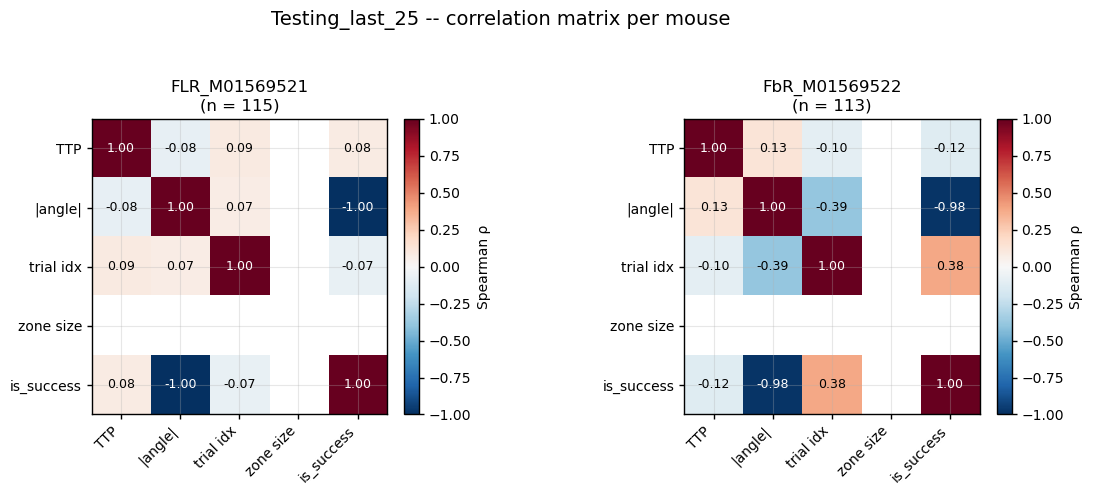


========== Testing_first_40 ==========


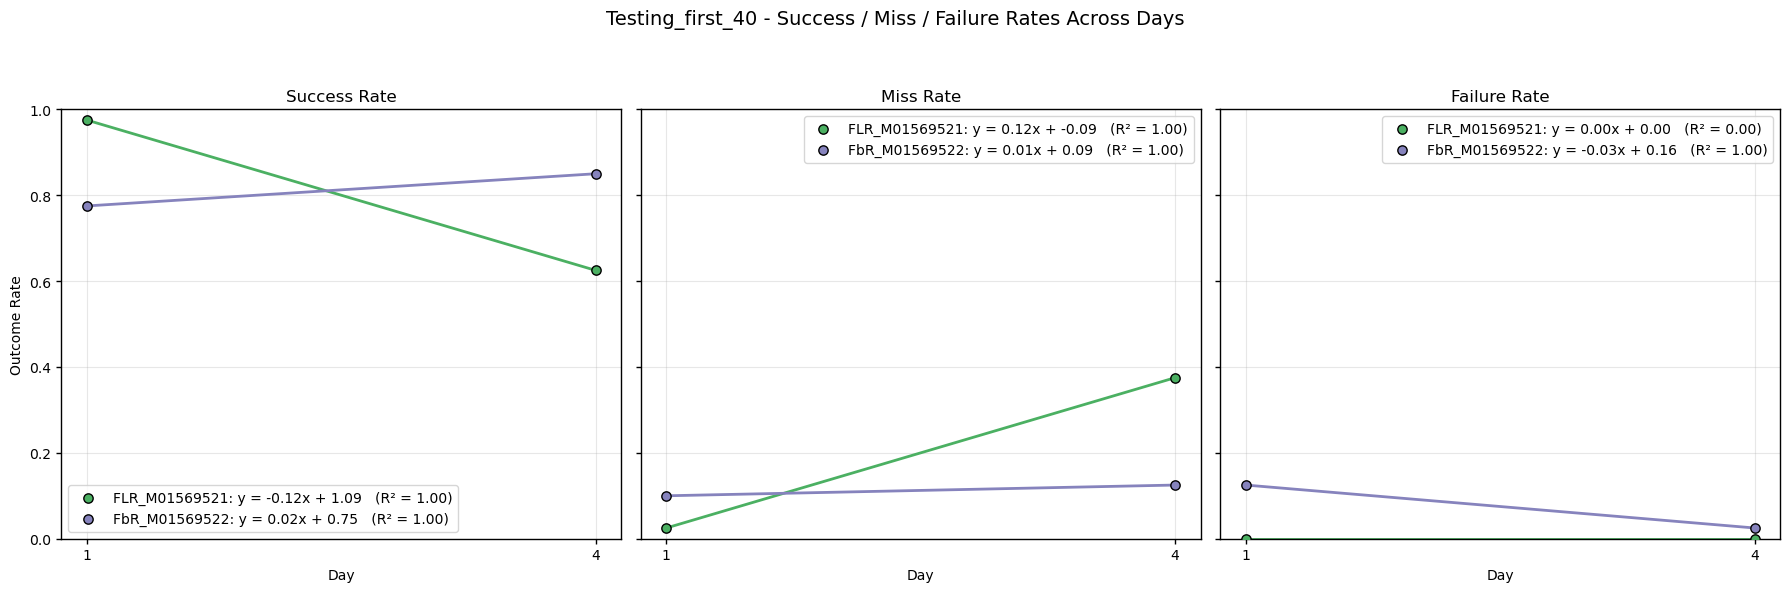

=== Summary statistics: Testing_first_40 (trial_filter='no_miss') ===


/tmp/ipykernel_2892238/969829571.py:91: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_all_trials["rank_norm"] = df_all_trials.groupby("session", group_keys=False).apply(_rank_norm)


n_trials  n_success  n_fail  n_miss   mean     sd  \
day_num mouseID                                                            
1       FLR_M01569521        40         39       0       1  3.042  0.639   
        FbR_M01569522        40         31       5       4  2.491  0.861   
4       FLR_M01569521        40         25       0      15  2.976  0.833   
        FbR_M01569522        40         34       1       5  2.628  0.836   

                       median    min    max  
day_num mouseID                              
1       FLR_M01569521   2.938  1.861  4.130  
        FbR_M01569522   2.260  1.255  4.667  
4       FLR_M01569521   3.118  1.584  4.177  
        FbR_M01569522   2.394  1.325  4.959

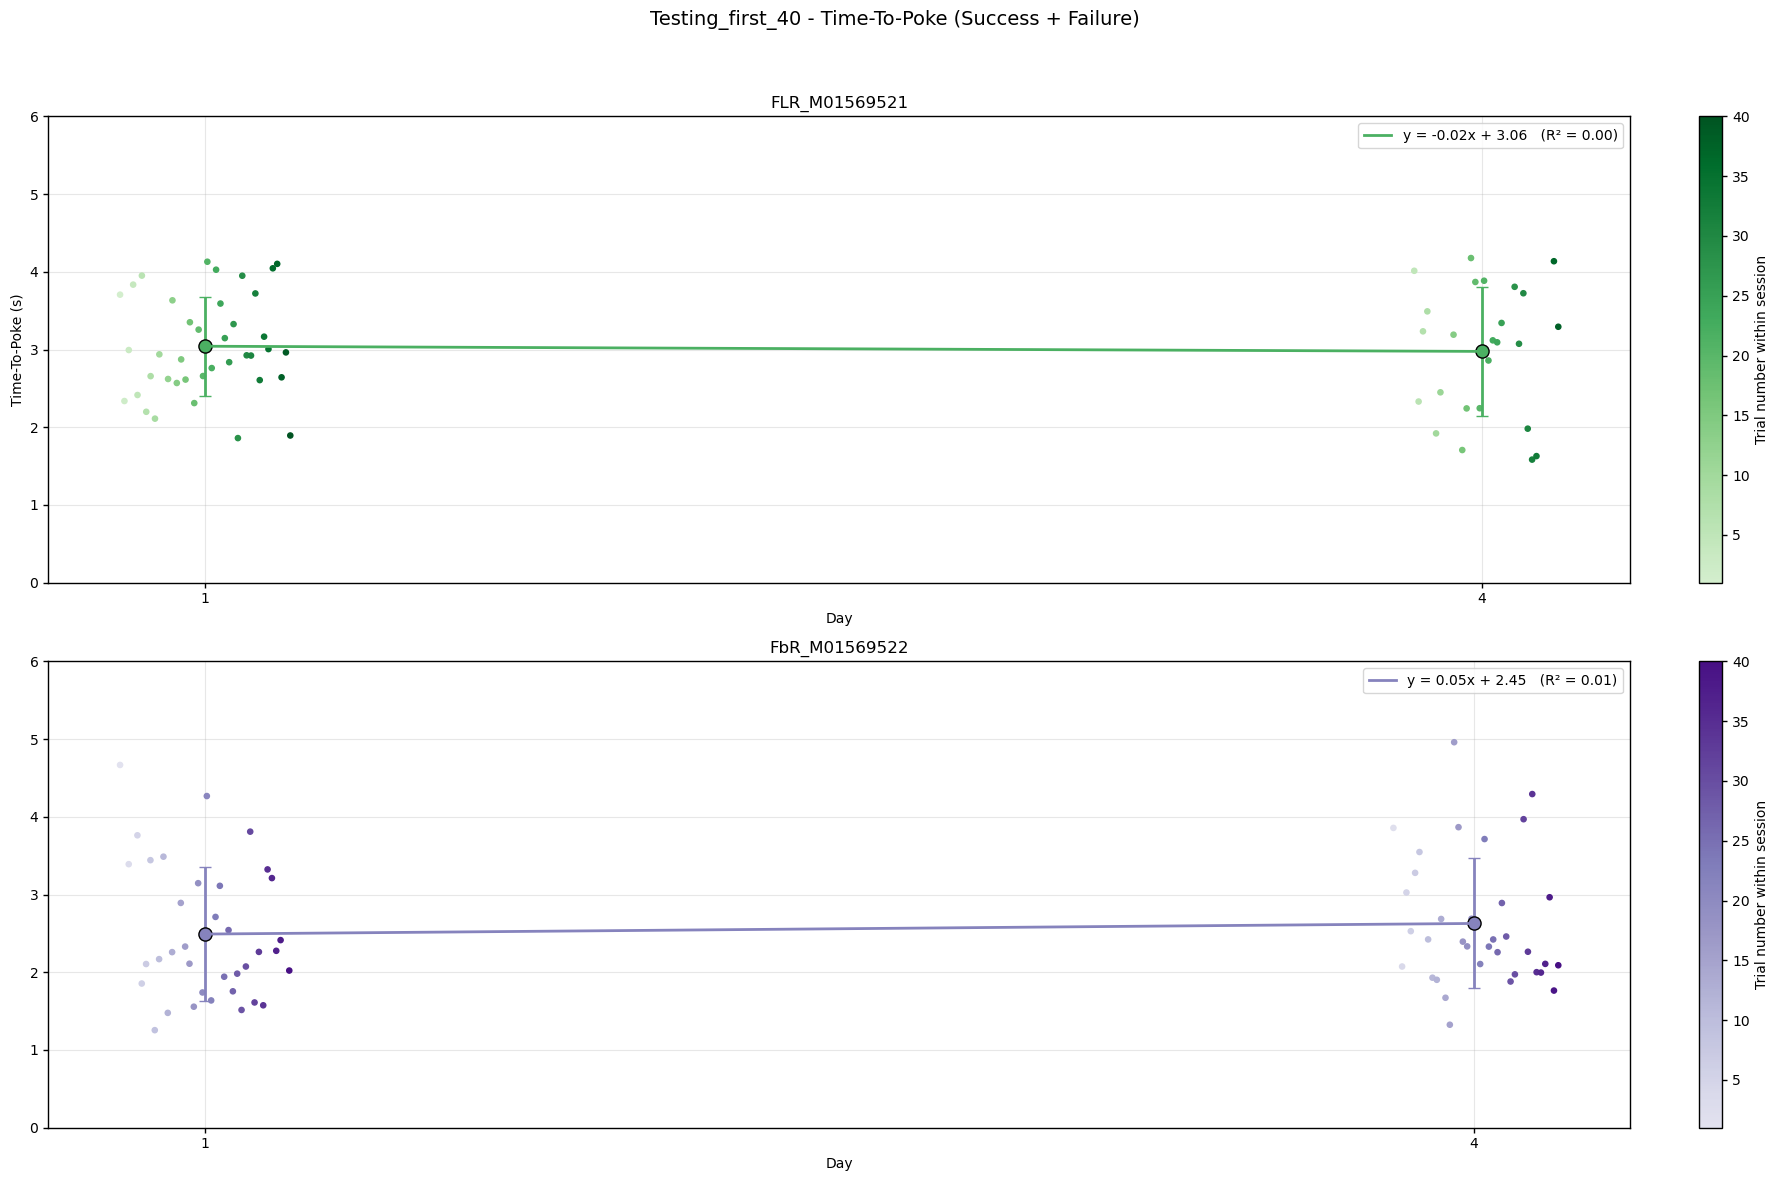

=== Summary statistics: Testing_first_40 (trial_filter='all') ===


/tmp/ipykernel_2892238/3405151723.py:59: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_all_trials["rank_norm"] = df_all_trials.groupby("session", group_keys=False).apply(_rank_norm)


n_trials  n_success  n_fail  n_miss  n_angle   mean  \
day_num mouseID                                                              
1       FLR_M01569521        40         39       0       1       39  0.000   
        FbR_M01569522        40         31       5       4       36 -1.667   
4       FLR_M01569521        40         25       0      15       25  0.000   
        FbR_M01569522        40         34       1       5       35 -0.571   

                           sd  median   min   max  n_pos  n_neg  
day_num mouseID                                                  
1       FLR_M01569521   0.000     0.0   0.0   0.0      0      0  
        FbR_M01569522  12.071     0.0 -60.0  20.0      2      3  
4       FLR_M01569521   0.000     0.0   0.0   0.0      0      0  
        FbR_M01569522   3.381     0.0 -20.0   0.0      0      1

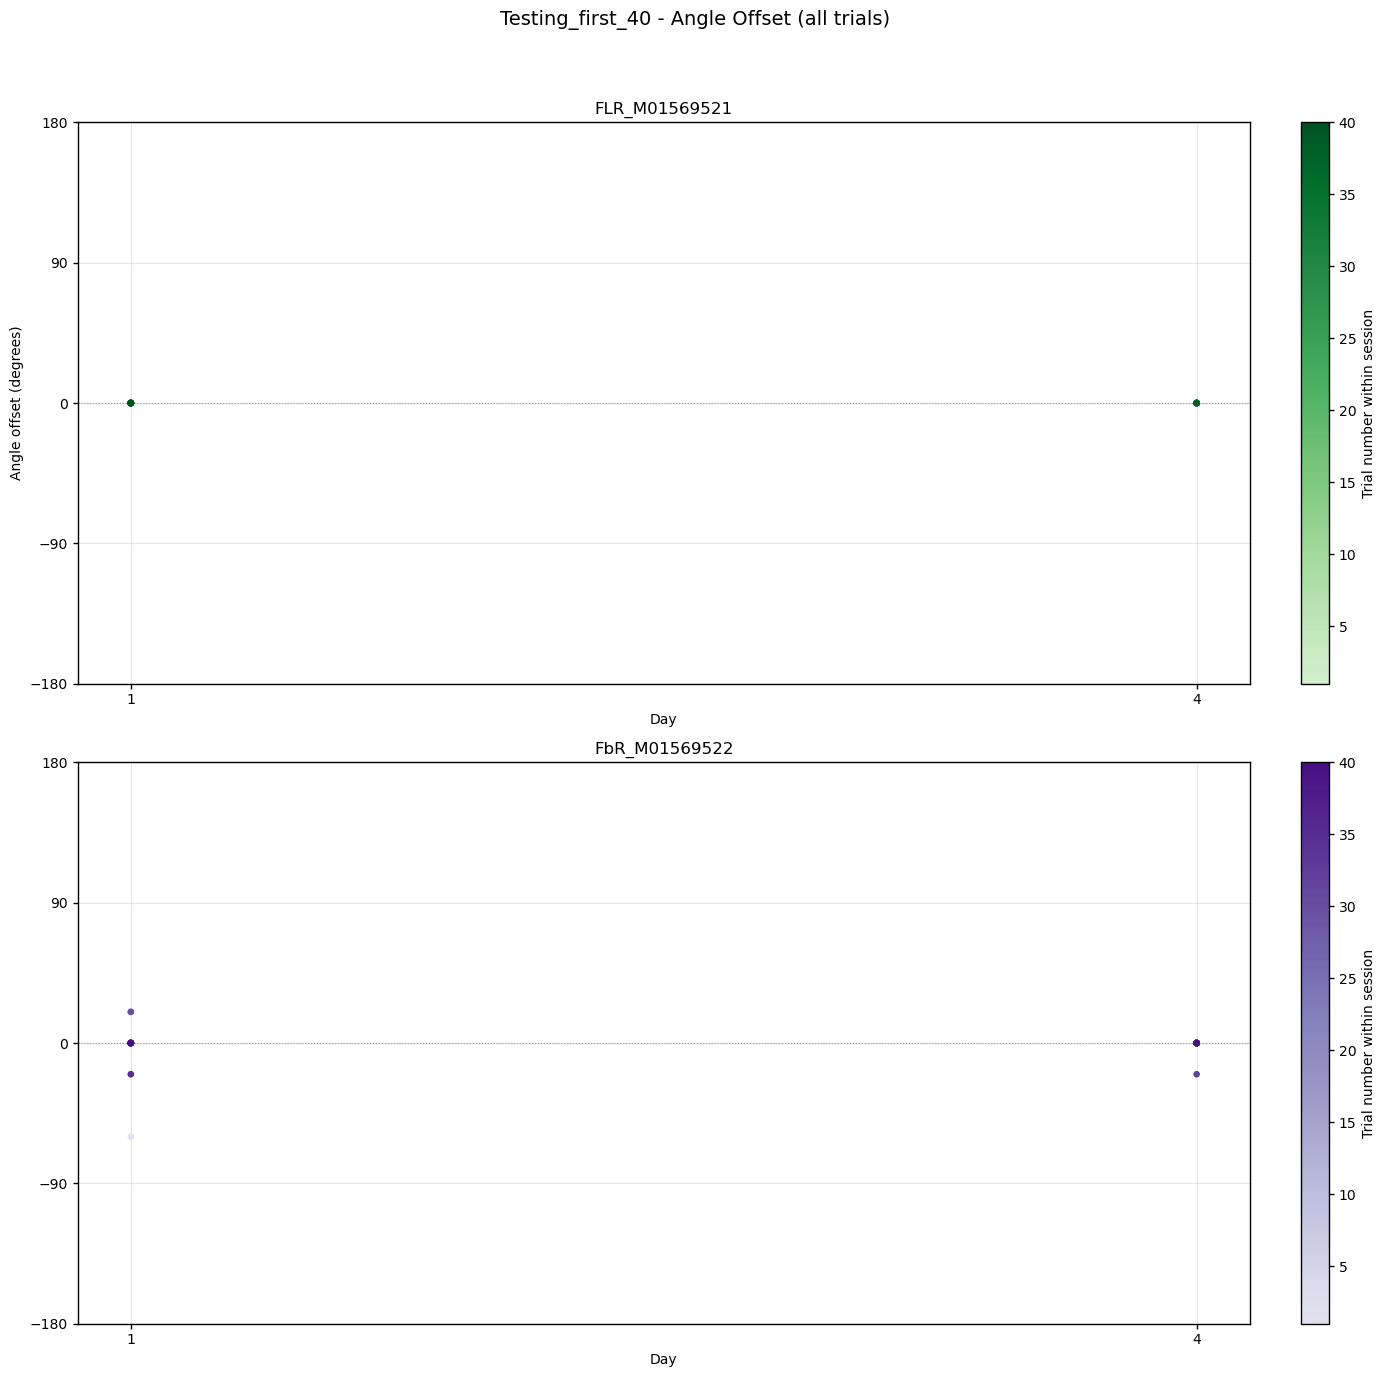

=== Summary statistics: Testing_first_40 (trial_filter='all') ===


/tmp/ipykernel_2892238/338652183.py:59: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_all_trials["rank_norm"] = df_all_trials.groupby("session", group_keys=False).apply(_rank_norm)
/tmp/ipykernel_2892238/338652183.py:169: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="best")


n_trials  n_success  n_fail  n_miss  n_angle   mean  \
day_num mouseID                                                              
1       FLR_M01569521        40         39       0       1       39  0.000   
        FbR_M01569522        40         31       5       4       36  3.889   
4       FLR_M01569521        40         25       0      15       25  0.000   
        FbR_M01569522        40         34       1       5       35  0.571   

                           sd  median  min   max  
day_num mouseID                                   
1       FLR_M01569521   0.000     0.0  0.0   0.0  
        FbR_M01569522  11.533     0.0  0.0  60.0  
4       FLR_M01569521   0.000     0.0  0.0   0.0  
        FbR_M01569522   3.381     0.0  0.0  20.0

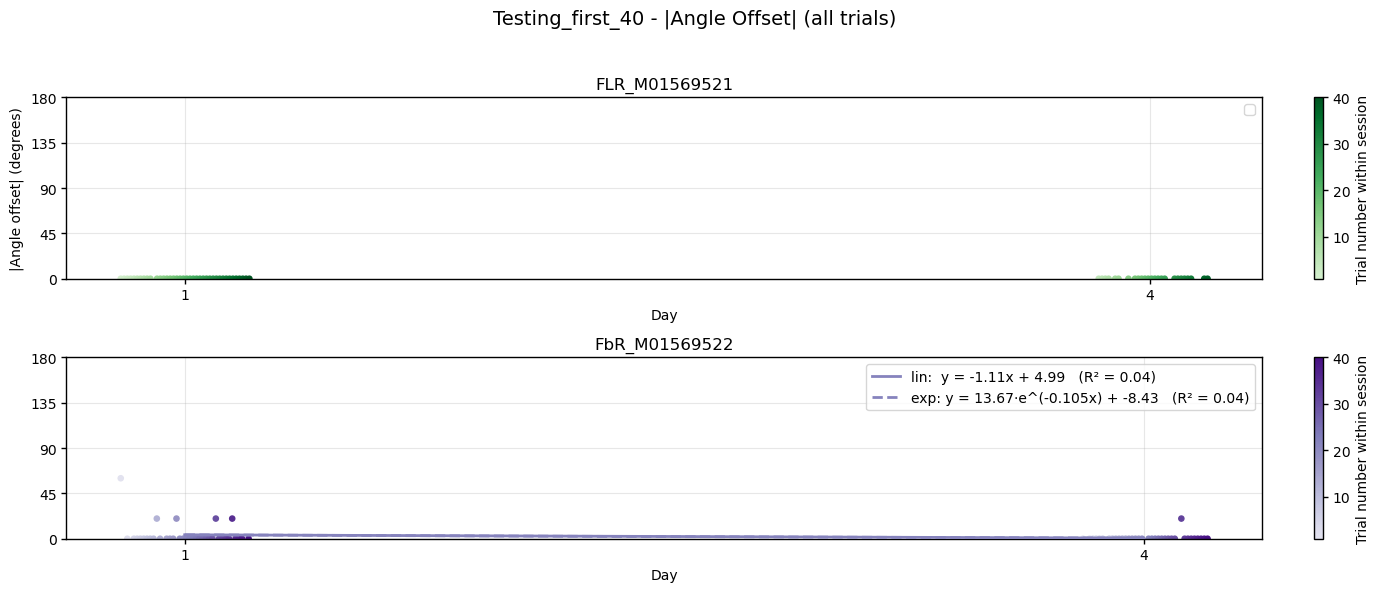

=== Per-(mouse, day) summary: Testing_first_40 ===


n_trials  n_success  n_fail  n_miss  ttp_n  ttp_mean  \
day_num mouseID                                                               
1       FLR_M01569521        40         39       0       1     40     3.092   
        FbR_M01569522        40         31       5       4     40     2.744   
4       FLR_M01569521        40         25       0      15     40     3.741   
        FbR_M01569522        40         34       1       5     40     2.926   

                       ttp_sd  ttp_median  ttp_min  ttp_max  absangle_n  \
day_num mouseID                                                           
1       FLR_M01569521   0.703       2.950    1.861    5.013          39   
        FbR_M01569522   1.120       2.303    1.255    5.018          36   
4       FLR_M01569521   1.194       3.838    1.584    5.033          25   
        FbR_M01569522   1.116       2.441    1.325    5.017          35   

                       absangle_mean  absangle_sd  absangle_median  \
day_num mouseID                                                      
1       FLR_M01569521          0.000        0.000              0.0   
        FbR_M01569522          3.889       11.533              0.0   
4       FLR_M01569521          0.000        0.000              0.0   
        FbR_M01569522          0.571        3.381              0.0   

                       absangle_min  absangle_max zone_sizes  
day_num mouseID                                               
1       FLR_M01569521           0.0           0.0        150  
        FbR_M01569522           0.0          60.0        150  
4       FLR_M01569521           0.0           0.0        150  
        FbR_M01569522           0.0          20.0        150

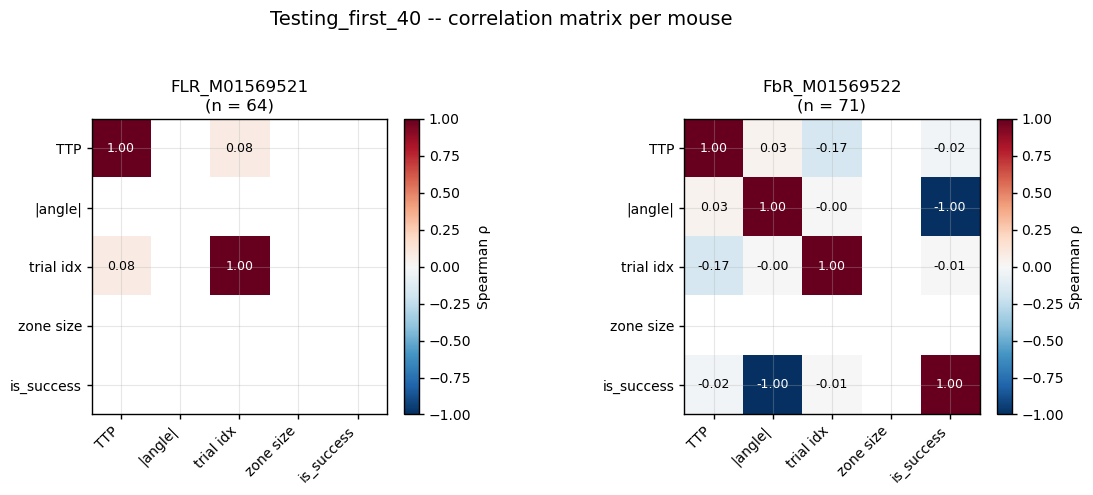


========== Testing_first_25 ==========


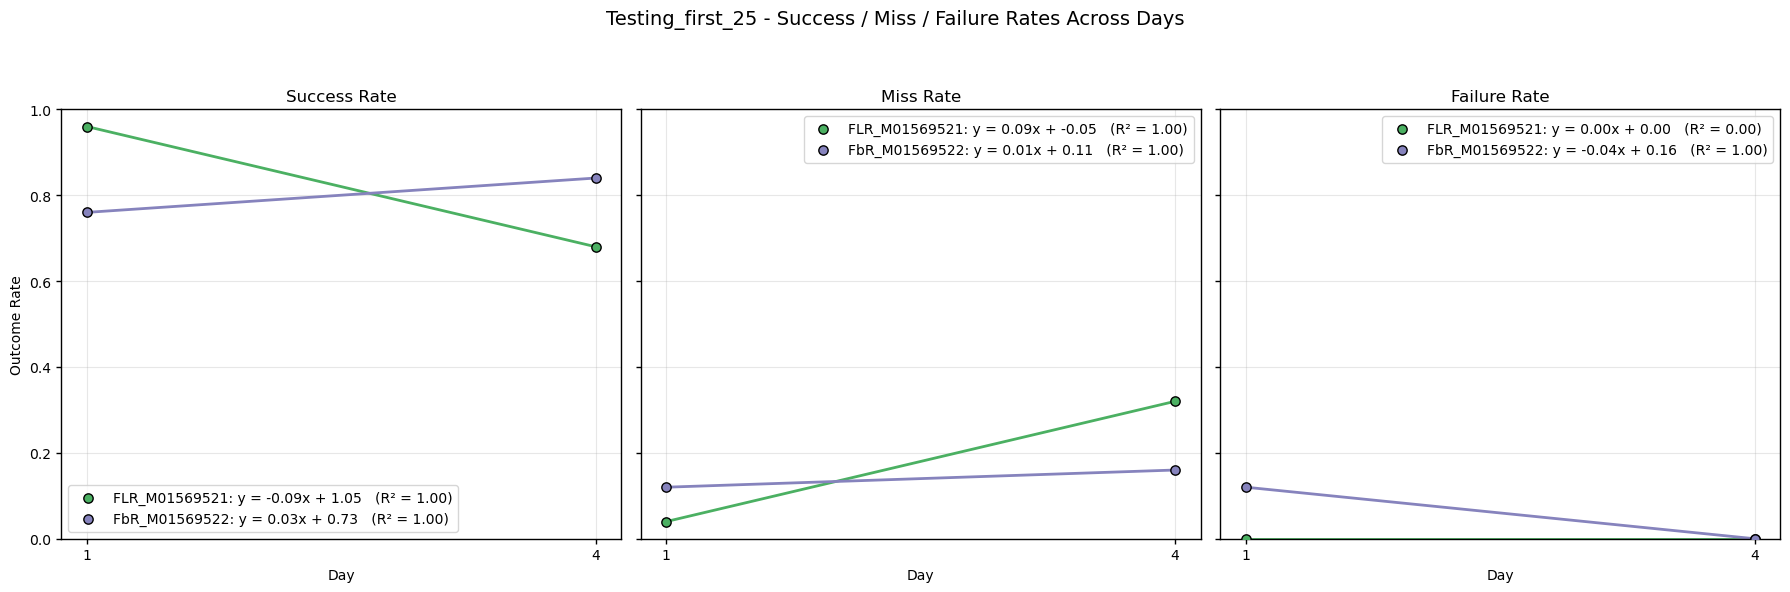

=== Summary statistics: Testing_first_25 (trial_filter='no_miss') ===


/tmp/ipykernel_2892238/969829571.py:91: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_all_trials["rank_norm"] = df_all_trials.groupby("session", group_keys=False).apply(_rank_norm)


n_trials  n_success  n_fail  n_miss   mean     sd  \
day_num mouseID                                                            
1       FLR_M01569521        25         24       0       1  3.029  0.620   
        FbR_M01569522        25         19       3       3  2.605  0.947   
4       FLR_M01569521        25         17       0       8  3.010  0.757   
        FbR_M01569522        25         21       0       4  2.717  0.879   

                       median    min    max  
day_num mouseID                              
1       FLR_M01569521   2.905  2.111  4.130  
        FbR_M01569522   2.295  1.255  4.667  
4       FLR_M01569521   3.118  1.707  4.177  
        FbR_M01569522   2.423  1.325  4.959

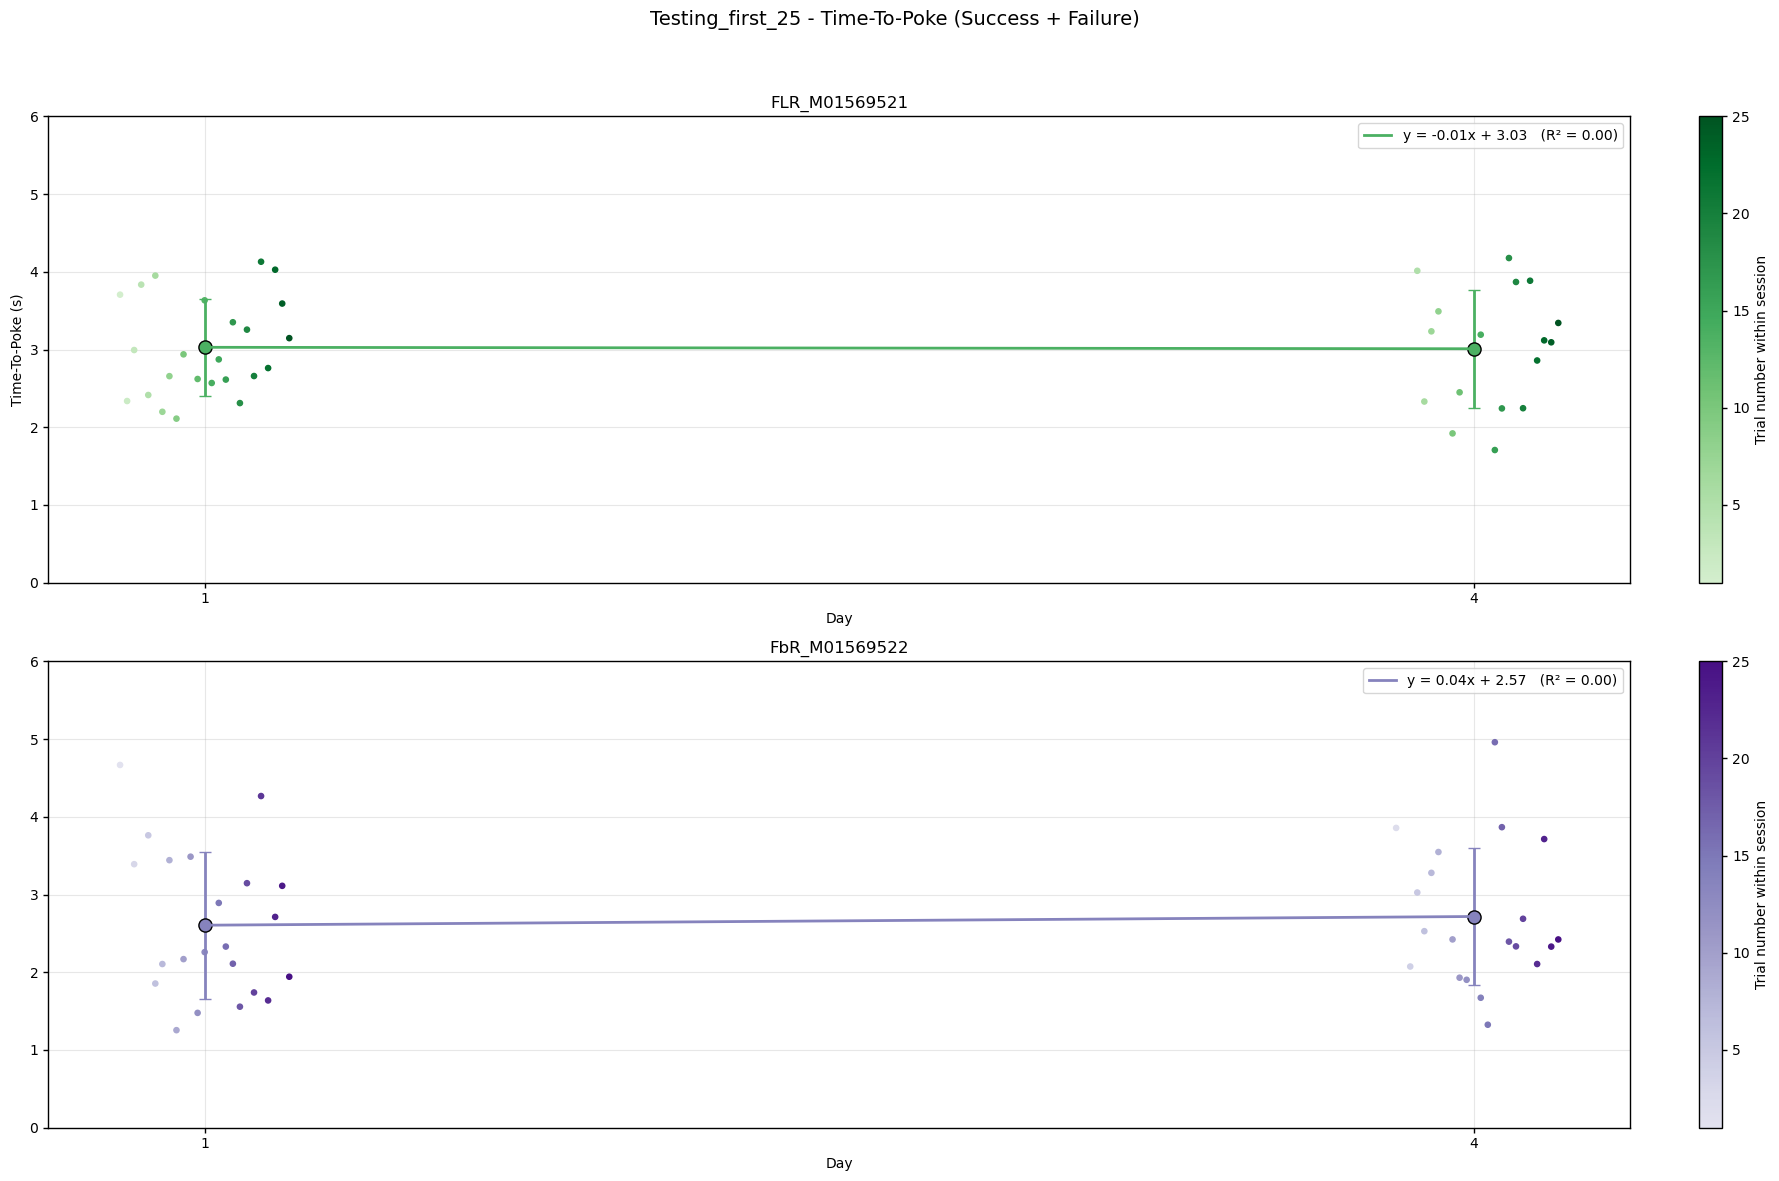

=== Summary statistics: Testing_first_25 (trial_filter='all') ===


/tmp/ipykernel_2892238/3405151723.py:59: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_all_trials["rank_norm"] = df_all_trials.groupby("session", group_keys=False).apply(_rank_norm)


n_trials  n_success  n_fail  n_miss  n_angle   mean  \
day_num mouseID                                                              
1       FLR_M01569521        25         24       0       1       24  0.000   
        FbR_M01569522        25         19       3       3       22 -2.727   
4       FLR_M01569521        25         17       0       8       17  0.000   
        FbR_M01569522        25         21       0       4       21  0.000   

                           sd  median   min   max  n_pos  n_neg  
day_num mouseID                                                  
1       FLR_M01569521   0.000     0.0   0.0   0.0      0      0  
        FbR_M01569522  14.203     0.0 -60.0  20.0      1      2  
4       FLR_M01569521   0.000     0.0   0.0   0.0      0      0  
        FbR_M01569522   0.000     0.0   0.0   0.0      0      0

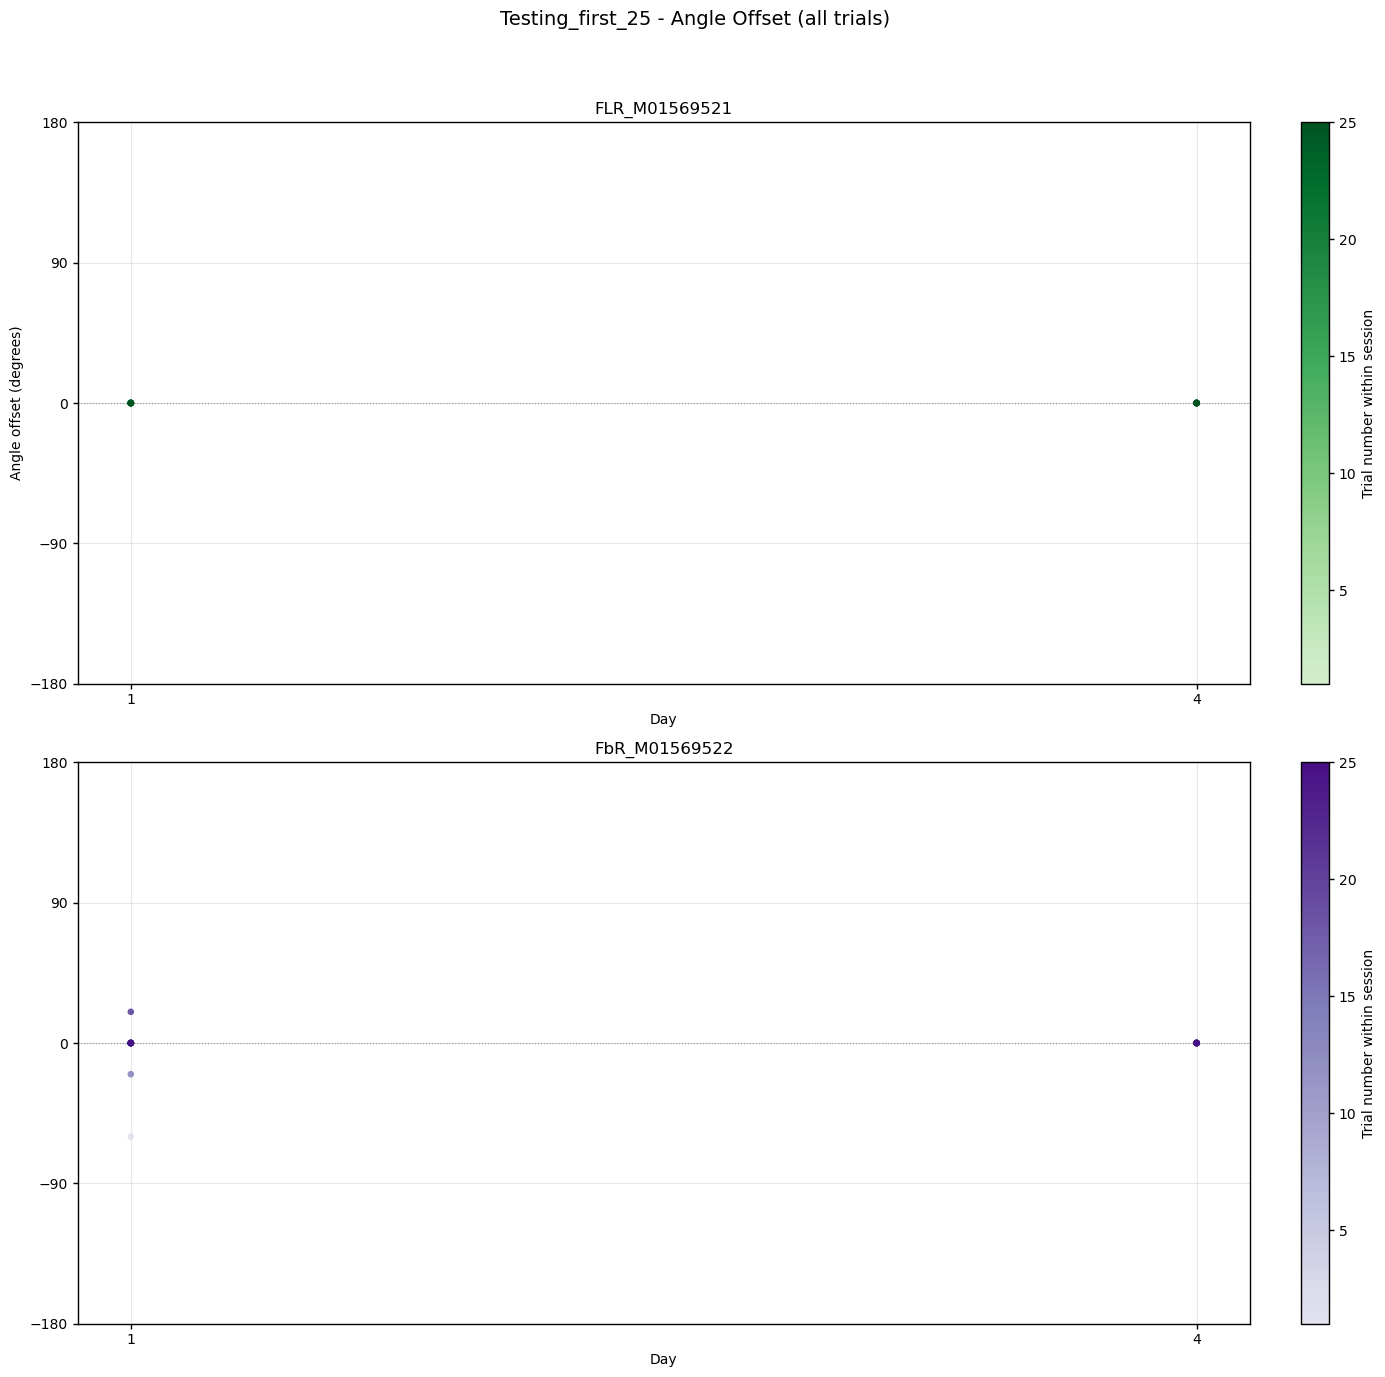

=== Summary statistics: Testing_first_25 (trial_filter='all') ===


/tmp/ipykernel_2892238/338652183.py:59: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_all_trials["rank_norm"] = df_all_trials.groupby("session", group_keys=False).apply(_rank_norm)
/tmp/ipykernel_2892238/338652183.py:169: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="best")


n_trials  n_success  n_fail  n_miss  n_angle   mean  \
day_num mouseID                                                              
1       FLR_M01569521        25         24       0       1       24  0.000   
        FbR_M01569522        25         19       3       3       22  4.545   
4       FLR_M01569521        25         17       0       8       17  0.000   
        FbR_M01569522        25         21       0       4       21  0.000   

                           sd  median  min   max  
day_num mouseID                                   
1       FLR_M01569521   0.000     0.0  0.0   0.0  
        FbR_M01569522  13.707     0.0  0.0  60.0  
4       FLR_M01569521   0.000     0.0  0.0   0.0  
        FbR_M01569522   0.000     0.0  0.0   0.0

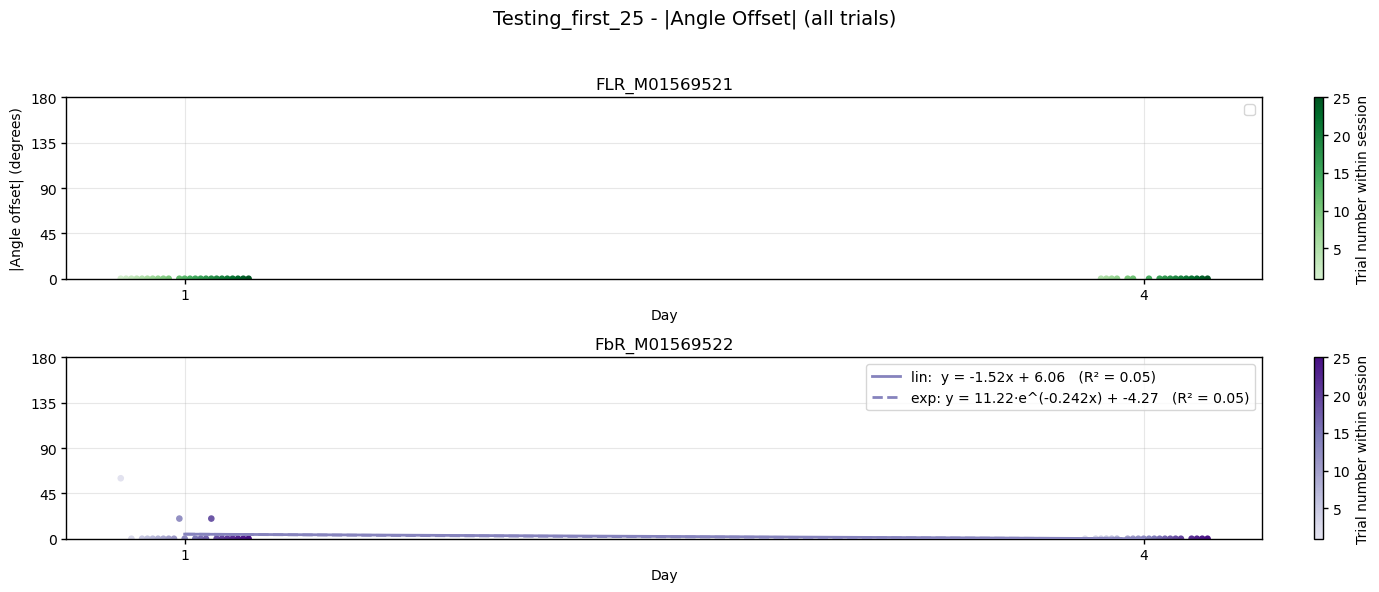

=== Per-(mouse, day) summary: Testing_first_25 ===


n_trials  n_success  n_fail  n_miss  ttp_n  ttp_mean  \
day_num mouseID                                                               
1       FLR_M01569521        25         24       0       1     25     3.108   
        FbR_M01569522        25         19       3       3     25     2.895   
4       FLR_M01569521        25         17       0       8     25     3.651   
        FbR_M01569522        25         21       0       4     25     3.084   

                       ttp_sd  ttp_median  ttp_min  ttp_max  absangle_n  \
day_num mouseID                                                           
1       FLR_M01569521   0.725       2.938    2.111    5.013          24   
        FbR_M01569522   1.194       2.712    1.255    5.018          22   
4       FLR_M01569521   1.137       3.491    1.707    5.017          17   
        FbR_M01569522   1.175       2.686    1.325    5.017          21   

                       absangle_mean  absangle_sd  absangle_median  \
day_num mouseID                                                      
1       FLR_M01569521          0.000        0.000              0.0   
        FbR_M01569522          4.545       13.707              0.0   
4       FLR_M01569521          0.000        0.000              0.0   
        FbR_M01569522          0.000        0.000              0.0   

                       absangle_min  absangle_max zone_sizes  
day_num mouseID                                               
1       FLR_M01569521           0.0           0.0        150  
        FbR_M01569522           0.0          60.0        150  
4       FLR_M01569521           0.0           0.0        150  
        FbR_M01569522           0.0           0.0        150

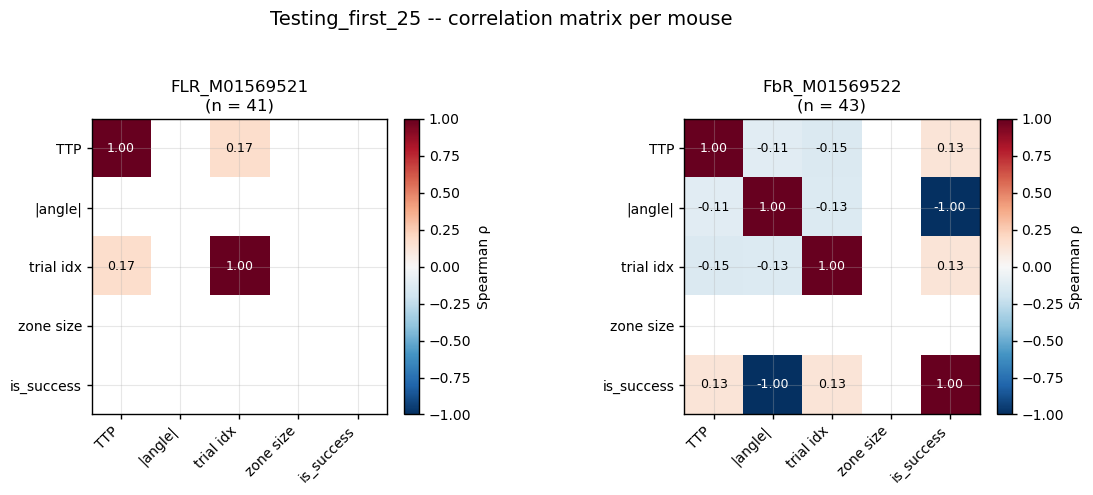


Finished generating figures for 8 datasets.


In [16]:
#==== Run the figure suite across datasets in a fixed, readable order ==========================

# This list is the single source of truth for iteration order.
# To add/remove/reorder datasets, edit this list rather than changing the loop body.
ordered_datasets = [
    ("Training_all_trials", training_dfs["all_trials"]),
    ("Testing_all_trials", testing_last_dfs["all_trials"]),

    ("Training_last_40", training_dfs["last_40"]),
    ("Testing_last_40", testing_last_dfs["last_40"]),

    ("Training_last_25", training_dfs["last_25"]),
    ("Testing_last_25", testing_last_dfs["last_25"]),

    # These only exist for testing datasets because they represent the first N
    # trials from each testing day, rather than the last N trials.
    ("Testing_first_40", testing_first_dfs["first_40"]),
    ("Testing_first_25", testing_first_dfs["first_25"]),
]

# Each returned summary table is stored here under the same name used in the loop.
# Example after running: summary_tables["Training_last_40"]
summary_tables = {}

for dataset_name, dset in ordered_datasets:
    summary_tables[dataset_name] = generate_figures_for_dataset(
        dataset_df=dset,
        dataset_name=dataset_name,
        save_path=FIGURE_DIR,
        mouse_IDs=mouse_IDs,
        mouse_colours=mouse_colours,
        mouse_cmaps=mouse_cmaps,
        days_to_plot=None,                         # None means use every day in that dataframe
        save_figures=SAVE_FIGURES,
        append_date=APPEND_DATE,
        display_figure=DISPLAY_FIGURES,            # set DISPLAY_FIGURES=False before this cell for a quieter bulk run
        fig_format=FIG_FORMAT,
        dpi=DPI,
        display_summary_statistics=True,           # set False to suppress the inline stats tables
        ttp_trial_filter="no_miss",
        angle_trial_filter="all",
        abs_angle_trial_filter="all",
        abs_angle_fit_methods=("linear", "exponential"),
    )

print(f"\nFinished generating figures for {len(summary_tables)} datasets.")
